In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Hyperparameter Configuration

In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# Random Seed
SEED = 56
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Diffusion hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE        = 16
LEARNING_RATE     = 1e-4      # label-conditional model converges faster than image-guided
EPOCHS            = 200
IMAGE_SIZE        = 64
NOISE_STEPS       = 1000
BETA_START        = 0.0015
BETA_END          = 0.0195
ACCUMULATION_STEPS = 32

# ── Class-conditional / CFG settings ──────────────────────────────────────────
CFG_DROPOUT    = 0.20
GUIDANCE_SCALE = 3.0
EMB_DIM        = 256

# 'none' class sample cap for diffusion training.
NONE_SAMPLE_CAP = 5000


# Dataset path
WM811K_PATH = "/content/drive/MyDrive/03_Wafer_Project/data/LSWMD_new.pkl"

# Checkpoint directory
CKPT_DIR = "/content/drive/MyDrive/03_Wafer_Project/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

Using device: cuda


## 2. Customized Dataset

In [ ]:
class WaferDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        label = self.labels[idx]

        # PIL Image Transform (Gray Scale)
        image = Image.fromarray((image.squeeze() * 127).astype(np.uint8))

        if self.transform:
            image = self.transform(image)

        return image, label

## 3. Loading Data & Preprocessing

In [ ]:
# Diffusion model handles 8 failure types + 'none' (9 classes total).
FAILURE_CLASSES = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
                   'Loc', 'Near-full', 'Random', 'Scratch', 'none']
N_CLASSES       = len(FAILURE_CLASSES)            # 9
NULL_CLASS_IDX  = N_CLASSES                       # index 9, reserved for CFG null conditioning
FAIL_LABEL2IDX  = {ft: i for i, ft in enumerate(FAILURE_CLASSES)}
FAIL_IDX2LABEL  = {i: ft for ft, i in FAIL_LABEL2IDX.items()}

# All types (same as FAILURE_CLASSES now) used for downstream classification
ALL_TYPES     = FAILURE_CLASSES
ALL_LABEL2IDX = FAIL_LABEL2IDX

def _parse_failure_type(x):
    """WM-811K stores failureType as a string OR as a (nested) list depending on
    the dataset version.  Normalise everything to a plain string.

    Examples:
        'Edge-Ring'          → 'Edge-Ring'
        ['Edge-Ring']        → 'Edge-Ring'
        [['Edge-Ring']]      → 'Edge-Ring'
        []  /  [[]]  /  NaN  → ''   (will be filtered out)
    """
    if isinstance(x, str):
        return x
    # unwrap arbitrarily nested lists
    while isinstance(x, (list, np.ndarray)):
        if len(x) == 0:
            return ''
        x = x[0]
    return str(x) if x is not None else ''


def load_data():
    df = pd.read_pickle(WM811K_PATH)
    df = df.rename(columns={"trianTestLabel": "trainTestLabel"})

    # Normalise failureType to plain strings
    df['failureType'] = df['failureType'].apply(_parse_failure_type)

    # Drop rows with no label
    df = df[df['failureType'].str.len() > 0]
    df = df.reset_index(drop=True)
    return df

def resize_map(image, target_size=(64, 64)):
    return cv2.resize(np.array(image).astype('float32'), target_size, interpolation=cv2.INTER_NEAREST_EXACT)

def preprocess_data(df):
    data, labels = [], []
    for _, row in df.iterrows():
        wafer_map = row['waferMap'].copy().astype(float)

        # Re-map
        tmp = wafer_map.copy()
        wafer_map[tmp == 0] = 2
        wafer_map[tmp == 2] = 0
        wafer_map[tmp == 1] = 1

        wafer_map = resize_map(wafer_map, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        wafer_map = wafer_map[np.newaxis, :]   # (1, H, W)

        data.append(wafer_map)
        labels.append(row['failureType'])

    return np.array(data, dtype=np.float32), np.array(labels)


def stratified_split(data, labels, train_ratio=0.6, val_ratio=0.2, seed=SEED):
    """
    Stratified split into train / val / test  (60 / 20 / 20).
    Returns index arrays so that WaferDataset objects can be built later.
    """
    indices = np.arange(len(labels))
    # First split: train  vs  (val + test)
    train_idx, temp_idx, _, temp_labels = train_test_split(
        indices, labels,
        test_size=(1 - train_ratio),
        stratify=labels,
        random_state=seed
    )
    # Second split: val vs test  (each half of the remaining)
    val_ratio_adjusted = val_ratio / (1 - train_ratio)   # 0.2/0.4 = 0.5
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.5,
        stratify=temp_labels,
        random_state=seed
    )
    return train_idx, val_idx, test_idx


## 4. Dataset Construction & Stratified Split

In [ ]:
# ── Downstream classification transform (no augmentation) ────────────────────
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor(),
])

# ── Diffusion training transform: flip + 90°-step rotation ───────────────────
class RandomRotate90:
    """Rotate PIL image by exactly 0 / 90 / 180 / 270 degrees.

    Right-angle multiples keep the wafer circle perfectly intact
    (no boundary deformation). fill=254 == not-wafer in uint8 space.
    """
    def __call__(self, img):
        k = random.randint(0, 3)
        if k == 0:
            return img
        return transforms.functional.rotate(
            img, k * 90,
            interpolation=transforms.InterpolationMode.NEAREST,
            fill=254,
        )

diff_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    RandomRotate90(),
    transforms.ToTensor(),
])

# ── Load & preprocess ─────────────────────────────────────────────────────────
print("Loading dataset …")
df = load_data()
print(f"Total rows after filtering: {len(df)}")
print(df['failureType'].value_counts())

data, labels = preprocess_data(df)
print(f"\npreprocess done  →  data shape: {data.shape}, labels: {labels.shape}")

# ── Stratified 60 / 20 / 20 split ─────────────────────────────────────────────
train_idx, val_idx, test_idx = stratified_split(data, labels)

train_data,  train_labels  = data[train_idx],  labels[train_idx]
val_data,    val_labels    = data[val_idx],    labels[val_idx]
test_data,   test_labels   = data[test_idx],   labels[test_idx]

print(f"\nSplit sizes  →  train: {len(train_data)}, val: {len(val_data)}, test: {len(test_data)}")
print("\nTrain class distribution:")
unique, counts = np.unique(train_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u:12s}: {c}")

# ── Per-sample fail-die ratio (for 'none' filtering in diffusion) ─────────────
train_fail_counts  = (train_data == 2).sum(axis=(1, 2, 3))
train_wafer_counts = (train_data > 0).sum(axis=(1, 2, 3))
train_fail_ratio   = train_fail_counts / np.maximum(train_wafer_counts, 1)

# ── PyTorch Dataset / DataLoader ──────────────────────────────────────────────
train_dataset = WaferDataset(train_data, train_labels, transform=transform)
val_dataset   = WaferDataset(val_data,   val_labels,   transform=transform)
test_dataset  = WaferDataset(test_data,  test_labels,  transform=transform)

# ── Diffusion training set: all failures + IQR-filtered 'none' ────────────────
# For the 'none' class, only samples within the 25–75 percentile range (IQR)
# of the fail-die ratio are used, removing extreme outliers before capping at NONE_SAMPLE_CAP.
train_fail_mask = train_labels != 'none'
train_none_mask = train_labels == 'none'

diff_fail_data   = train_data[train_fail_mask]
diff_fail_labels = train_labels[train_fail_mask]

none_indices      = np.where(train_none_mask)[0]
none_fail_ratios  = train_fail_ratio[train_none_mask]
q25, q75          = np.percentile(none_fail_ratios, [25, 75])
iqr_mask          = (none_fail_ratios >= q25) & (none_fail_ratios <= q75)
filtered_none_idx = none_indices[iqr_mask]

rng      = np.random.default_rng(SEED)
sel_size = min(NONE_SAMPLE_CAP, len(filtered_none_idx))
if sel_size > 0:
    none_sel = rng.choice(filtered_none_idx, size=sel_size, replace=False)
else:
    none_sel = np.array([], dtype=int)

diff_none_data   = train_data[none_sel]
diff_none_labels = train_labels[none_sel]

diff_train_data   = np.concatenate([diff_fail_data, diff_none_data],   axis=0)
diff_train_labels = np.concatenate([diff_fail_labels, diff_none_labels], axis=0)
print(f"\nDiffusion training set: {len(diff_train_data)} samples "
      f"({len(diff_fail_data)} failures + {len(diff_none_data)} none; "
      f"none IQR [{q25:.4f}, {q75:.4f}])")

diff_train_dataset = WaferDataset(diff_train_data, diff_train_labels, transform=diff_transform)
diff_train_loader  = DataLoader(diff_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=2, pin_memory=True, drop_last=True)

# Full train loader (for downstream classification later)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

Loading dataset …
Total rows after filtering: 172950
failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

preprocess done  →  data shape: (172950, 1, 64, 64), labels: (172950,)

Split sizes  →  train: 103770, val: 34590, test: 34590

Train class distribution:
  Center      : 2576
  Donut       : 333
  Edge-Loc    : 3113
  Edge-Ring   : 5808
  Loc         : 2156
  Near-full   : 89
  Random      : 520
  Scratch     : 716
  none        : 88459

Diffusion training set: 20311 samples (15311 failures + 5000 none; none IQR [0.2340, 0.2630])


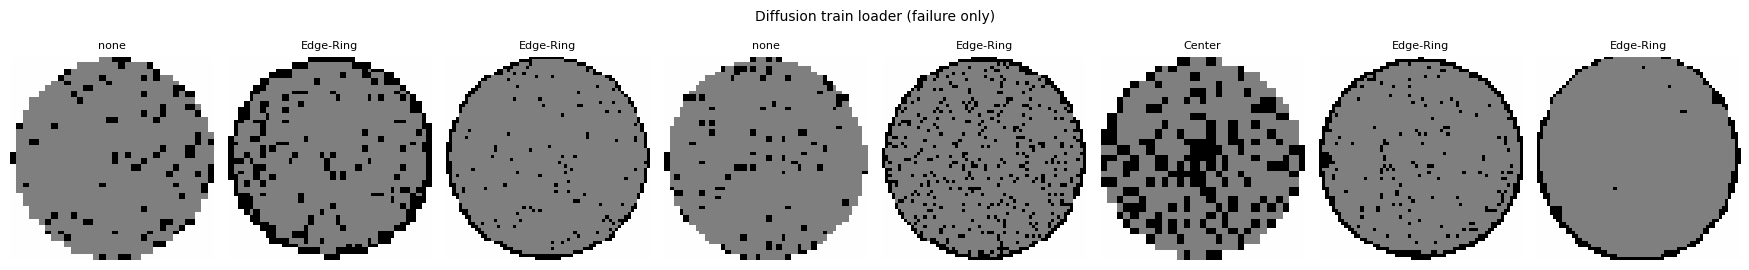

Pixel value range: min=0.0000, max=0.9961
Approx unique levels: tensor([0.0000, 0.5000, 1.0000])


In [ ]:
# ── Train loader sample visualisation ────────────────────────────────────────
def visualize_loader_samples(loader, n=8, title="Train loader samples"):
    images, labels = next(iter(loader))   # (B, 1, H, W), tensor [0,1]

    n = min(n, len(images))
    fig, axes = plt.subplots(1, n, figsize=(n * 2.2, 2.8))

    for i in range(n):
        img = images[i, 0].numpy()        # (H, W), float [0,1]
        ax  = axes[i]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(labels[i], fontsize=8)
        ax.axis('off')

        # Display representative pixel values
        unique_vals = np.unique(np.round(img, 2))
        ax.set_xlabel(str(unique_vals[:4]), fontsize=6)

    plt.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()
    print(f"Pixel value range: min={images.min():.4f}, max={images.max():.4f}")
    print(f"Approx unique levels: {torch.unique(images.round(decimals=2))}")

visualize_loader_samples(diff_train_loader, n=8, title="Diffusion train loader (failure only)")

## 5. Noise Scheduling

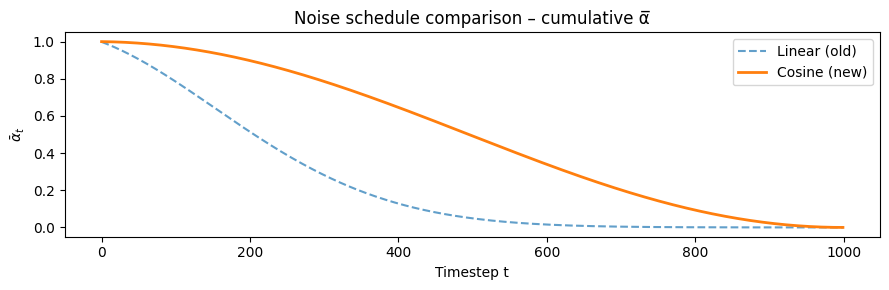

In [ ]:
# Cosine noise schedule vs linear — visualisation.
# Cosine schedule degrades more slowly at low t, preserving fine detail
T       = NOISE_STEPS
_steps  = torch.arange(T + 1, dtype=torch.float32)
_f      = torch.cos(((_steps / T + 0.008) / 1.008) * (math.pi / 2)) ** 2
_alpha_hat_cos = (_f / _f[0]).clamp(max=1.0)[1:]   # shape (T,)

_beta_lin      = torch.linspace(BETA_START, BETA_END, T)
_alpha_hat_lin = torch.cumprod(1 - _beta_lin, dim=0)

plt.figure(figsize=(9, 3))
plt.plot(_alpha_hat_lin.numpy(), label="Linear (old)", linestyle="--", alpha=0.7)
plt.plot(_alpha_hat_cos.numpy(), label="Cosine (new)", linewidth=2)
plt.xlabel("Timestep t")
plt.ylabel(r"$\bar{\alpha}_t$")
plt.title("Noise schedule comparison – cumulative α̅")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Model Architecture
### 6-1. ResBlock (AdaGN scale-shift conditioning) + Down / Up

In [ ]:
def get_groups(ch):
    """Largest valid num_groups for GroupNorm that divides ch."""
    for g in [32, 16, 8, 4, 2, 1]:
        if ch % g == 0:
            return g
    return 1


class ResBlock(nn.Module):
    """Residual block with Adaptive Group Norm (AdaGN) conditioning."""
    def __init__(self, in_ch, out_ch, emb_dim, dropout=0.1):
        super().__init__()
        self.norm1    = nn.GroupNorm(get_groups(in_ch), in_ch)
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        # scale-shift projection: emb → (scale, shift) for out_ch channels
        self.emb_proj = nn.Sequential(nn.SiLU(), nn.Linear(emb_dim, out_ch * 2))
        self.norm2    = nn.GroupNorm(get_groups(out_ch), out_ch)
        self.drop     = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip     = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        # Zero-init so the block acts as identity at the start of training
        nn.init.zeros_(self.emb_proj[-1].weight)
        nn.init.zeros_(self.emb_proj[-1].bias)

    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        # AdaGN: scale-shift from condition embedding
        scale, shift = self.emb_proj(emb).chunk(2, dim=-1)
        h = self.norm2(h) * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = self.drop(self.conv2(F.silu(h)))
        return h + self.skip(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim=EMB_DIM):
        super().__init__()
        self.pool   = nn.MaxPool2d(2)
        self.block1 = ResBlock(in_ch, in_ch, emb_dim)
        self.block2 = ResBlock(in_ch, out_ch, emb_dim)

    def forward(self, x, emb):
        return self.block2(self.block1(self.pool(x), emb), emb)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim=EMB_DIM):
        super().__init__()
        self.up     = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        # skip has same channel count as in_ch (symmetric encoder/decoder)
        self.block1 = ResBlock(in_ch * 2, in_ch, emb_dim)
        self.block2 = ResBlock(in_ch, out_ch, emb_dim)

    def forward(self, x, skip, emb):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.block2(self.block1(x, emb), emb)

### 6-2. SelfAttention + CrossAttentionClass

In [ ]:
class SelfAttention(nn.Module):
    """Spatial self-attention with proper GroupNorm pre-norm and zero-init output."""
    def __init__(self, ch):
        super().__init__()
        self.norm  = nn.GroupNorm(get_groups(ch), ch)
        self.query = nn.Conv2d(ch, ch, 1)
        self.key   = nn.Conv2d(ch, ch, 1)
        self.value = nn.Conv2d(ch, ch, 1)
        self.proj  = nn.Conv2d(ch, ch, 1)
        nn.init.zeros_(self.proj.weight)
        nn.init.zeros_(self.proj.bias)

    def forward(self, x):
        B, C, H, W = x.shape
        h    = self.norm(x)
        q    = self.query(h).view(B, C, -1)
        k    = self.key(h).view(B, C, -1)
        v    = self.value(h).view(B, C, -1)
        attn = F.softmax(torch.bmm(q.transpose(1, 2), k) / C**0.5, dim=-1)
        out  = torch.bmm(attn, v.transpose(1, 2)).transpose(1, 2).view(B, C, H, W)
        return x + self.proj(out)


class CrossAttentionClass(nn.Module):
    """Cross-attention where Q = spatial feature map, K/V = class context tokens.

    The class embedding is expanded to CTX_TOKENS context tokens to give the
    attention more expressivity than a single token.
    Zero-initialising out_proj makes the block start as identity.
    """
    def __init__(self, ch, ctx_dim):
        super().__init__()
        self.norm     = nn.GroupNorm(get_groups(ch), ch)
        self.q_proj   = nn.Linear(ch, ch)
        self.k_proj   = nn.Linear(ctx_dim, ch)
        self.v_proj   = nn.Linear(ctx_dim, ch)
        self.out_proj = nn.Linear(ch, ch)
        nn.init.zeros_(self.out_proj.weight)
        nn.init.zeros_(self.out_proj.bias)

    def forward(self, x, ctx):
        # x:   (B, C, H, W)
        # ctx: (B, L, ctx_dim)   L = CTX_TOKENS
        B, C, H, W = x.shape
        h   = self.norm(x).view(B, C, -1).permute(0, 2, 1)  # (B, HW, C)
        q   = self.q_proj(h)                                  # (B, HW, C)
        k   = self.k_proj(ctx)                                # (B, L, C)
        v   = self.v_proj(ctx)                                # (B, L, C)
        w   = F.softmax(torch.bmm(q, k.transpose(1, 2)) / C**0.5, dim=-1)
        out = self.out_proj(torch.bmm(w, v))                  # (B, HW, C)
        return x + out.permute(0, 2, 1).view(B, C, H, W)

### 6-3. Class-Conditional U-Net V2

In [ ]:
CTX_TOKENS = 4   # number of context tokens expanded from class embedding for cross-attention


class ClassCondUNetV2(nn.Module):
    """Improved class-conditional U-Net."""
    def __init__(self, c_in=1, c_out=1,
                 num_classes=N_CLASSES,
                 time_dim=1024,
                 emb_dim=EMB_DIM,
                 ch=(256, 512, 784)):
        super().__init__()
        self.time_dim   = time_dim
        self.ctx_tokens = CTX_TOKENS
        ch1, ch2, ch3   = ch

        # ── Embeddings ─────────────────────────────────────────────────────────
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, emb_dim * 2), nn.SiLU(),
            nn.Linear(emb_dim * 2, emb_dim),
        )
        # +1 = null token for CFG dropout
        self.class_emb = nn.Embedding(num_classes + 1, emb_dim)
        self.class_mlp = nn.Sequential(nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        # Expand single class vector → CTX_TOKENS context tokens for cross-attention
        self.ctx_proj  = nn.Linear(emb_dim, emb_dim * CTX_TOKENS)

        # ── Encoder ────────────────────────────────────────────────────────────
        self.inc   = nn.Conv2d(c_in, ch1, 3, padding=1)
        self.down1 = Down(ch1, ch2, emb_dim)
        self.sa1   = SelfAttention(ch2)
        self.ca1   = CrossAttentionClass(ch2, emb_dim)
        self.down2 = Down(ch2, ch3, emb_dim)
        self.sa2   = SelfAttention(ch3)
        self.ca2   = CrossAttentionClass(ch3, emb_dim)

        # ── Bottleneck ─────────────────────────────────────────────────────────
        self.bot1   = ResBlock(ch3, ch3, emb_dim)
        self.sa_bot = SelfAttention(ch3)
        self.ca_bot = CrossAttentionClass(ch3, emb_dim)
        self.bot2   = ResBlock(ch3, ch2, emb_dim)

        # ── Decoder ────────────────────────────────────────────────────────────
        self.up1 = Up(ch2, ch1, emb_dim)   # skip from down1 (ch2), output ch1
        self.sa3 = SelfAttention(ch1)
        self.ca3 = CrossAttentionClass(ch1, emb_dim)
        self.up2 = Up(ch1, ch1, emb_dim)   # skip from inc (ch1), output ch1
        self.sa4 = SelfAttention(ch1)
        self.ca4 = CrossAttentionClass(ch1, emb_dim)

        self.outc = nn.Sequential(
            nn.GroupNorm(get_groups(ch1), ch1),
            nn.SiLU(),
            nn.Conv2d(ch1, c_out, 1),
        )

    def pos_encoding(self, t, channels):
        inv_freq = 1.0 / (
            10000 ** (torch.arange(0, channels, 2, device=t.device).float() / channels)
        )
        return torch.cat([
            torch.sin(t.repeat(1, channels // 2) * inv_freq),
            torch.cos(t.repeat(1, channels // 2) * inv_freq),
        ], dim=-1)

    def forward(self, x, t, class_labels):
        # ── Condition ──────────────────────────────────────────────────────────
        t_enc = self.pos_encoding(t.unsqueeze(-1).float(), self.time_dim)
        t_emb = self.time_mlp(t_enc)                            # (B, emb_dim)
        c_emb = self.class_mlp(self.class_emb(class_labels))   # (B, emb_dim)
        emb   = t_emb + c_emb                                   # AdaGN condition
        # Expand to context tokens for cross-attention K / V
        ctx   = self.ctx_proj(c_emb).view(
            c_emb.size(0), self.ctx_tokens, -1                  # (B, L, emb_dim)
        )

        # ── Encoder ────────────────────────────────────────────────────────────
        x1 = self.inc(x)                                        # (B, ch1, 64, 64)
        x2 = self.ca1(self.sa1(self.down1(x1, emb)), ctx)      # (B, ch2, 32, 32)
        x3 = self.ca2(self.sa2(self.down2(x2, emb)), ctx)      # (B, ch3, 16, 16)

        # ── Bottleneck ─────────────────────────────────────────────────────────
        x4 = self.ca_bot(self.sa_bot(self.bot1(x3, emb)), ctx) # (B, ch3, 16, 16)
        x4 = self.bot2(x4, emb)                                 # (B, ch2, 16, 16)

        # ── Decoder ────────────────────────────────────────────────────────────
        x  = self.ca3(self.sa3(self.up1(x4, x2, emb)), ctx)    # (B, ch1, 32, 32)
        x  = self.ca4(self.sa4(self.up2(x,  x1, emb)), ctx)    # (B, ch1, 64, 64)

        return self.outc(x)

## 7. Conditional Diffusion with Classifier-Free Guidance (CFG)

In [ ]:
class ConditionalDiffusion:
    """Class-label conditioned diffusion model with Classifier-Free Guidance (CFG).

    Training
    --------
    - Labels are randomly replaced by the null token (index N_CLASSES) with
      probability CFG_DROPOUT, teaching the model to denoise unconditionally too.

    Sampling  (PLMS + CFG)
    ----------------------
    - Two forward passes per step: one with the real label, one with null.
    - Final noise estimate:
        eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
    - Set guidance_scale=1.0 to disable CFG (pure conditional sampling).
    """

    def __init__(self, num_classes=N_CLASSES,
                 noise_steps=NOISE_STEPS,
                 img_size=IMAGE_SIZE, device=device):
        self.num_classes  = num_classes
        self.null_idx     = num_classes        # CFG null token
        self.noise_steps  = noise_steps
        self.img_size     = img_size
        self.device       = device

        # Cosine noise schedule.
        # Degrades more slowly at low t → preserves fine structure.
        T      = noise_steps
        steps  = torch.arange(T + 1, dtype=torch.float32)
        f      = torch.cos(((steps / T + 0.008) / 1.008) * (math.pi / 2)) ** 2
        alpha_hat_all  = (f / f[0]).clamp(max=1.0)          # shape (T+1,)
        self.alpha_hat = alpha_hat_all[1:].to(device)        # shape (T,)
        self.beta      = torch.clamp(
            1 - alpha_hat_all[1:] / alpha_hat_all[:-1], max=0.999
        ).to(device)
        self.alpha     = 1.0 - self.beta

        # Network
        self.model = ClassCondUNetV2(num_classes=num_classes).to(device)

    # ── Noise helpers ──────────────────────────────────────────────────────────
    def sample_timesteps(self, n):
        return torch.randint(1, self.noise_steps, (n,), device=self.device)

    def noise_images(self, x, t):
        sqrt_alpha     = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        eps = torch.randn_like(x)
        return sqrt_alpha * x + sqrt_one_minus * eps, eps

    def get_v(self, x, eps, t):
        """Compute v-target for v-parameterization.
        v = √(ᾱ_t)·ε − √(1−ᾱ_t)·x₀
        Predicting v instead of ε improves high-frequency detail (Scratch lines).
        """
        sqrt_alpha     = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        return sqrt_alpha * eps - sqrt_one_minus * x

    # ── Prepare ───────────────────────────────────────────────────────────────
    def prepare(self, train_loader,
                lr=LEARNING_RATE,
                cfg_dropout=CFG_DROPOUT):
        self.train_loader = train_loader
        self.cfg_dropout  = cfg_dropout
        self.optimizer    = optim.AdamW(self.model.parameters(), lr=lr,
                                        weight_decay=1e-4)
        # Patience=10: wait longer before reducing LR
        self.scheduler    = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
        )
        self.mse    = nn.MSELoss()
        self.scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

    # ── Single epoch ──────────────────────────────────────────────────────────
    def one_epoch(self, accum_steps=ACCUMULATION_STEPS):
        self.model.train()
        self.optimizer.zero_grad()
        total_loss = 0.0

        pbar = tqdm(enumerate(self.train_loader),
                    total=len(self.train_loader), desc="Train", leave=True)

        for i, (images, str_labels) in pbar:
            images = images.to(self.device)
            B      = images.size(0)

            # Convert string labels → integer indices
            labels = torch.tensor(
                [FAIL_LABEL2IDX[l] for l in str_labels],
                dtype=torch.long, device=self.device
            )

            # CFG dropout: replace random labels with null token
            drop_mask  = torch.rand(B, device=self.device) < self.cfg_dropout
            labels[drop_mask] = self.null_idx

            t = self.sample_timesteps(B)
            x_t, noise = self.noise_images(images, t)
            v_target   = self.get_v(images, noise, t)   # v-parameterization target

            use_amp = (self.scaler is not None)
            with torch.autocast("cuda", enabled=use_amp):
                pred_v = self.model(x_t, t, labels)
                if pred_v.shape[1] > 1:
                    pred_v = pred_v[:, :1]
                diff_loss = self.mse(v_target, pred_v)

                # Contrastive regularisation: push 'none' embedding away from
                # all failure-class embeddings so the model keeps them well separated.
                none_idx = FAIL_LABEL2IDX.get('none')
                if none_idx is not None:
                    none_emb  = self.model.class_emb.weight[none_idx]
                    fail_idxs = [v for k, v in FAIL_LABEL2IDX.items() if k != 'none']
                    fail_embs = self.model.class_emb.weight[fail_idxs]
                    cos_sim   = F.cosine_similarity(none_emb.unsqueeze(0), fail_embs, dim=-1)
                    contrast_loss = cos_sim.clamp(min=0).mean()  # penalise positive similarity
                else:
                    contrast_loss = torch.tensor(0.0, device=self.device)

                loss = (diff_loss + 0.05 * contrast_loss) / accum_steps

            if use_amp:
                self.scaler.scale(loss).backward()
            else:
                loss.backward()

            total_loss += loss.item() * accum_steps

            if (i + 1) % accum_steps == 0 or (i + 1) == len(self.train_loader):
                if use_amp:
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()
                self.optimizer.zero_grad()

            pbar.set_postfix({
                "loss":     f"{diff_loss.item():.4f}",
                "contrast": f"{contrast_loss.item():.4f}",
                "avg":      f"{total_loss / (i + 1):.4f}",
            })

        avg = total_loss / len(self.train_loader)
        self.scheduler.step(avg)
        return avg

    # ── Full training ─────────────────────────────────────────────────────────
    def fit(self, epochs=EPOCHS, save_every=10, log_every=20,
            run_name="cond_diff_wm811k"):
        save_dir = os.path.join(CKPT_DIR, run_name)
        os.makedirs(save_dir, exist_ok=True)
        best_loss = float('inf')

        for epoch in range(1, epochs + 1):
            print(f"\n{'='*60}\nEpoch {epoch}/{epochs}")
            loss = self.one_epoch()
            print(f"  avg loss: {loss:.6f}")

            saved_as_best = False
            if loss < best_loss:
                best_loss = loss
                self.save_model(save_dir, epoch, tag="best")
                saved_as_best = True

            if epoch % save_every == 0 and not saved_as_best:
                self.save_model(save_dir, epoch)

            if epoch % log_every == 0:
                self.visualize_per_class(n_per_class=1, guidance_scale=GUIDANCE_SCALE)

    # ── Checkpoint I/O ────────────────────────────────────────────────────────
    def save_model(self, save_dir, epoch, tag=None):
        fname = f"ckpt_{epoch}{f'_{tag}' if tag else ''}.pt"
        torch.save({
            "epoch":            epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state":  self.optimizer.state_dict(),
        }, os.path.join(save_dir, fname))
        print(f"  Saved → {os.path.join(save_dir, fname)}")

    def load_model(self, ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=self.device, weights_only=True)
        self.model.load_state_dict(ckpt["model_state_dict"])
        print(f"Loaded checkpoint (epoch {ckpt.get('epoch','?')})")

    # ── PLMS sampler with CFG ─────────────────────────────────────────────────
    @torch.inference_mode()
    def sample_plms(self, class_labels, guidance_scale=GUIDANCE_SCALE,
                    max_t=999, steps=50):
        """Generate images from class labels using PLMS + Classifier-Free Guidance.

        Args:
            class_labels (Tensor): long tensor of shape (N,) with class indices.
            guidance_scale (float): CFG strength; 1.0 = no guidance.
            max_t (int): starting noise step.
            steps (int): number of PLMS denoising steps.

        Returns:
            Tensor (N, 1, H, W) in [0, 1].
        """
        n        = class_labels.size(0)
        null_lbl = torch.full_like(class_labels, self.null_idx)
        x_t      = torch.randn(n, 1, self.img_size, self.img_size, device=self.device)
        step_seq = torch.linspace(max_t, 0, steps, device=self.device).round().long()
        old_eps  = []

        self.model.eval()
        for i, t_int in enumerate(step_seq):
            t = t_int.unsqueeze(0).expand(n)

            # Model predicts v; convert to eps for PLMS stepping.
            # ε = √(ᾱ_t)·v + √(1−ᾱ_t)·x_t
            sqrt_a   = self.alpha_hat[t_int].sqrt()
            sqrt_1ma = (1 - self.alpha_hat[t_int]).sqrt()

            v_cond   = self.model(x_t, t, class_labels)[:, :1]
            v_uncond = self.model(x_t, t, null_lbl)[:, :1]
            v        = v_uncond + guidance_scale * (v_cond - v_uncond)

            eps = sqrt_a * v + sqrt_1ma * x_t   # convert v → eps

            # Adams-Bashforth multi-step correction
            if   len(old_eps) == 0: eps_hat = eps
            elif len(old_eps) == 1: eps_hat = (3*eps - old_eps[0]) / 2
            elif len(old_eps) == 2: eps_hat = (23*eps - 16*old_eps[0] + 5*old_eps[1]) / 12
            else:                   eps_hat = (55*eps - 59*old_eps[0] + 37*old_eps[1] - 9*old_eps[2]) / 24

            old_eps.insert(0, eps)
            if len(old_eps) > 3:
                old_eps.pop()

            alpha_t      = self.alpha_hat[t_int]
            alpha_t_next = (self.alpha_hat[step_seq[i + 1]]
                            if i < steps - 1
                            else torch.tensor(1.0, device=self.device))

            x_0 = (x_t - torch.sqrt(1 - alpha_t) * eps_hat) / torch.sqrt(alpha_t)
            x_t = torch.sqrt(alpha_t_next) * x_0 + torch.sqrt(1 - alpha_t_next) * eps_hat

        return x_t.clamp(0, 1)

    # ── Per-class visualisation ───────────────────────────────────────────────
    @torch.inference_mode()
    def visualize_per_class(self, n_per_class=3, guidance_scale=GUIDANCE_SCALE,
                             max_t=999, steps=50):
        """Generate n_per_class images for every failure type and display them."""
        failure_classes = FAILURE_CLASSES
        n_cols = n_per_class
        n_rows = len(failure_classes)

        fig, axes = plt.subplots(n_rows, n_cols,
                                  figsize=(n_cols * 2.5, n_rows * 3.0))
        if n_rows == 1:
            axes = [axes]
        if n_cols == 1:
            axes = [[ax] for ax in axes]

        for row, cls in enumerate(failure_classes):
            lbl_idx = FAIL_LABEL2IDX[cls]
            labels  = torch.full((n_per_class,), lbl_idx,
                                  dtype=torch.long, device=self.device)
            imgs = self.sample_plms(labels, guidance_scale=guidance_scale,
                                     max_t=max_t, steps=steps)

            for col in range(n_per_class):
                ax = axes[row][col]
                ax.imshow(imgs[col, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
                ax.axis('off')
                if col == n_cols // 2:
                    # set_title survives axis('off'), centering label above the middle image
                    ax.set_title(cls, fontsize=10, pad=4, fontweight='bold')

        plt.suptitle(
            f"Generated samples  (guidance={guidance_scale}, steps={steps})",
            fontsize=11, y=1.01
        )
        plt.tight_layout()
        plt.show()

## 8. Training

In [ ]:
# ── Initialise model ──────────────────────────────────────────────────────────
diffusion = ConditionalDiffusion(device=device)
diffusion.prepare(diff_train_loader)

n_params = sum(p.numel() for p in diffusion.model.parameters() if p.requires_grad)
print(f"ClassCondUNetV2 parameters: {n_params:,}")


ClassCondUNetV2 parameters: 63,635,857


### 8-1. Run Training


Epoch 1/200


Train: 100%|██████████| 1269/1269 [01:55<00:00, 11.02it/s, loss=0.0858, avg=0.1576]


  avg loss: 0.157637
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_1_best.pt

Epoch 2/200


Train: 100%|██████████| 1269/1269 [01:54<00:00, 11.07it/s, loss=0.0408, avg=0.0355]


  avg loss: 0.035512
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_2_best.pt

Epoch 3/200


...

  avg loss: 0.016008
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_18_best.pt

Epoch 19/200


Train: 100%|██████████| 1269/1269 [01:54<00:00, 11.08it/s, loss=0.0173, avg=0.0162]

  avg loss: 0.016157

Epoch 20/200



Train: 100%|██████████| 1269/1269 [01:54<00:00, 11.05it/s, loss=0.0174, avg=0.0164]


  avg loss: 0.016408
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_20.pt


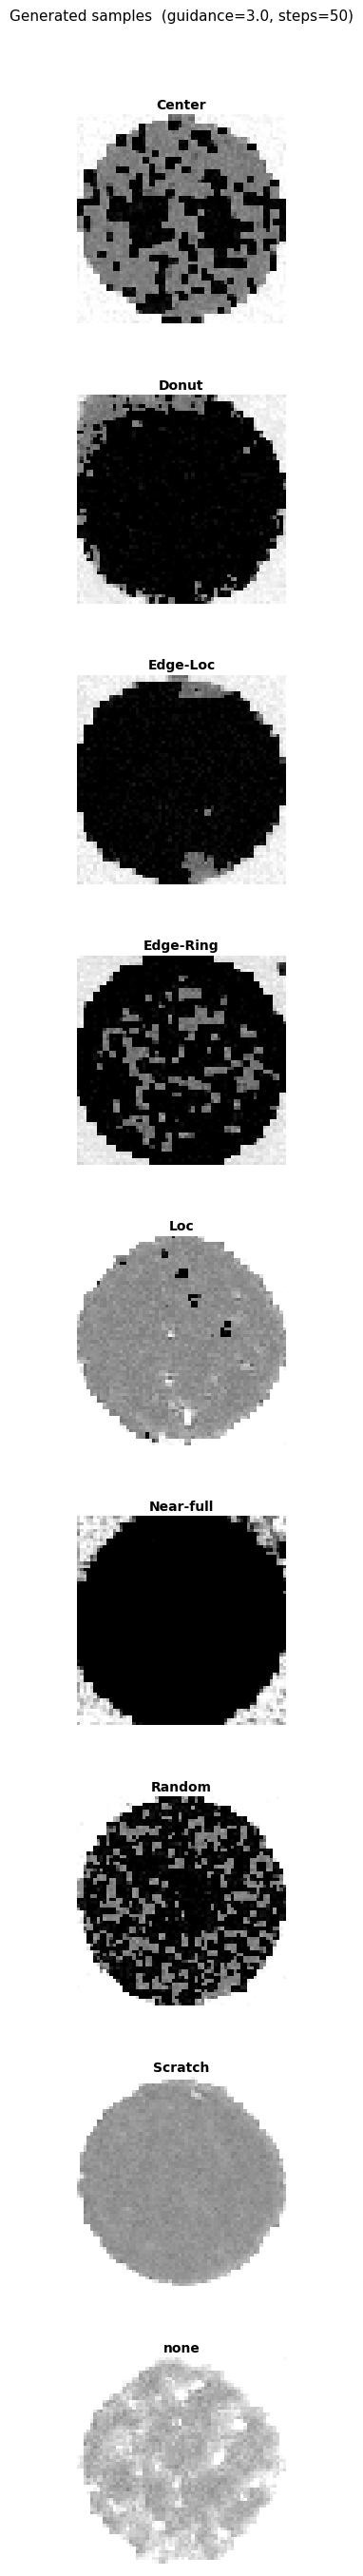


Epoch 21/200


Train: 100%|██████████| 1269/1269 [01:54<00:00, 11.06it/s, loss=0.0051, avg=0.0154]


  avg loss: 0.015437
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_21_best.pt

Epoch 22/200


Train: 100%|██████████| 1269/1269 [01:54<00:00, 11.05it/s, loss=0.0196, avg=0.0163]

  avg loss: 0.016313

Epoch 23/200


...

  avg loss: 0.014585

Epoch 39/200



Train: 100%|██████████| 1269/1269 [01:56<00:00, 10.93it/s, loss=0.0169, avg=0.0148]

  avg loss: 0.014753

Epoch 40/200



Train: 100%|██████████| 1269/1269 [01:56<00:00, 10.91it/s, loss=0.0138, avg=0.0147]


  avg loss: 0.014666
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_40.pt


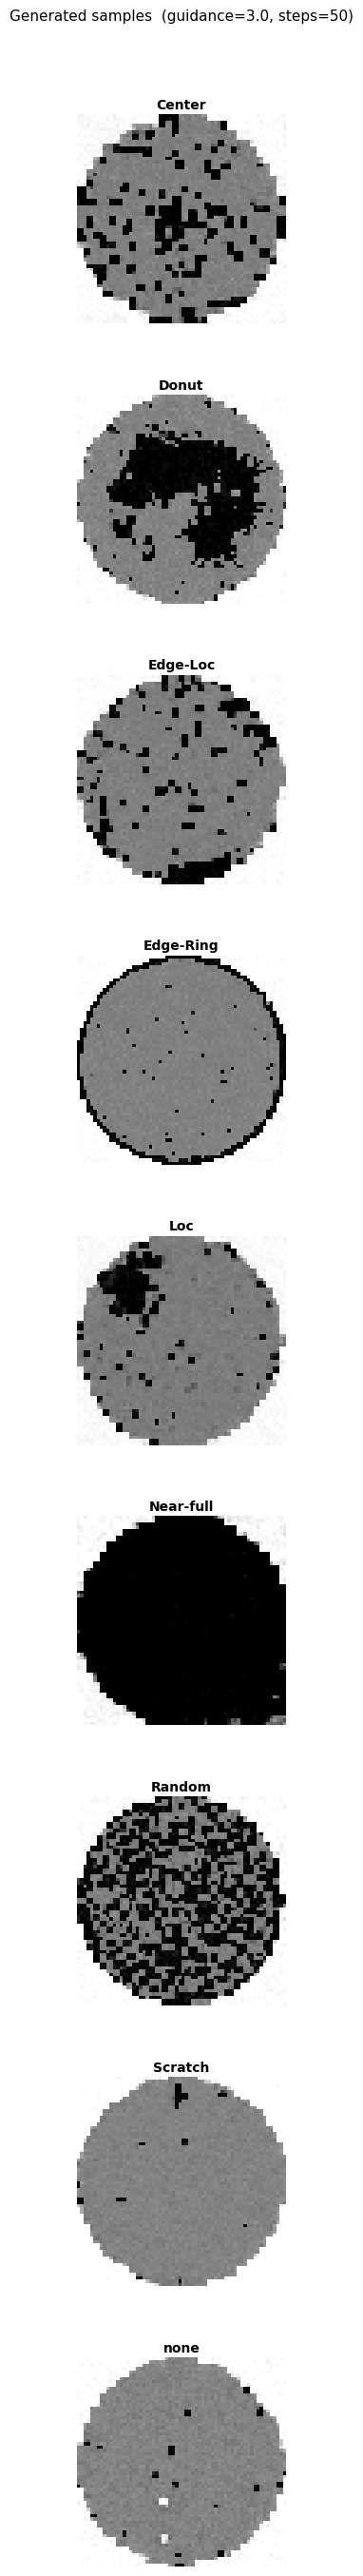


Epoch 41/200


Train: 100%|██████████| 1269/1269 [01:56<00:00, 10.93it/s, loss=0.0149, avg=0.0146]

  avg loss: 0.014599

Epoch 42/200



Train: 100%|██████████| 1269/1269 [01:56<00:00, 10.90it/s, loss=0.0174, avg=0.0140]


  avg loss: 0.014042
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_42_best.pt

Epoch 43/200


...

  avg loss: 0.012777

Epoch 59/200



Train: 100%|██████████| 1269/1269 [01:56<00:00, 10.88it/s, loss=0.0131, avg=0.0127]

  avg loss: 0.012672

Epoch 60/200



Train: 100%|██████████| 1269/1269 [01:56<00:00, 10.86it/s, loss=0.0156, avg=0.0126]


  avg loss: 0.012551
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_60_best.pt


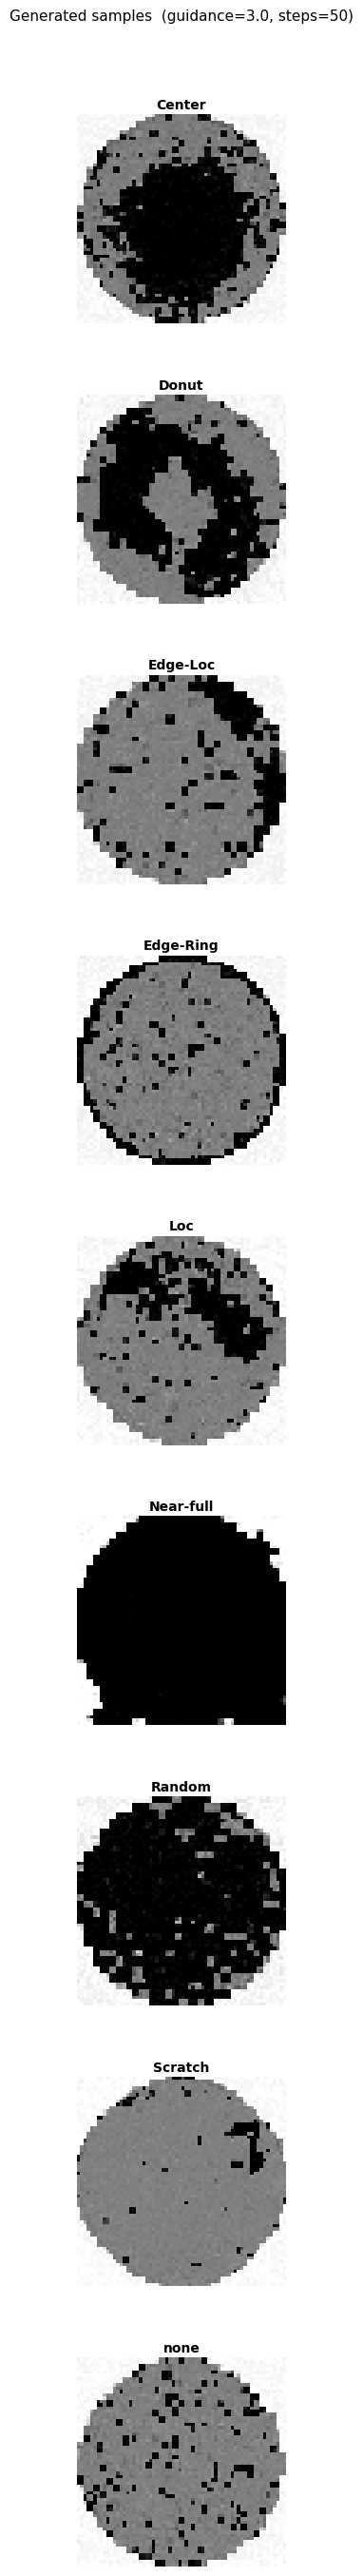


Epoch 61/200


Train: 100%|██████████| 1269/1269 [01:56<00:00, 10.85it/s, loss=0.0132, avg=0.0122]


  avg loss: 0.012227
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_61_best.pt

Epoch 62/200


Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.82it/s, loss=0.0053, avg=0.0123]

  avg loss: 0.012320

Epoch 63/200


...

  avg loss: 0.011485

Epoch 79/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.83it/s, loss=0.0084, avg=0.0113]

  avg loss: 0.011253

Epoch 80/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.83it/s, loss=0.0095, avg=0.0110]


  avg loss: 0.010992
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_80_best.pt


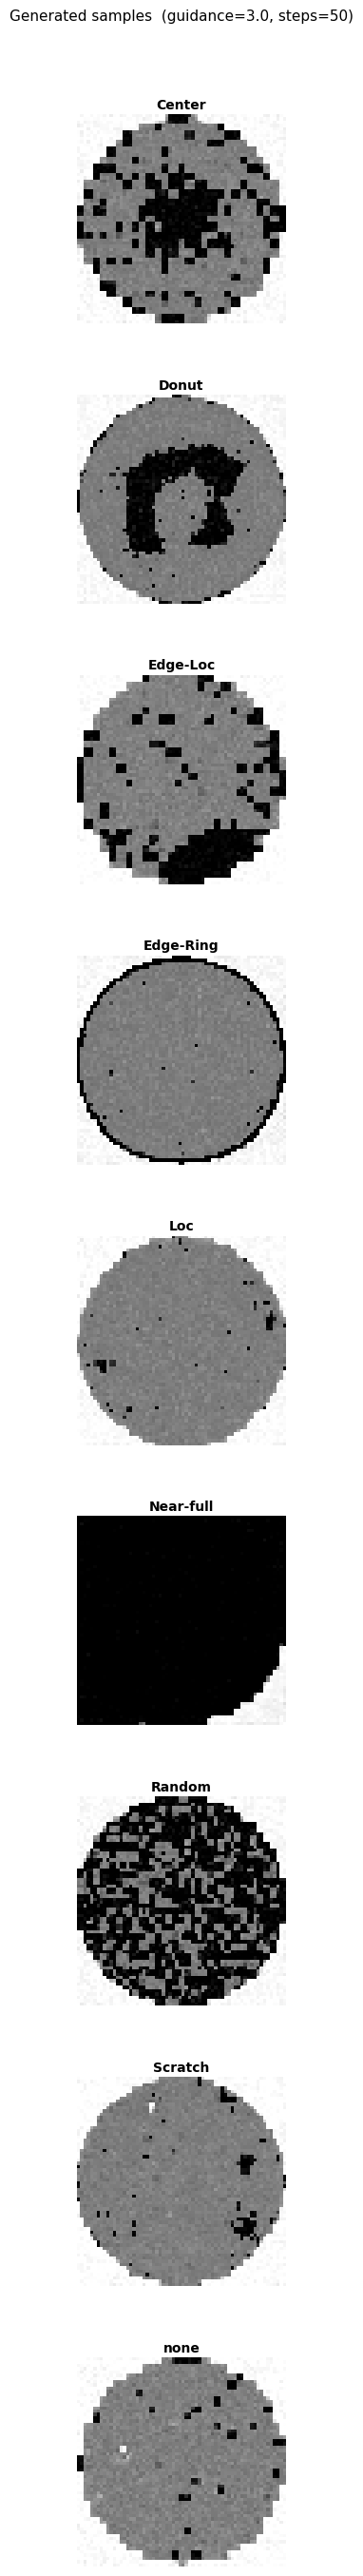


Epoch 81/200


Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.84it/s, loss=0.0254, avg=0.0112]

  avg loss: 0.011233

Epoch 82/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.83it/s, loss=0.0088, avg=0.0111]

  avg loss: 0.011088

Epoch 83/200


...

  avg loss: 0.010741

Epoch 99/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.77it/s, loss=0.0082, avg=0.0103]


  avg loss: 0.010341
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_99_best.pt

Epoch 100/200


Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.81it/s, loss=0.0061, avg=0.0104]


  avg loss: 0.010385
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_100.pt


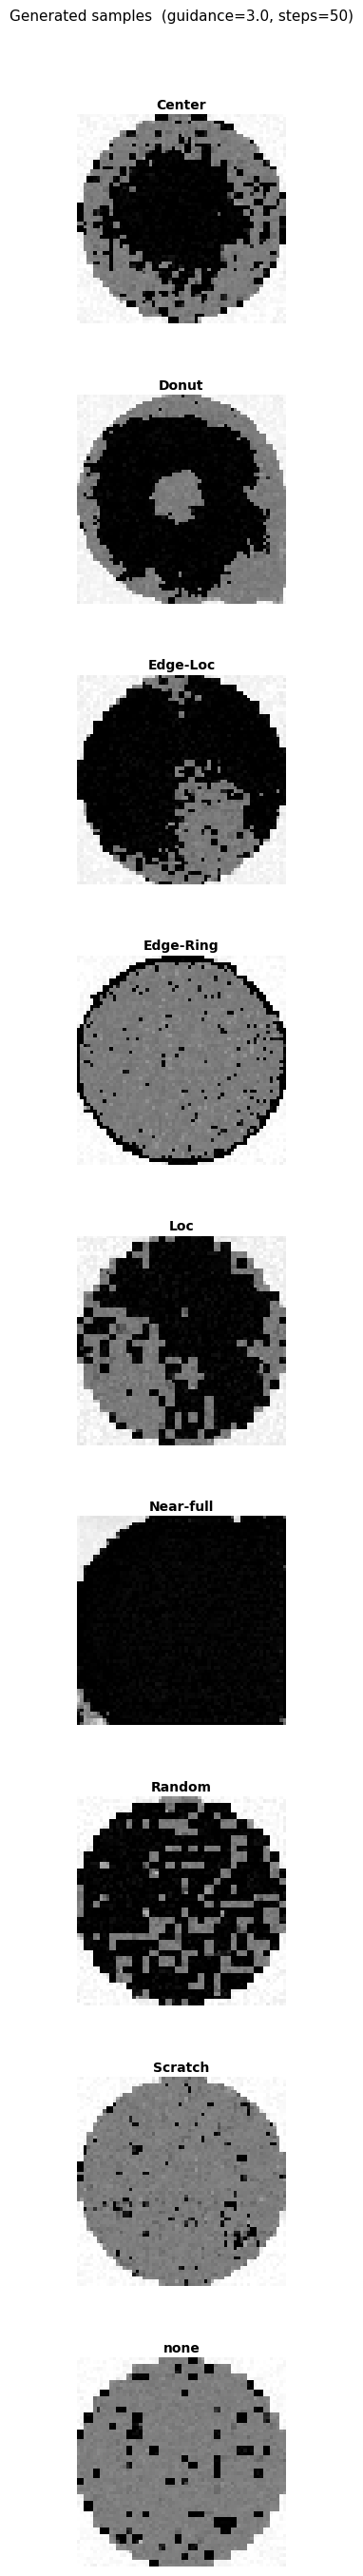


Epoch 101/200


Train: 100%|██████████| 1269/1269 [01:56<00:00, 10.86it/s, loss=0.0121, avg=0.0104]

  avg loss: 0.010410

Epoch 102/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.83it/s, loss=0.0021, avg=0.0106]

  avg loss: 0.010650

Epoch 103/200


...

  avg loss: 0.010216

Epoch 119/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.84it/s, loss=0.0045, avg=0.0103]

  avg loss: 0.010253

Epoch 120/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.81it/s, loss=0.0091, avg=0.0101]


  avg loss: 0.010125
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_120.pt


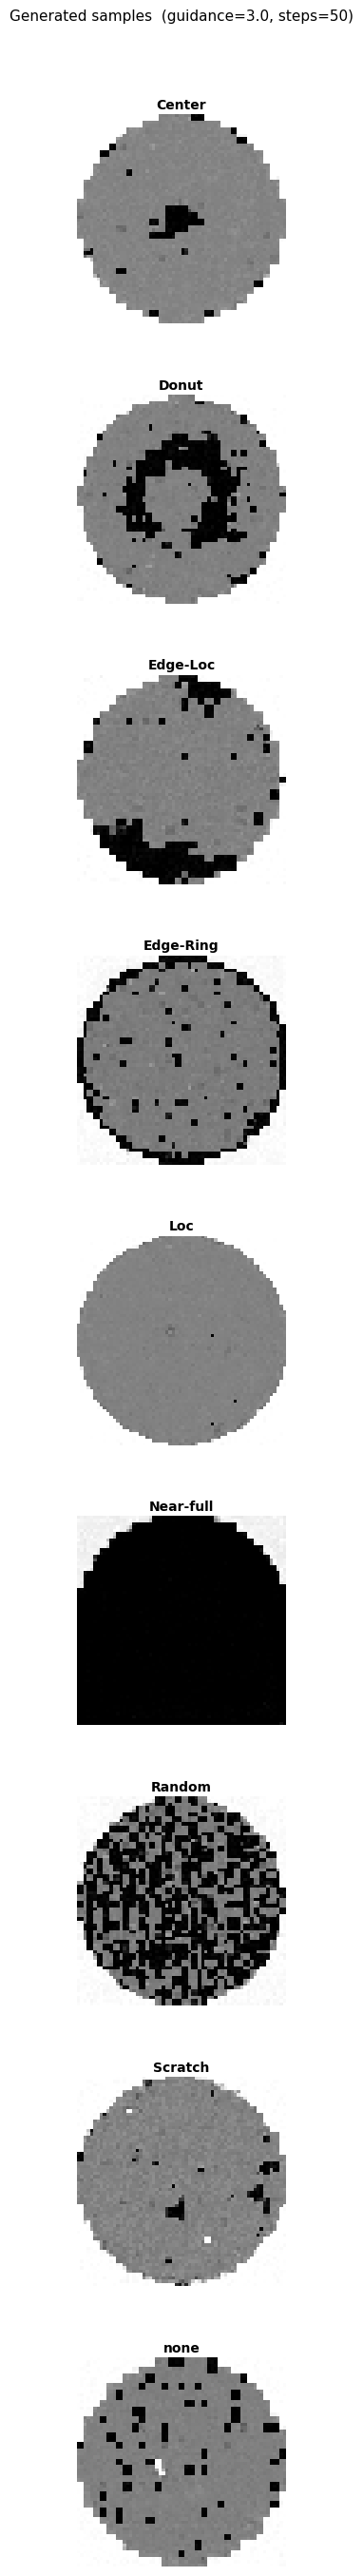


Epoch 121/200


Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.83it/s, loss=0.0067, avg=0.0102]

  avg loss: 0.010215

Epoch 122/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.79it/s, loss=0.0073, avg=0.0101]

  avg loss: 0.010118

Epoch 123/200


...

  avg loss: 0.010037

Epoch 139/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.82it/s, loss=0.0121, avg=0.0102]

  avg loss: 0.010204

Epoch 140/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.78it/s, loss=0.0137, avg=0.0100]


  avg loss: 0.010032
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_140.pt


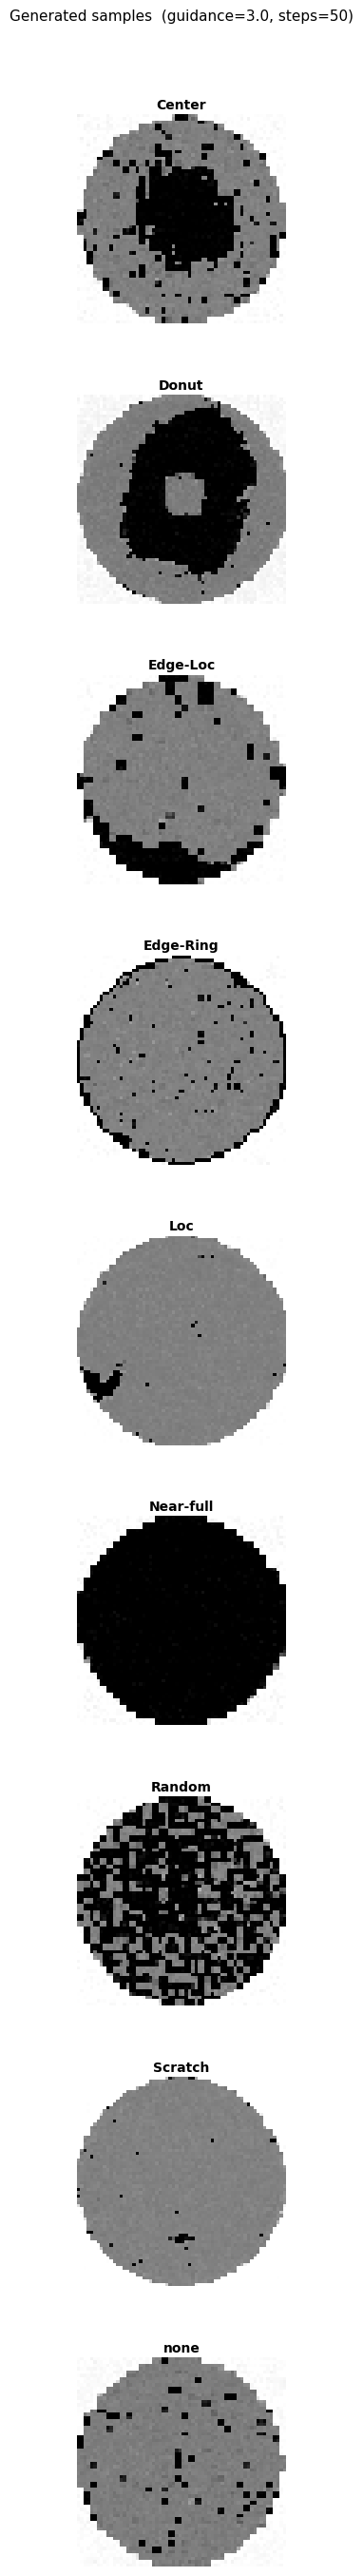


Epoch 141/200


Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.79it/s, loss=0.0065, avg=0.0099]

  avg loss: 0.009922

Epoch 142/200



Train: 100%|██████████| 1269/1269 [01:58<00:00, 10.71it/s, loss=0.0106, avg=0.0097]


  avg loss: 0.009692
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_142_best.pt

Epoch 143/200


...

  avg loss: 0.009470
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_158_best.pt

Epoch 159/200


Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.81it/s, loss=0.0063, avg=0.0095]

  avg loss: 0.009537

Epoch 160/200



Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.80it/s, loss=0.0029, avg=0.0098]


  avg loss: 0.009827
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_160.pt


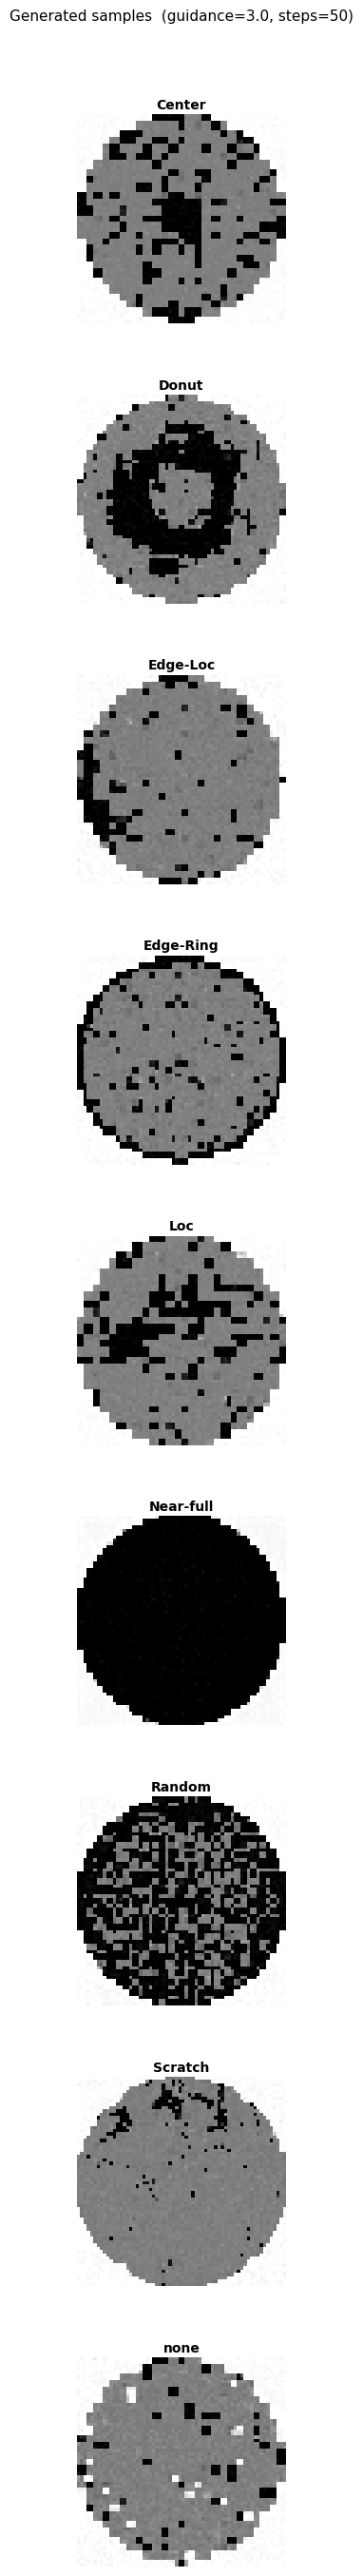


Epoch 161/200


Train: 100%|██████████| 1269/1269 [01:57<00:00, 10.80it/s, loss=0.0125, avg=0.0096]

  avg loss: 0.009554

Epoch 162/200



Train: 100%|██████████| 1269/1269 [01:58<00:00, 10.75it/s, loss=0.0084, avg=0.0095]

  avg loss: 0.009503

Epoch 163/200


...

  avg loss: 0.009256

Epoch 179/200



Train: 100%|██████████| 1269/1269 [01:58<00:00, 10.69it/s, loss=0.0082, avg=0.0096]

  avg loss: 0.009605

Epoch 180/200



Train: 100%|██████████| 1269/1269 [01:58<00:00, 10.69it/s, loss=0.0045, avg=0.0095]


  avg loss: 0.009549
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_180.pt


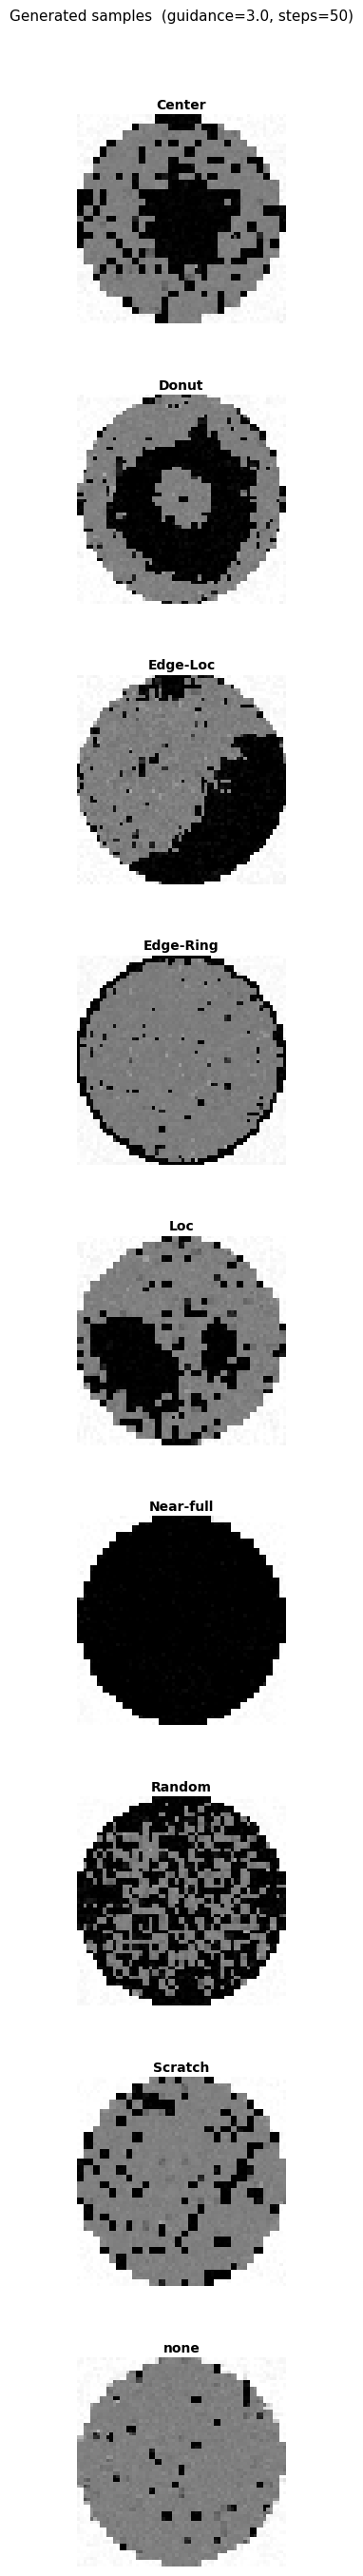


Epoch 181/200


Train: 100%|██████████| 1269/1269 [01:58<00:00, 10.71it/s, loss=0.0054, avg=0.0095]

  avg loss: 0.009537

Epoch 182/200



Train: 100%|██████████| 1269/1269 [01:58<00:00, 10.70it/s, loss=0.0159, avg=0.0095]

  avg loss: 0.009506

Epoch 183/200


...

  avg loss: 0.009218

Epoch 199/200



Train: 100%|██████████| 1269/1269 [01:58<00:00, 10.72it/s, loss=0.0025, avg=0.0094]

  avg loss: 0.009351

Epoch 200/200



Train: 100%|██████████| 1269/1269 [01:58<00:00, 10.70it/s, loss=0.0091, avg=0.0094]


  avg loss: 0.009418
  Saved → /content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_200.pt


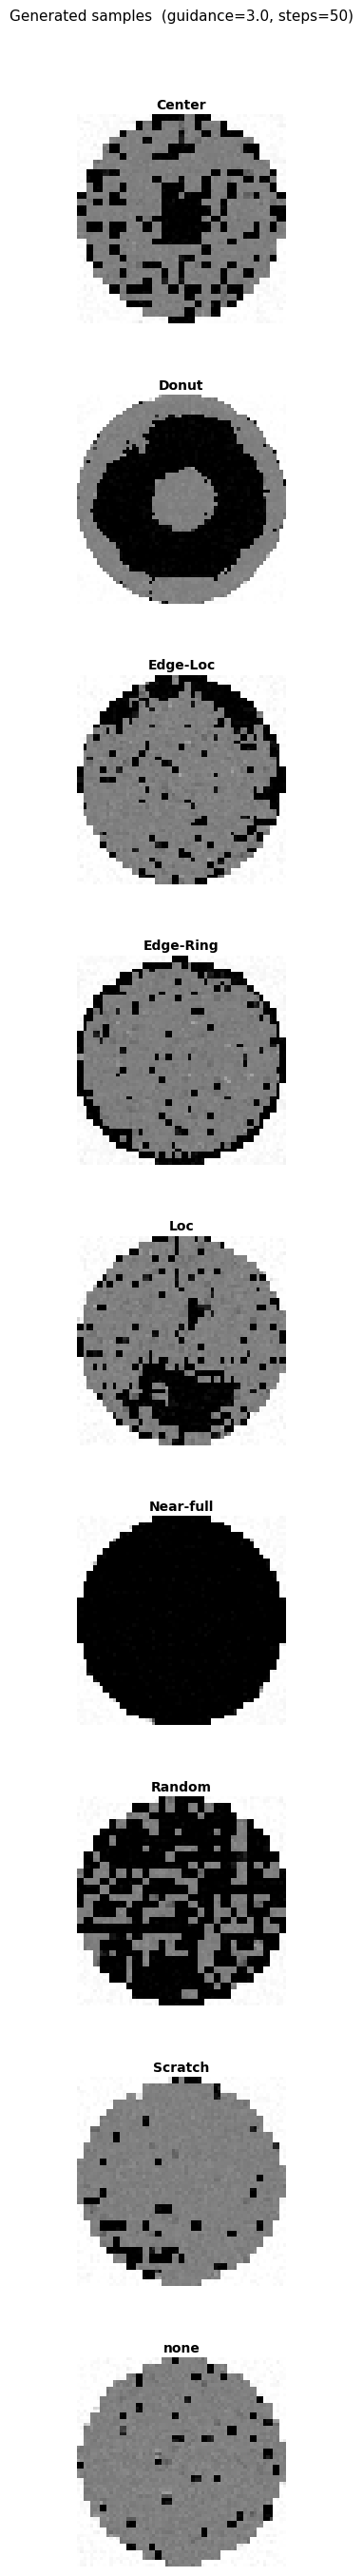

In [ ]:
diffusion.fit(
    epochs=EPOCHS,
    save_every=10,
    log_every=20,
    run_name="cond_diff_wm811k",
)

## 9. Post-Training: Per-Class Image Generation

Load the best checkpoint and visualise generated images for every failure type.

Loaded checkpoint (epoch 193)


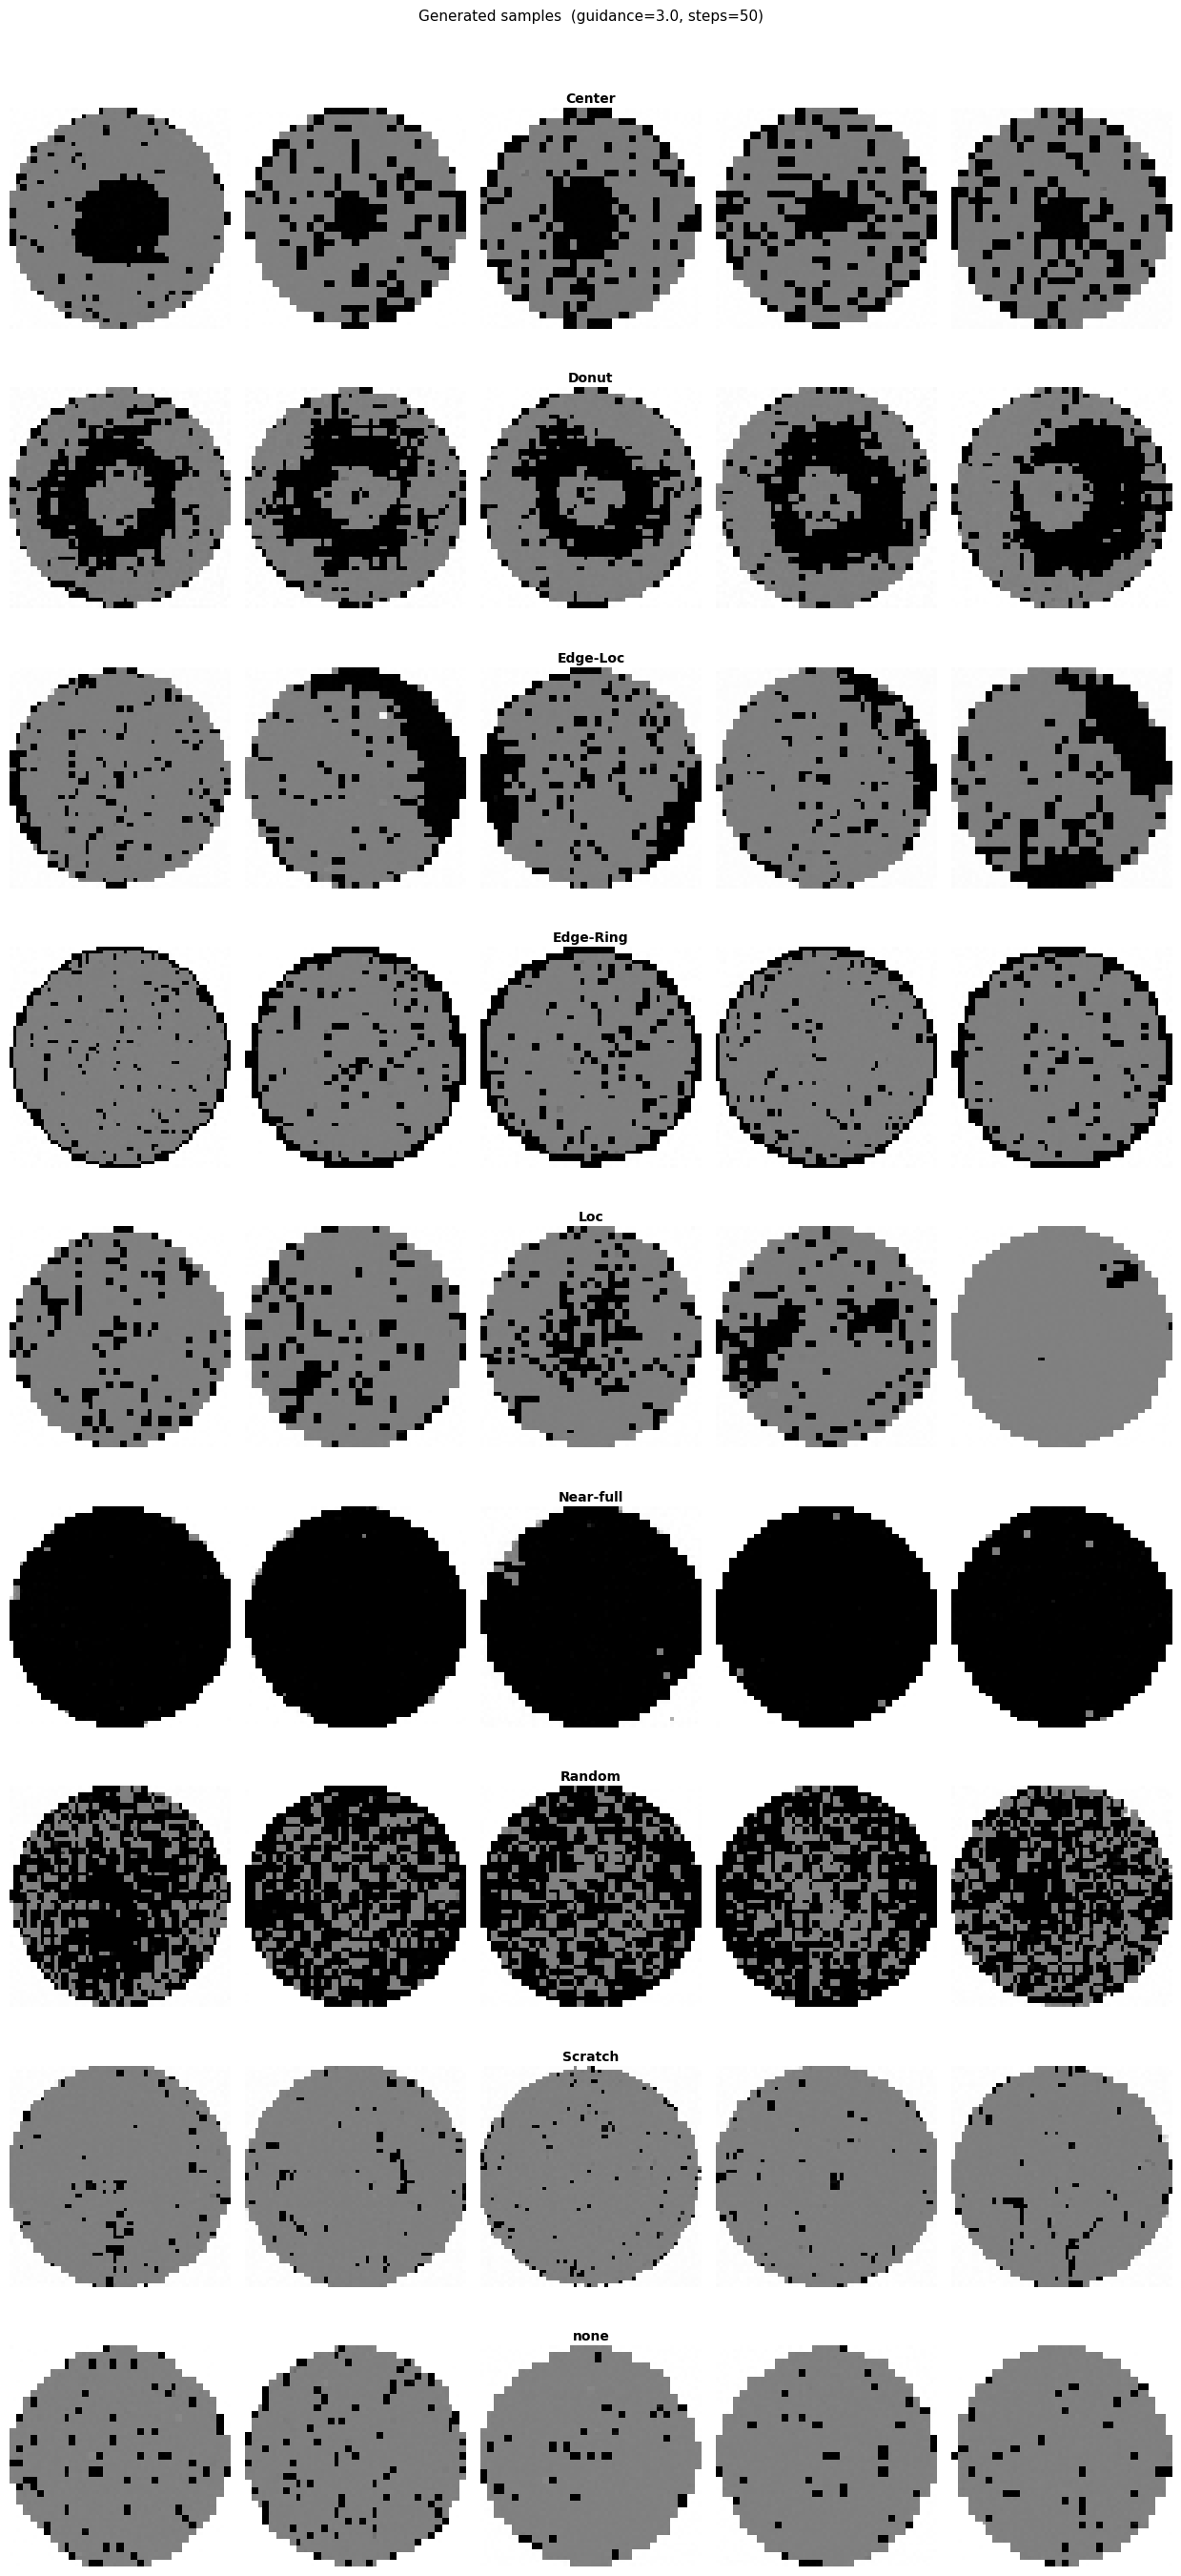

In [ ]:
# Optional: load a specific checkpoint before generating
diffusion.load_model("/content/drive/MyDrive/03_Wafer_Project/checkpoints/cond_diff_wm811k/ckpt_193_best.pt")

# Generate 5 samples per failure class using PLMS + CFG
diffusion.visualize_per_class(
    n_per_class=5,
    guidance_scale=GUIDANCE_SCALE,
    max_t=999,
    steps=50,
)

## 10. Generate & Save Synthetic Dataset

Generate enough synthetic images to up-sample minority classes for the downstream classification task.

In [ ]:
@torch.inference_mode()
def generate_synthetic_dataset(diffusion_model, target_counts,
                                guidance_scale=GUIDANCE_SCALE,
                                steps=50, batch_size=128, seed=SEED):
    """Generate synthetic wafer maps for each failure class using class-label conditioning.
    
    No reference images are needed — generation is purely from learned class embeddings.
    """
    torch.manual_seed(seed)
    dev = diffusion_model.device
    all_data, all_labels = [], []

    total_classes = len(target_counts)
    for cls_idx, (cls, n_needed) in enumerate(target_counts.items(), 1):
        if cls not in FAIL_LABEL2IDX:
            print(f"  Unknown class '{cls}', skipping.")
            continue

        lbl_idx     = FAIL_LABEL2IDX[cls]
        generated   = []
        n_generated = 0          # tracks actual image count (not batch count)

        pbar = tqdm(
            total=n_needed,
            desc=f"  [{cls_idx}/{total_classes}] {cls:12s}",
            unit="img",
            bar_format="{l_bar}{bar:30}{r_bar}",
        )

        while n_generated < n_needed:
            n_batch = min(batch_size, n_needed - n_generated)
            labels  = torch.full((n_batch,), lbl_idx, dtype=torch.long, device=dev)
            imgs    = diffusion_model.sample_plms(labels,
                                                   guidance_scale=guidance_scale,
                                                   steps=steps)
            generated.append(imgs.cpu().numpy())
            n_generated += n_batch
            pbar.update(n_batch)

        pbar.close()
        generated = np.concatenate(generated, axis=0)[:n_needed]
        all_data.append(generated)
        all_labels.extend([cls] * n_needed)

    return np.concatenate(all_data, axis=0), np.array(all_labels)


# ── Compute generation counts ──────────────────────────────────────────────────
# Rule: target real + synthetic = 8,000 images per class. 'none' is excluded — real data is sufficient.
PER_CLASS_TARGET = 8000

TARGET_COUNTS = {}
for cls in FAILURE_CLASSES:
    if cls == 'none':
        continue
    real_count = int((train_labels == cls).sum())
    needed = max(0, PER_CLASS_TARGET - real_count)
    if needed > 0:
        TARGET_COUNTS[cls] = needed

print(f"Synthetic images to generate (Except None , real + syn = {PER_CLASS_TARGET}):")
for cls in FAILURE_CLASSES:
    if cls == 'none':
        real = int((train_labels == cls).sum())
        print(f"  {'none':12s}: skipped  (real={real})")
        continue
    real = int((train_labels == cls).sum())
    gen  = TARGET_COUNTS.get(cls, 0)
    print(f"  {cls:12s}: real={real:5d}  generate={gen:5d}  total={real+gen:5d}")

# ── Run generation ────────────────────────────────────────────────────────────
SYN_DATA_PATH   = "/content/drive/MyDrive/03_Wafer_Project/data/synthetic_data.npy"
SYN_LABELS_PATH = "/content/drive/MyDrive/03_Wafer_Project/data/synthetic_labels.npy"

syn_data, syn_labels = generate_synthetic_dataset(
    diffusion, TARGET_COUNTS,
    guidance_scale=GUIDANCE_SCALE,
    steps=50,
    batch_size=128,
    seed=SEED,
)

np.save(SYN_DATA_PATH,   syn_data)
np.save(SYN_LABELS_PATH, syn_labels)
print(f"\nSaved {len(syn_data)} synthetic images.")
print(f"  data   → {SYN_DATA_PATH}")
print(f"  labels → {SYN_LABELS_PATH}")

Synthetic images to generate (per-class total ≤ min(8000, real×4), none skipped):
  Center      : real= 2576  generate= 5424  total= 8000  (cap=8000)
  Donut       : real=  333  generate=  999  total= 1332  (cap=1332)
  Edge-Loc    : real= 3113  generate= 4887  total= 8000  (cap=8000)
  Edge-Ring   : real= 5808  generate= 2192  total= 8000  (cap=8000)
  Loc         : real= 2156  generate= 5844  total= 8000  (cap=8000)
  Near-full   : real=   89  generate=  267  total=  356  (cap=356)
  Random      : real=  520  generate= 1560  total= 2080  (cap=2080)
  Scratch     : real=  716  generate= 2148  total= 2864  (cap=2864)
  none        : skipped  (real=88459)



  [1/8] Center      : 100%|██████████████████████████████| 5424/5424 [29:57<00:00,  3.02img/s]

  [2/8] Donut       : 100%|██████████████████████████████| 999/999 [05:32<00:00,  3.00img/s]

  [3/8] Edge-Loc    : 100%|██████████████████████████████| 4887/4887 [26:59<00:00,  3.02img/s]

  [4/8] Edge-Ring   : 100%|██████████████████████████████| 2192/2192 [12:10<00:00,  3.00img/s]

  [5/8] Loc         : 100%|██████████████████████████████| 5844/5844 [32:15<00:00,  3.02img/s]

  [6/8] Near-full   : 100%|██████████████████████████████| 267/267 [01:28<00:00,  3.01img/s]

  [7/8] Random      : 100%|██████████████████████████████| 1560/1560 [08:38<00:00,  3.01img/s]

  [8/8] Scratch     : 100%|██████████████████████████████| 2148/2148 [11:52<00:00,  3.02img/s]



Saved 23321 synthetic images.
  data   → /content/drive/MyDrive/03_Wafer_Project/data/synthetic_data.npy
  labels → /content/drive/MyDrive/03_Wafer_Project/data/synthetic_labels.npy


## 11. Downstream Classification: ResNet-18

Two experiments are conducted to measure the effect of synthetic data on classification performance.

### Experiment Design

| | Training Data | Validation Method |
|---|---|---|
| **Experiment A** | Real training data only | Best val Macro-F1 epoch → Test evaluation |
| **Experiment B** | Real + Synthetic (up to 8,000 images per failure class, `none` excluded) | Best val Macro-F1 epoch → Test evaluation |

### Data Preprocessing Strategy

- **`none` class**: Full training data used (no cap). Val / Test retain the original distribution → evaluation matches the real-world setting.
- **Exp A training set**: Full real training data (none included)
- **Exp B training set**: Full real training data + synthetic images
  - Target: real + synthetic = **8,000 images per failure class** (`none` excluded)
  - **Synthetic cap**: `real count × 3` per class — prevents rare classes from being overwhelmed by synthetic data

Results include a per-class F1 heatmap, Confusion Matrix, and misclassified sample visualisations.

In [ ]:
### 11-1. Classification Setup & ResNet-18 Model

from sklearn.metrics import (
    f1_score, recall_score, precision_score, accuracy_score, confusion_matrix
)
import torchvision.models as tv_models

# ── Result directory ──────────────────────────────────────────────────────────
RESULT_DIR = "/content/drive/MyDrive/03_Wafer_Project/results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ── Classification hyperparameters ────────────────────────────────────────────
CLF_EPOCHS       = 50
CLF_LR           = 1e-3
CLF_BATCH_SIZE   = 128
CLF_WEIGHT_DECAY = 1e-4

# ── 9 classes total: 8 failure types + 'none' (already in FAILURE_CLASSES) ───
# FAILURE_CLASSES = ['Center','Donut','Edge-Loc','Edge-Ring',
#                    'Loc','Near-full','Random','Scratch','none']  (len=9)
ALL_CLF_CLASSES = FAILURE_CLASSES           # list of 9, 'none' at index 8
N_CLF_CLASSES   = N_CLASSES                 # 9
CLS_LABEL2IDX   = FAIL_LABEL2IDX            # {'Center':0, ..., 'none':8}
CLS_IDX2LABEL   = FAIL_IDX2LABEL            # {0:'Center', ..., 8:'none'}

print(f"Classification task: {N_CLF_CLASSES} classes")
print(ALL_CLF_CLASSES)


# ── ResNet-18 for 1-channel 64×64 wafer maps ─────────────────────────────────
class WaferResNet18(nn.Module):
    """ResNet-18 adapted for grayscale 64×64 wafer-map classification."""

    def __init__(self, num_classes=N_CLF_CLASSES):
        super().__init__()
        backbone = tv_models.resnet18(weights=None)
        # 1-channel grayscale: replace 3-ch conv with 1-ch, smaller stride
        backbone.conv1  = nn.Conv2d(1, 64, kernel_size=3, stride=1,
                                    padding=1, bias=False)
        # Disable maxpool to avoid over-downsampling at 64×64
        backbone.maxpool = nn.Identity()
        # Final FC for num_classes
        backbone.fc = nn.Linear(512, num_classes)
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)


n_params = sum(p.numel() for p in WaferResNet18().parameters())
print(f"WaferResNet18 parameters: {n_params:,}")

Classification task: 9 classes
['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
WaferResNet18 parameters: 11,172,297


In [ ]:
### 11-2. Dataset Classes, Training & Evaluation Utilities

def _real_to_tensor(arr):
    """arr : (1, H, W) float32 with values {0, 1, 2}
    Returns (1, H, W) float32 tensor ≈ {0.000, 0.498, 0.996},
    matching the WaferDataset preprocessing used during diffusion training.
    """
    img_u8 = (arr.squeeze() * 127).clip(0, 255).astype(np.uint8)
    return torch.from_numpy(img_u8.astype(np.float32) / 255.0).unsqueeze(0)


def _maybe_augment(img_np, do_aug):
    """img_np : (1, H, W) float32.  Random H/V flip + 0/90/180/270° rot if do_aug."""
    if not do_aug:
        return img_np
    img_np = img_np.copy()                              # always work on a fresh copy
    if np.random.random() < 0.5:
        img_np = np.flip(img_np, axis=2).copy()        # horizontal flip
    if np.random.random() < 0.5:
        img_np = np.flip(img_np, axis=1).copy()        # vertical flip
    k = np.random.randint(0, 4)                        # 0 / 90 / 180 / 270°
    if k:
        img_np = np.rot90(img_np, k=k, axes=(1, 2)).copy()
    return img_np


class WaferClfDataset(Dataset):
    """Real wafer data with optional per-class augmentation.
    aug_classes : iterable of label strings to augment; None → no aug (val/test).
    """
    def __init__(self, data, labels, label2idx, aug_classes=None):
        self.data       = data
        self.int_labels = np.array([label2idx[l] for l in labels], dtype=np.int64)
        aug_set         = set(aug_classes) if aug_classes else set()
        self.do_aug     = np.array([l in aug_set for l in labels], dtype=bool)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = _maybe_augment(self.data[idx], bool(self.do_aug[idx]))
        return _real_to_tensor(img), int(self.int_labels[idx])


class WaferClfDatasetMixed(Dataset):
    """Combined real + synthetic wafer data with optional per-class augmentation.

    Real  (is_syn=False): {0, 1, 2} → ×127÷255 → ≈{0.000, 0.498, 0.996}
    Synth (is_syn=True) : already [0,1], values ≈{0, ~0.498, ~0.996} — used as-is.

    aug_classes : iterable of label strings to augment (e.g. all failure types
                  except 'none').  Applied to BOTH real and synthetic failure samples.
    """
    def __init__(self, data, labels, label2idx, is_syn_mask, aug_classes=None):
        self.data       = data
        self.int_labels = np.array([label2idx[l] for l in labels], dtype=np.int64)
        self.is_syn     = is_syn_mask
        aug_set         = set(aug_classes) if aug_classes else set()
        self.do_aug     = np.array([l in aug_set for l in labels], dtype=bool)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = _maybe_augment(self.data[idx], bool(self.do_aug[idx]))
        if self.is_syn[idx]:
            img_t = torch.from_numpy(img.copy().astype(np.float32))
        else:
            img_t = _real_to_tensor(img)
        return img_t, int(self.int_labels[idx])


# ── Class-weight helper ───────────────────────────────────────────────────────
def make_class_weights(labels, label2idx, n_classes, device):
    """Compute inverse-frequency class weights for CrossEntropyLoss."""
    idxs   = np.array([label2idx[l] for l in labels])
    counts = np.bincount(idxs, minlength=n_classes).astype(float)
    counts = np.maximum(counts, 1.0)
    w      = 1.0 / counts
    w      = w / w.sum() * n_classes           # normalise: mean weight = 1
    return torch.tensor(w, dtype=torch.float32, device=device)


# ── Train / eval one epoch (no inner tqdm — epoch bar in run_experiment) ──────
def train_epoch_clf(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += out.argmax(1).eq(lbls).sum().item()
        total      += lbls.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def eval_epoch_clf(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        out         = model(imgs)
        total_loss += criterion(out, lbls).item()
        all_preds.extend(out.argmax(1).cpu().tolist())
        all_labels.extend(lbls.cpu().tolist())
    p = np.array(all_preds)
    l = np.array(all_labels)

    return (
        total_loss / len(loader),
        accuracy_score(l, p),
        f1_score(l, p, average='macro', zero_division=0),
        recall_score(l, p, average='macro', zero_division=0),
        precision_score(l, p, average='macro', zero_division=0),
        l, p,
    )


# ── Plot & save training curves ───────────────────────────────────────────────
def save_training_plot(train_losses, val_losses, val_f1s, val_accs,
                       title, save_path, best_epoch=None):
    ep  = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(ep, train_losses, label='Train Loss')
    axes[0].plot(ep, val_losses,   label='Val Loss')
    if best_epoch:
        axes[0].axvline(best_epoch, color='red', ls='--',
                        label=f'Best epoch {best_epoch}')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(ep, val_f1s, color='green', label='Val Macro-F1')
    if best_epoch:
        axes[1].axvline(best_epoch, color='red', ls='--')
        axes[1].axhline(val_f1s[best_epoch - 1], color='red', ls=':',
                        label=f'F1 = {val_f1s[best_epoch - 1]:.4f}')
    axes[1].set_title('Val Macro F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()

    axes[2].plot(ep, val_accs, color='purple', label='Val Accuracy')
    if best_epoch:
        axes[2].axvline(best_epoch, color='red', ls='--')
    axes[2].set_title('Val Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend()

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    out_dir = os.path.dirname(save_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"  Saved → {save_path}")


# ── Run a full experiment ─────────────────────────────────────────────────────
def run_experiment(exp_name, train_ds, val_loader, test_loader,
                   train_labels_all, epochs=CLF_EPOCHS, lr=CLF_LR):
    """
    Train WaferResNet18, track best val Macro-F1 epoch, evaluate on test.

    Args:
        exp_name        : string identifier (used in logs and file names).
        train_ds        : training Dataset.
        val_loader      : DataLoader for validation.
        test_loader     : DataLoader for test.
        train_labels_all: all training labels (strings) for class-weight calc.
        epochs, lr      : training hyperparameters.

    Returns:
        dict with model, metrics, history, and per-sample predictions.
    """

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    train_loader = DataLoader(train_ds, batch_size=CLF_BATCH_SIZE,
                              shuffle=True, num_workers=2, pin_memory=True,
                              drop_last=False)

    class_w   = make_class_weights(train_labels_all, CLS_LABEL2IDX,
                                   N_CLF_CLASSES, device)
    model     = WaferResNet18(num_classes=N_CLF_CLASSES).to(device)
    crit_w    = nn.CrossEntropyLoss(weight=class_w)
    crit_uw   = nn.CrossEntropyLoss()                # unweighted for val/test eval
    optimizer = optim.AdamW(model.parameters(), lr=lr,
                             weight_decay=CLF_WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses, val_losses, val_f1s, val_accs = [], [], [], []
    best_f1, best_epoch, best_state = -1.0, 1, None

    print(f"\n{'='*60}")
    print(f"  {exp_name}  |  {len(train_ds):,} train samples  |  {epochs} epochs")
    print(f"{'='*60}")

    epoch_bar = tqdm(
        range(1, epochs + 1),
        total=epochs,
        desc=f"  {exp_name}",
        unit="ep",
        bar_format="{l_bar}{bar:28}{r_bar}",
    )

    for epoch in epoch_bar:
        tr_loss, tr_acc = train_epoch_clf(model, train_loader,
                                           optimizer, crit_w, device)
        vl_loss, vl_acc, vl_f1, vl_rec, vl_prec, _, _ = eval_epoch_clf(
            model, val_loader, crit_uw, device)
        scheduler.step()

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        val_f1s.append(vl_f1)
        val_accs.append(vl_acc)

        # Best epoch = highest val Macro-F1 (all 9 classes)
        if vl_f1 > best_f1:
            best_f1    = vl_f1
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        epoch_bar.set_postfix(ordered_dict={
            "tr_loss": f"{tr_loss:.3f}",
            "vF1":     f"{vl_f1:.4f}",
            "best":    f"E{best_epoch:02d}({'★' if epoch == best_epoch else ' '})",
        })

    print(f"\n  ✓ Best epoch: E{best_epoch:02d}  "
          f"(val Macro-F1 all-9 = {best_f1:.4f})")

    # Save training plot (val_f1s = full 9-class macro-F1 per epoch)
    save_training_plot(
        train_losses, val_losses, val_f1s, val_accs,
        title=f"{exp_name} – Training Curves",
        save_path=os.path.join(RESULT_DIR,
                               f"{exp_name.replace(' ', '_')}_training.png"),
        best_epoch=best_epoch,
    )

    # Reload best checkpoint → test evaluation
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    _, ts_acc, ts_f1, ts_rec, ts_prec, ts_labels, ts_preds = eval_epoch_clf(
        model, test_loader, crit_uw, device)

    # Per-class F1 on test set
    ts_per_cls_f1 = f1_score(ts_labels, ts_preds,
                              labels=list(range(N_CLF_CLASSES)),
                              average=None, zero_division=0)

    print(f"\n  ── TEST RESULTS ─────────────────────────────────────")
    print(f"  Accuracy         : {ts_acc:.4f}")
    print(f"  Macro F1 (all 9) : {ts_f1:.4f}  ← key metric")
    print(f"  Recall           : {ts_rec:.4f}")
    print(f"  Precision        : {ts_prec:.4f}")
    print(f"\n  Per-class F1:")
    for i, cls in enumerate(ALL_CLF_CLASSES):
        marker = "  " if cls == 'none' else "▶ "
        print(f"    {marker}{cls:12s}: {ts_per_cls_f1[i]:.4f}")

    return dict(
        name=exp_name, model=model, best_epoch=best_epoch,
        train_losses=train_losses, val_losses=val_losses,
        val_f1s=val_f1s, val_accs=val_accs,
        test_acc=ts_acc, test_f1=ts_f1,
        test_rec=ts_rec, test_prec=ts_prec,
        test_per_cls_f1=ts_per_cls_f1,
        test_labels=ts_labels, test_preds=ts_preds,
    )


print("Classification utilities defined.")

Classification utilities defined.


In [ ]:
### 11-3. Experiment A — Original Training Data Only

# ── Build shared val / test loaders (same for BOTH experiments, NEVER modified) ─
# Val/Test keep the original 'none' count → realistic evaluation distribution.
val_ds_clf  = WaferClfDataset(val_data,  val_labels,  CLS_LABEL2IDX)
test_ds_clf = WaferClfDataset(test_data, test_labels, CLS_LABEL2IDX)

val_loader_clf  = DataLoader(val_ds_clf,  batch_size=CLF_BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
test_loader_clf = DataLoader(test_ds_clf, batch_size=CLF_BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

print(f"Val  set: {len(val_ds_clf):,} samples  (none kept as-is for realistic eval)")
print(f"Test set: {len(test_ds_clf):,} samples  (none kept as-is for realistic eval)")

# ── Augmentation classes: all 8 failure types, 'none' is excluded ────────────
# Failure samples (including synthetic in Exp B) get random flip + rot90.
# 'none' is never augmented — its patterns should remain as-is.
CLF_AUG_CLASSES = [c for c in FAILURE_CLASSES if c != 'none']

# ── Downstream ────────

train_data_capped   = train_data
train_labels_capped = train_labels

# ── Experiment A training dataset (full training data) ────────────────────────
print("\nTrain class distribution (Exp A — full training data, no none cap):")
for cls in ALL_CLF_CLASSES:
    cnt = (train_labels_capped == cls).sum()
    tag = "  ← augmented (flip + rot90)" if cls != 'none' else ""
    print(f"  {cls:12s}: {cnt:6d}{tag}")

train_ds_A = WaferClfDataset(train_data_capped, train_labels_capped, CLS_LABEL2IDX,
                              aug_classes=CLF_AUG_CLASSES)

Val  set: 34,590 samples  (none kept as-is for realistic eval)
Test set: 34,590 samples  (none kept as-is for realistic eval)

Train class distribution (Exp A — full training data, no none cap):
  Center      :   2576  ← augmented (flip + rot90)
  Donut       :    333  ← augmented (flip + rot90)
  Edge-Loc    :   3113  ← augmented (flip + rot90)
  Edge-Ring   :   5808  ← augmented (flip + rot90)
  Loc         :   2156  ← augmented (flip + rot90)
  Near-full   :     89  ← augmented (flip + rot90)
  Random      :    520  ← augmented (flip + rot90)
  Scratch     :    716  ← augmented (flip + rot90)
  none        :  88459



  Exp_A  |  103,770 train samples  |  50 epochs


  Exp_A: 100%|████████████████████████████| 50/50 [36:32<00:00, 43.85s/ep, tr_loss=0.037, vF1=0.8974, best=E45( )]



  ✓ Best epoch: E45  (val Macro-F1 all-9 = 0.9003)


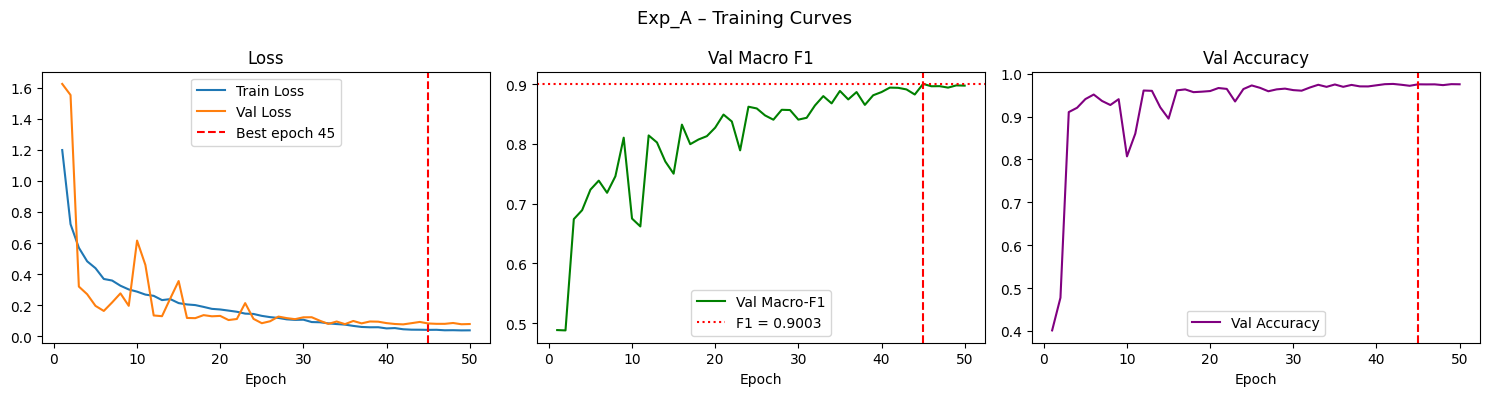

  Saved → /content/drive/MyDrive/03_Wafer_Project/results2/Exp_A_training.png

  ── TEST RESULTS ─────────────────────────────────────
  Accuracy         : 0.9742
  Macro F1 (all 9) : 0.8788  ← key metric
  Recall           : 0.9039
  Precision        : 0.8562

  Per-class F1:
    ▶ Center      : 0.9243
    ▶ Donut       : 0.8597
    ▶ Edge-Loc    : 0.8311
    ▶ Edge-Ring   : 0.9832
    ▶ Loc         : 0.7685
    ▶ Near-full   : 0.9032
    ▶ Random      : 0.8807
    ▶ Scratch     : 0.7692
      none        : 0.9887


In [ ]:
result_A = run_experiment(
    exp_name        = "Exp_A",
    train_ds        = train_ds_A,
    val_loader      = val_loader_clf,
    test_loader     = test_loader_clf,
    train_labels_all= train_labels_capped,
    epochs          = CLF_EPOCHS,
    lr              = CLF_LR,
)

Paths set to default: /content/drive/MyDrive/03_Wafer_Project/data/synthetic_data.npy
Loaded 48,689 synthetic images  shape: (48689, 1, 64, 64)

Synthetic class distribution:
  Center      :   5424
  Donut       :   7667
  Edge-Loc    :   4887
  Edge-Ring   :   2192
  Loc         :   5844
  Near-full   :   7911
  Random      :   7480
  Scratch     :   7284
Per-class distribution (synthetic 상한: real × 3):
  Center      : real= 2576  syn= 5424  total= 8000  (avail=5424, cap=7728)
  Donut       : real=  333  syn=  999  total= 1332  (avail=7667, cap=999)
  Edge-Loc    : real= 3113  syn= 4887  total= 8000  (avail=4887, cap=9339)
  Edge-Ring   : real= 5808  syn= 2192  total= 8000  (avail=2192, cap=17424)
  Loc         : real= 2156  syn= 5844  total= 8000  (avail=5844, cap=6468)
  Near-full   : real=   89  syn=  267  total=  356  (avail=7911, cap=267)
  Random      : real=  520  syn= 1560  total= 2080  (avail=7480, cap=1560)
  Scratch     : real=  716  syn= 2148  total= 2864  (avail=7284, cap

  Exp_B: 100%|████████████████████████████| 50/50 [43:55<00:00, 52.71s/ep, tr_loss=0.014, vF1=0.8954, best=E47( )]



  ✓ Best epoch: E47  (val Macro-F1 all-9 = 0.8965)


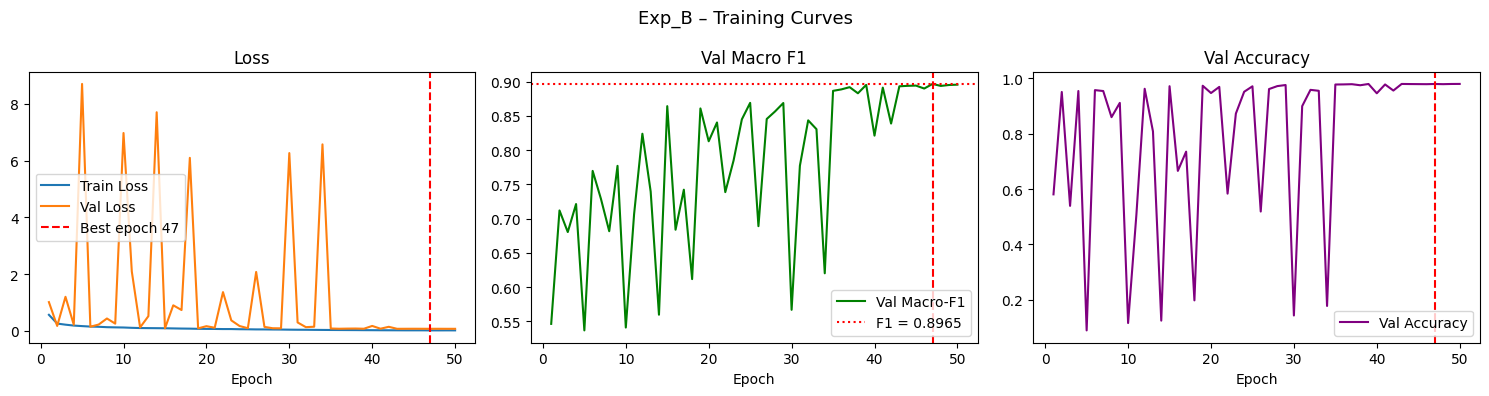

  Saved → /content/drive/MyDrive/03_Wafer_Project/results2/Exp_B_training.png

  ── TEST RESULTS ─────────────────────────────────────
  Accuracy         : 0.9782
  Macro F1 (all 9) : 0.8940  ← key metric
  Recall           : 0.8980
  Precision        : 0.8910

  Per-class F1:
    ▶ Center      : 0.9331
    ▶ Donut       : 0.8522
    ▶ Edge-Loc    : 0.8398
    ▶ Edge-Ring   : 0.9832
    ▶ Loc         : 0.8006
    ▶ Near-full   : 0.9355
    ▶ Random      : 0.9091
    ▶ Scratch     : 0.8018
      none        : 0.9906


In [ ]:
### 11-4. Experiment B — Original + Synthetic Training Data

# ── Free GPU memory from Experiment A before allocating a new model ───────────
import gc
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

# ── Ensure synthetic data paths are defined (fallback if Cell 28 / Section 10 was skipped) ─
try:
    SYN_DATA_PATH
except NameError:
    SYN_DATA_PATH   = "/content/drive/MyDrive/03_Wafer_Project/data/synthetic_data.npy"
    SYN_LABELS_PATH = "/content/drive/MyDrive/03_Wafer_Project/data/synthetic_labels.npy"
    print(f"Paths set to default: {SYN_DATA_PATH}")

# ── Load synthetic data (generated in Section 10) ────────────────────────────
syn_data_B   = np.load(SYN_DATA_PATH)
syn_labels_B = np.load(SYN_LABELS_PATH)

print(f"Loaded {len(syn_data_B):,} synthetic images  shape: {syn_data_B.shape}")
print("\nSynthetic class distribution:")
for cls, cnt in zip(*np.unique(syn_labels_B, return_counts=True)):
    print(f"  {cls:12s}: {cnt:6d}")

# ── Build combined training dataset (real + synthetic) ───────────────────────
try:
    train_data_capped
    train_labels_capped
except NameError:
    train_data_capped   = train_data
    train_labels_capped = train_labels

# Cap on synthetic usage: real count per class × 4
# (Section 10 generated 8,000 images per class, but for rare classes the synthetic
#  proportion could become too large relative to real data.)
SYN_CAP_MULTIPLIER = 3
rng_syn = np.random.default_rng(SEED)

selected_syn_idx = []
for cls in FAILURE_CLASSES:
    if cls == 'none':
        continue
    real_count = int((train_labels_capped == cls).sum())
    syn_cap    = real_count * SYN_CAP_MULTIPLIER
    cls_idx    = np.where(syn_labels_B == cls)[0]
    n_use      = min(len(cls_idx), syn_cap)
    if n_use > 0:
        chosen = rng_syn.choice(cls_idx, size=n_use, replace=False)
        selected_syn_idx.append(chosen)

selected_syn_idx = np.concatenate(selected_syn_idx) if selected_syn_idx else np.array([], dtype=int)
combined_data   = np.concatenate([train_data_capped,   syn_data_B[selected_syn_idx]],   axis=0)
combined_labels = np.concatenate([train_labels_capped, syn_labels_B[selected_syn_idx]], axis=0)

is_syn_mask = np.zeros(len(combined_labels), dtype=bool)
is_syn_mask[len(train_data_capped):] = True

print(f"Per-class distribution (synthetic cap: real × {SYN_CAP_MULTIPLIER}):")
for cls in ALL_CLF_CLASSES:
    r = (combined_labels[~is_syn_mask] == cls).sum()
    s = (combined_labels[is_syn_mask] == cls).sum()
    avail = int((syn_labels_B == cls).sum()) if cls != 'none' else 0
    cap   = r * SYN_CAP_MULTIPLIER if cls != 'none' else 0
    print(f"  {cls:12s}: real={r:5d}  syn={s:5d}  total={r+s:5d}"
          + (f"  (avail={avail}, cap={cap})" if cls != 'none' else ""))

# CLF_AUG_CLASSES: flip+rot90 applied to all failure samples (real + synthetic), NOT 'none'.
try:
    CLF_AUG_CLASSES
except NameError:
    CLF_AUG_CLASSES = [c for c in FAILURE_CLASSES if c != 'none']

train_ds_B     = WaferClfDatasetMixed(combined_data, combined_labels,
                                       CLS_LABEL2IDX, is_syn_mask,
                                       aug_classes=CLF_AUG_CLASSES)
train_labels_B = combined_labels

print(f"\nCombined training size: {len(train_ds_B):,}")
print("\nCombined class distribution (real + synthetic):")
for cls in ALL_CLF_CLASSES:
    cnt   = (combined_labels == cls).sum()
    s_cnt = (combined_labels[is_syn_mask] == cls).sum()
    tag   = f"  ({s_cnt:,} syn, augmented)" if s_cnt > 0 else \
            ("  ← augmented" if cls != 'none' else "")
    print(f"  {cls:12s}: {cnt:6d}{tag}")

result_B = run_experiment(
    exp_name        = "Exp_B",
    train_ds        = train_ds_B,
    val_loader      = val_loader_clf,
    test_loader     = test_loader_clf,
    train_labels_all= train_labels_B,
    epochs          = CLF_EPOCHS,
    lr              = CLF_LR,
)


  TEST SET COMPARISON: Exp A vs Exp B
Metric                    Exp A (real)  Exp B (+synth)     Δ (B−A)
--------------------------------------------------------------
Accuracy                        0.9742          0.9782  +   0.0040
Macro F1 (all 9)                0.8788          0.8940  +   0.0152 ← key
Recall                          0.9039          0.8980    -0.0059
Precision                       0.8562          0.8910  +   0.0348


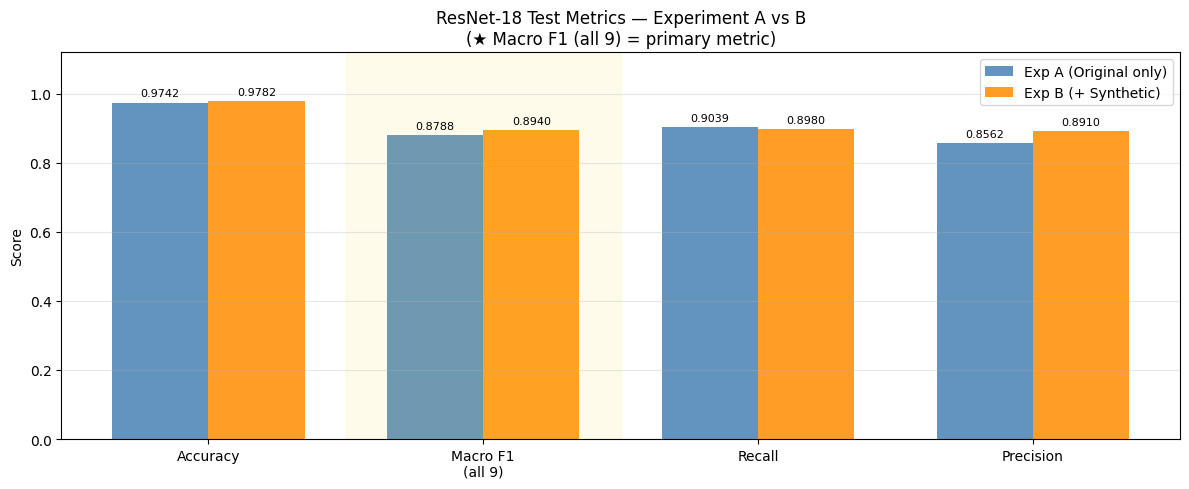

Saved → /content/drive/MyDrive/03_Wafer_Project/results2/comparison_metrics.png


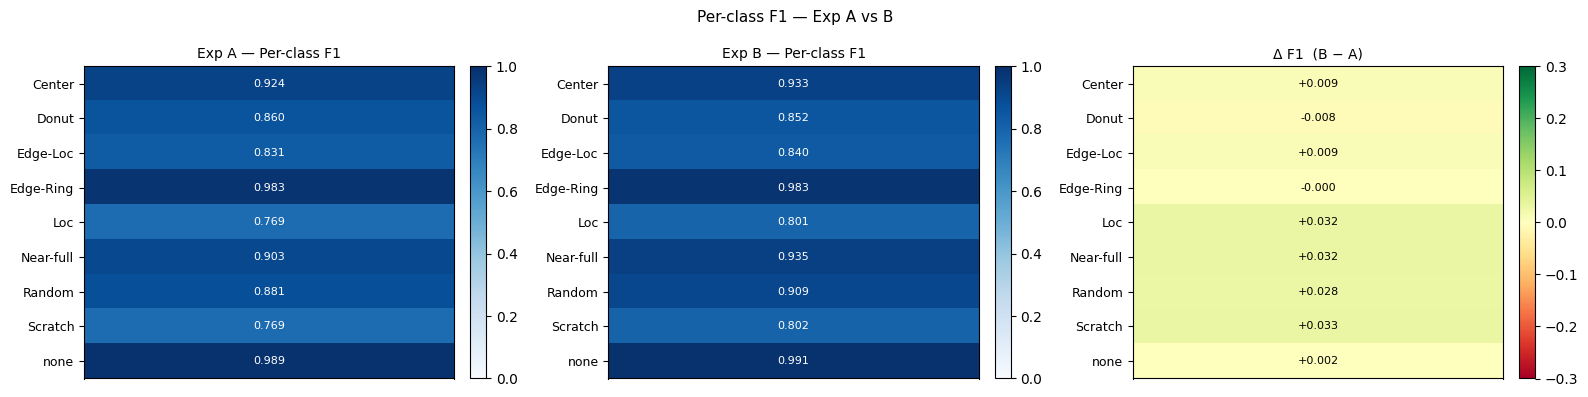

Saved → /content/drive/MyDrive/03_Wafer_Project/results2/comparison_per_class_f1.png


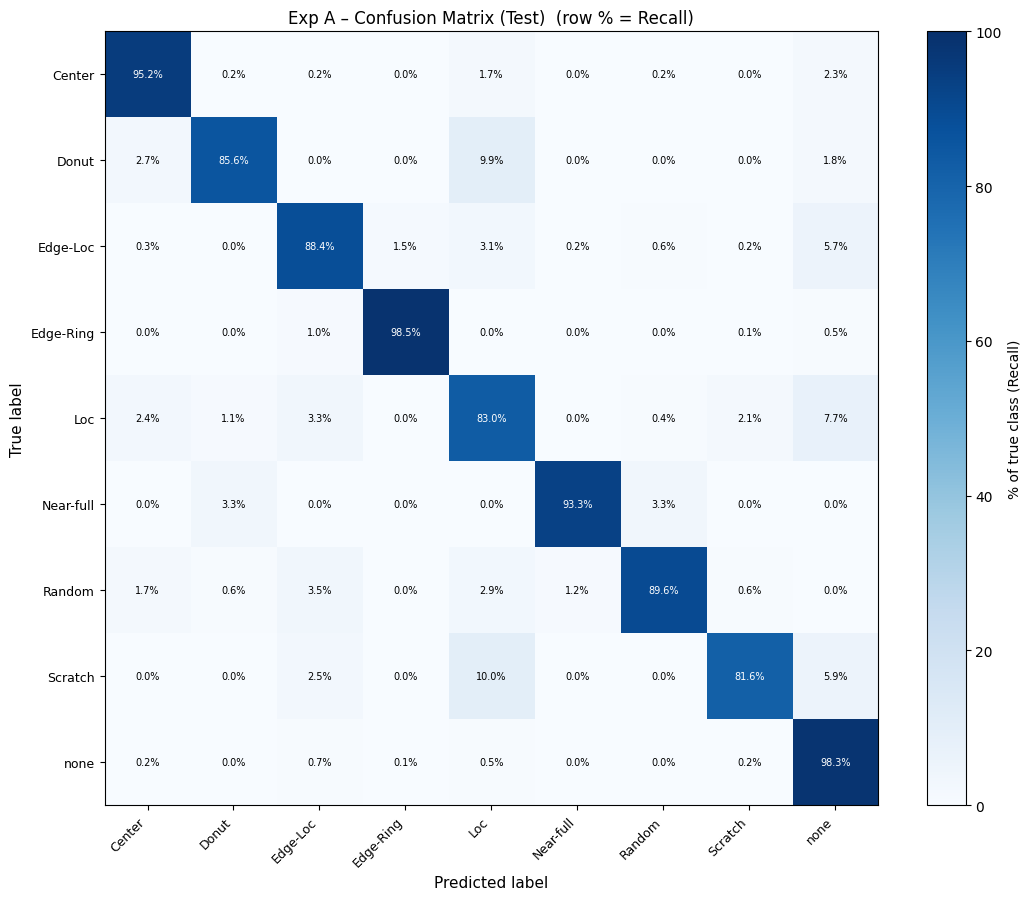

Saved (row % = Recall) → /content/drive/MyDrive/03_Wafer_Project/results2/ExpA_confusion_matrix.png


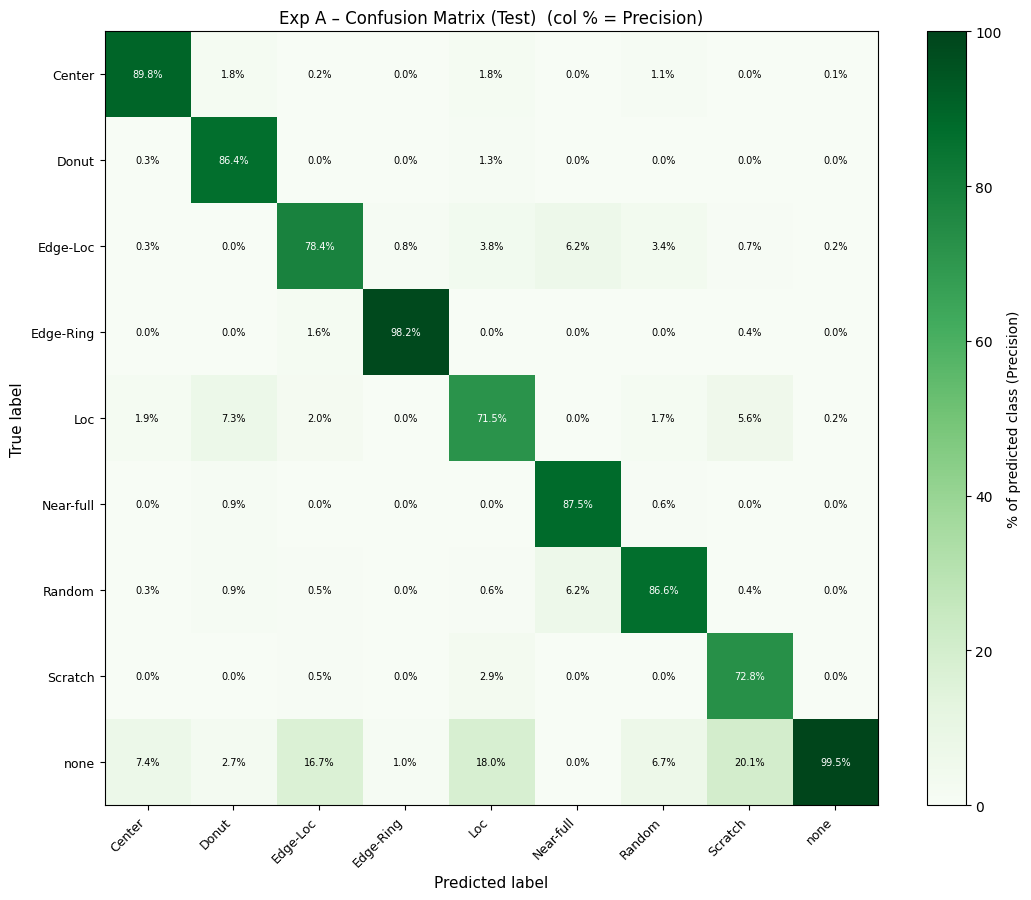

Saved (col % = Precision) → /content/drive/MyDrive/03_Wafer_Project/results2/ExpA_confusion_matrix_col.png


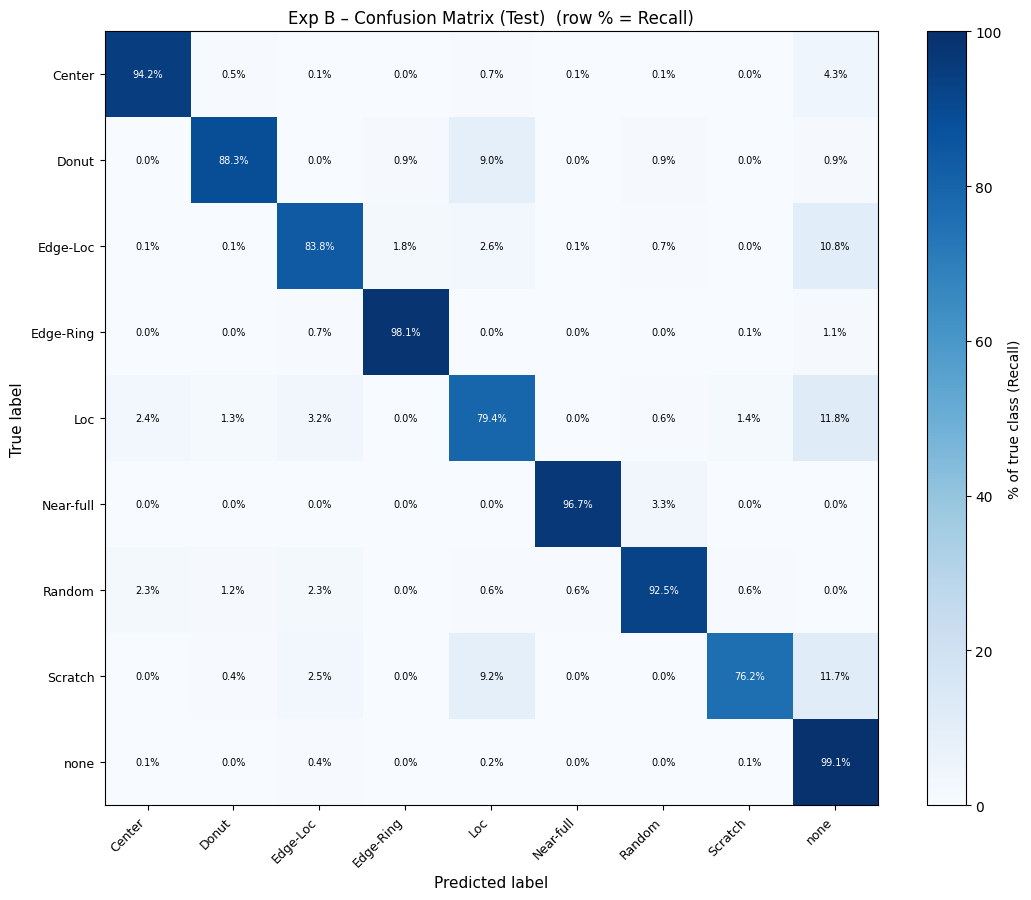

Saved (row % = Recall) → /content/drive/MyDrive/03_Wafer_Project/results2/ExpB_confusion_matrix.png


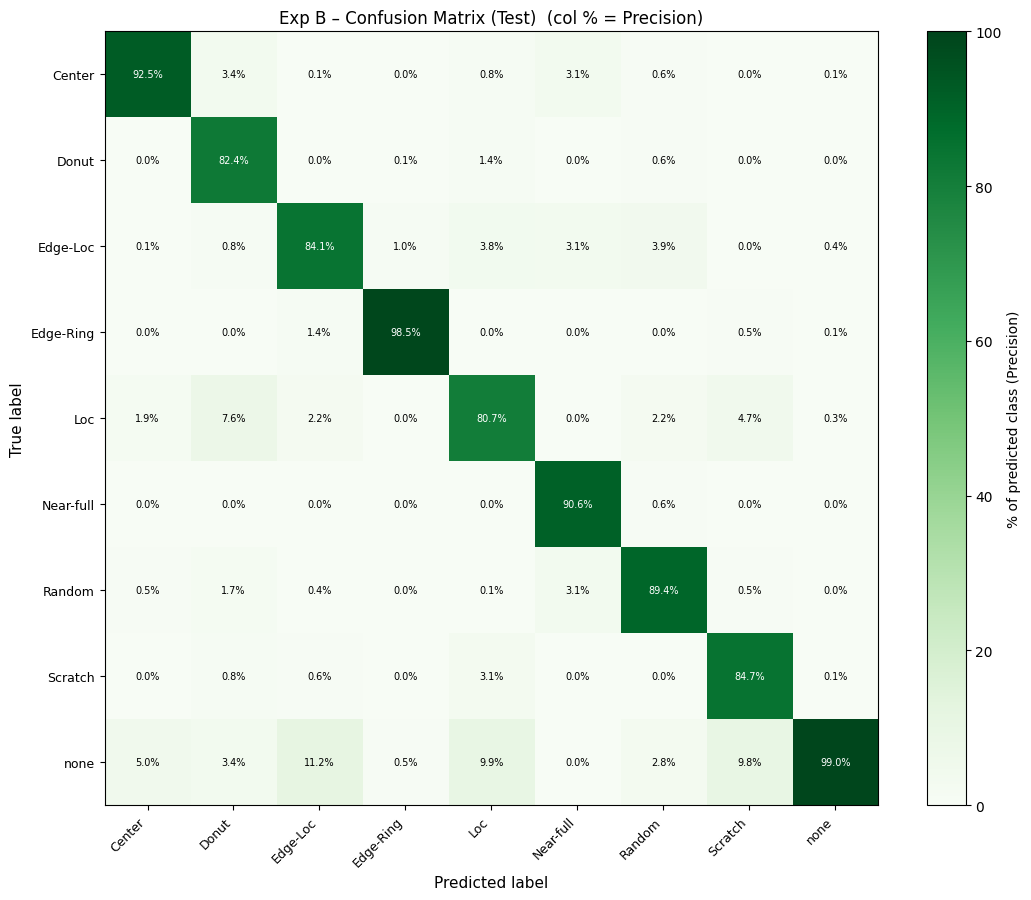

Saved (col % = Precision) → /content/drive/MyDrive/03_Wafer_Project/results2/ExpB_confusion_matrix_col.png


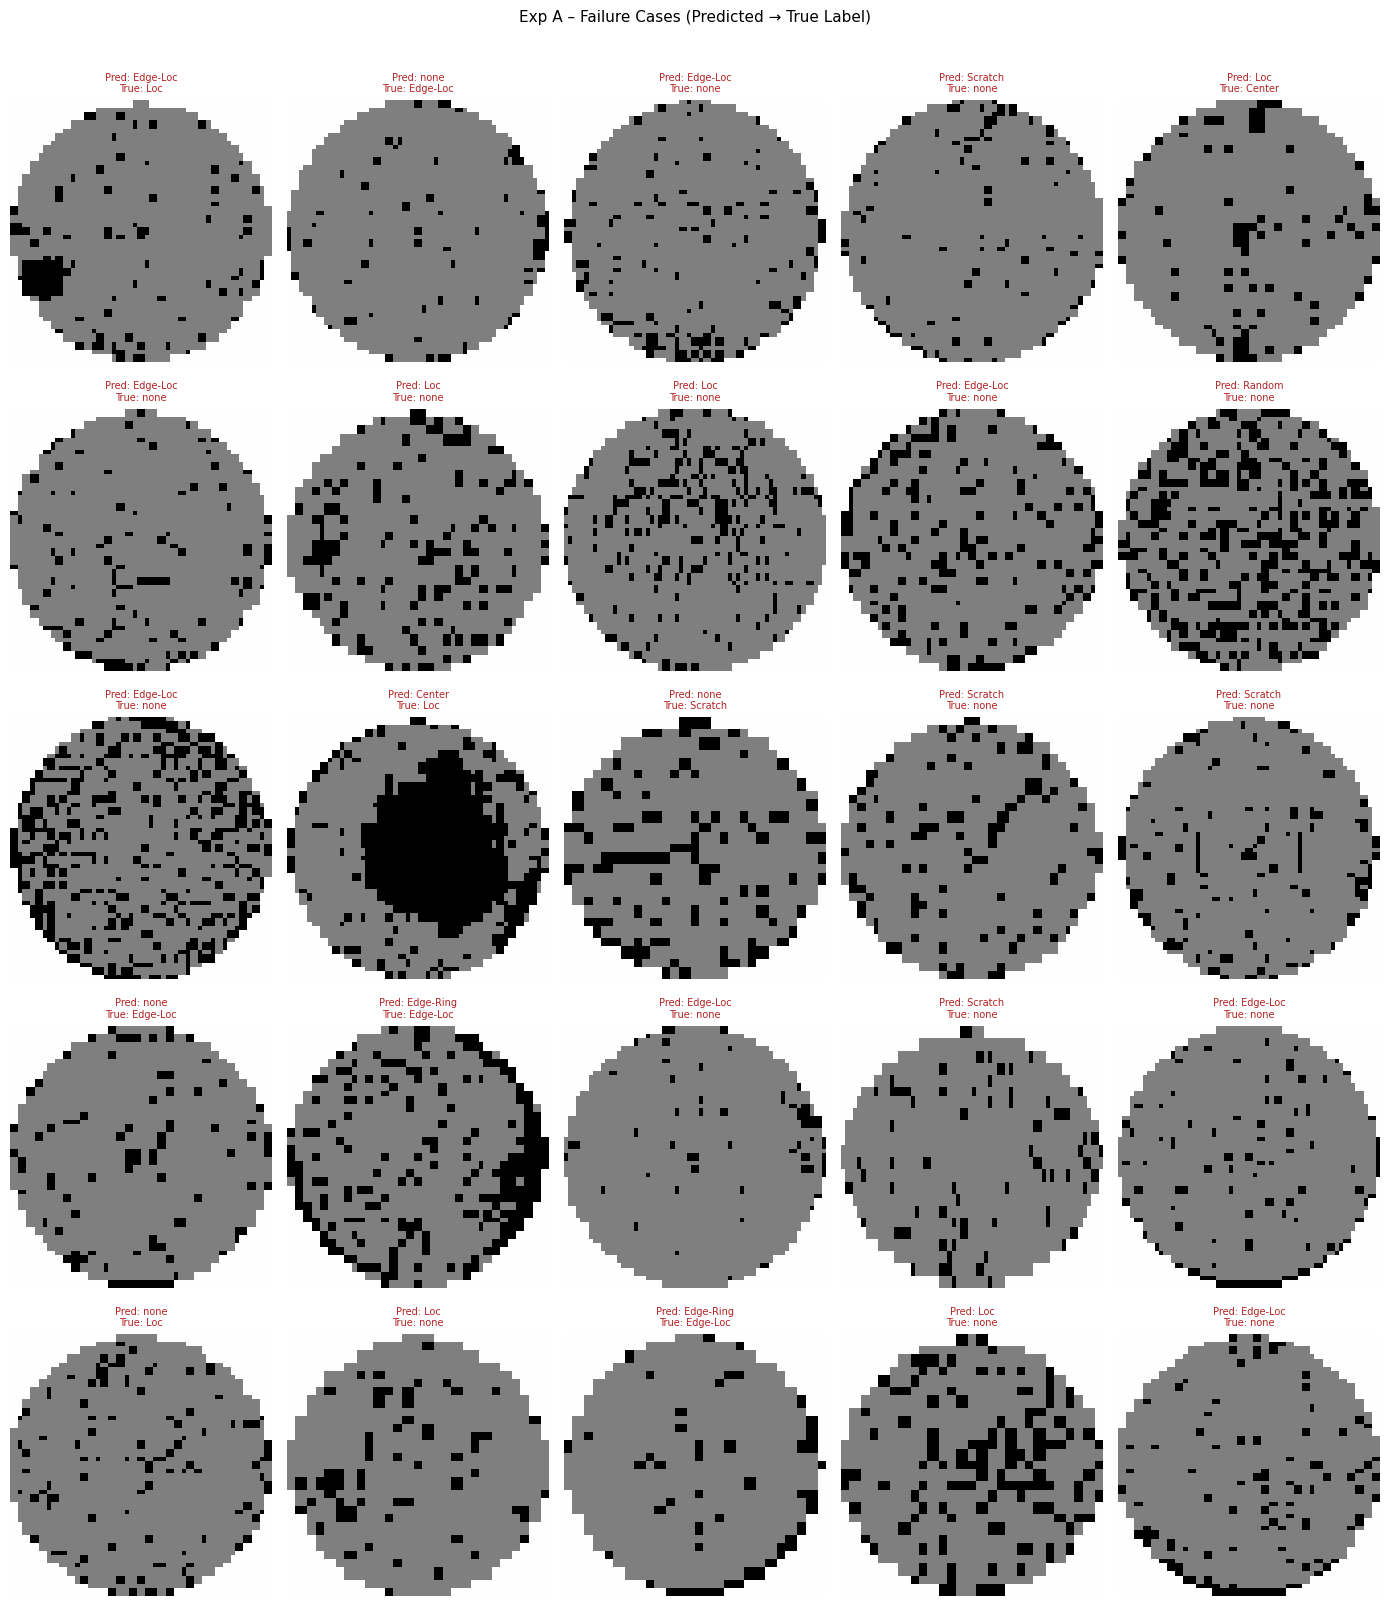

Saved → /content/drive/MyDrive/03_Wafer_Project/results2/ExpA_failure_cases.png  (25 failure cases shown)


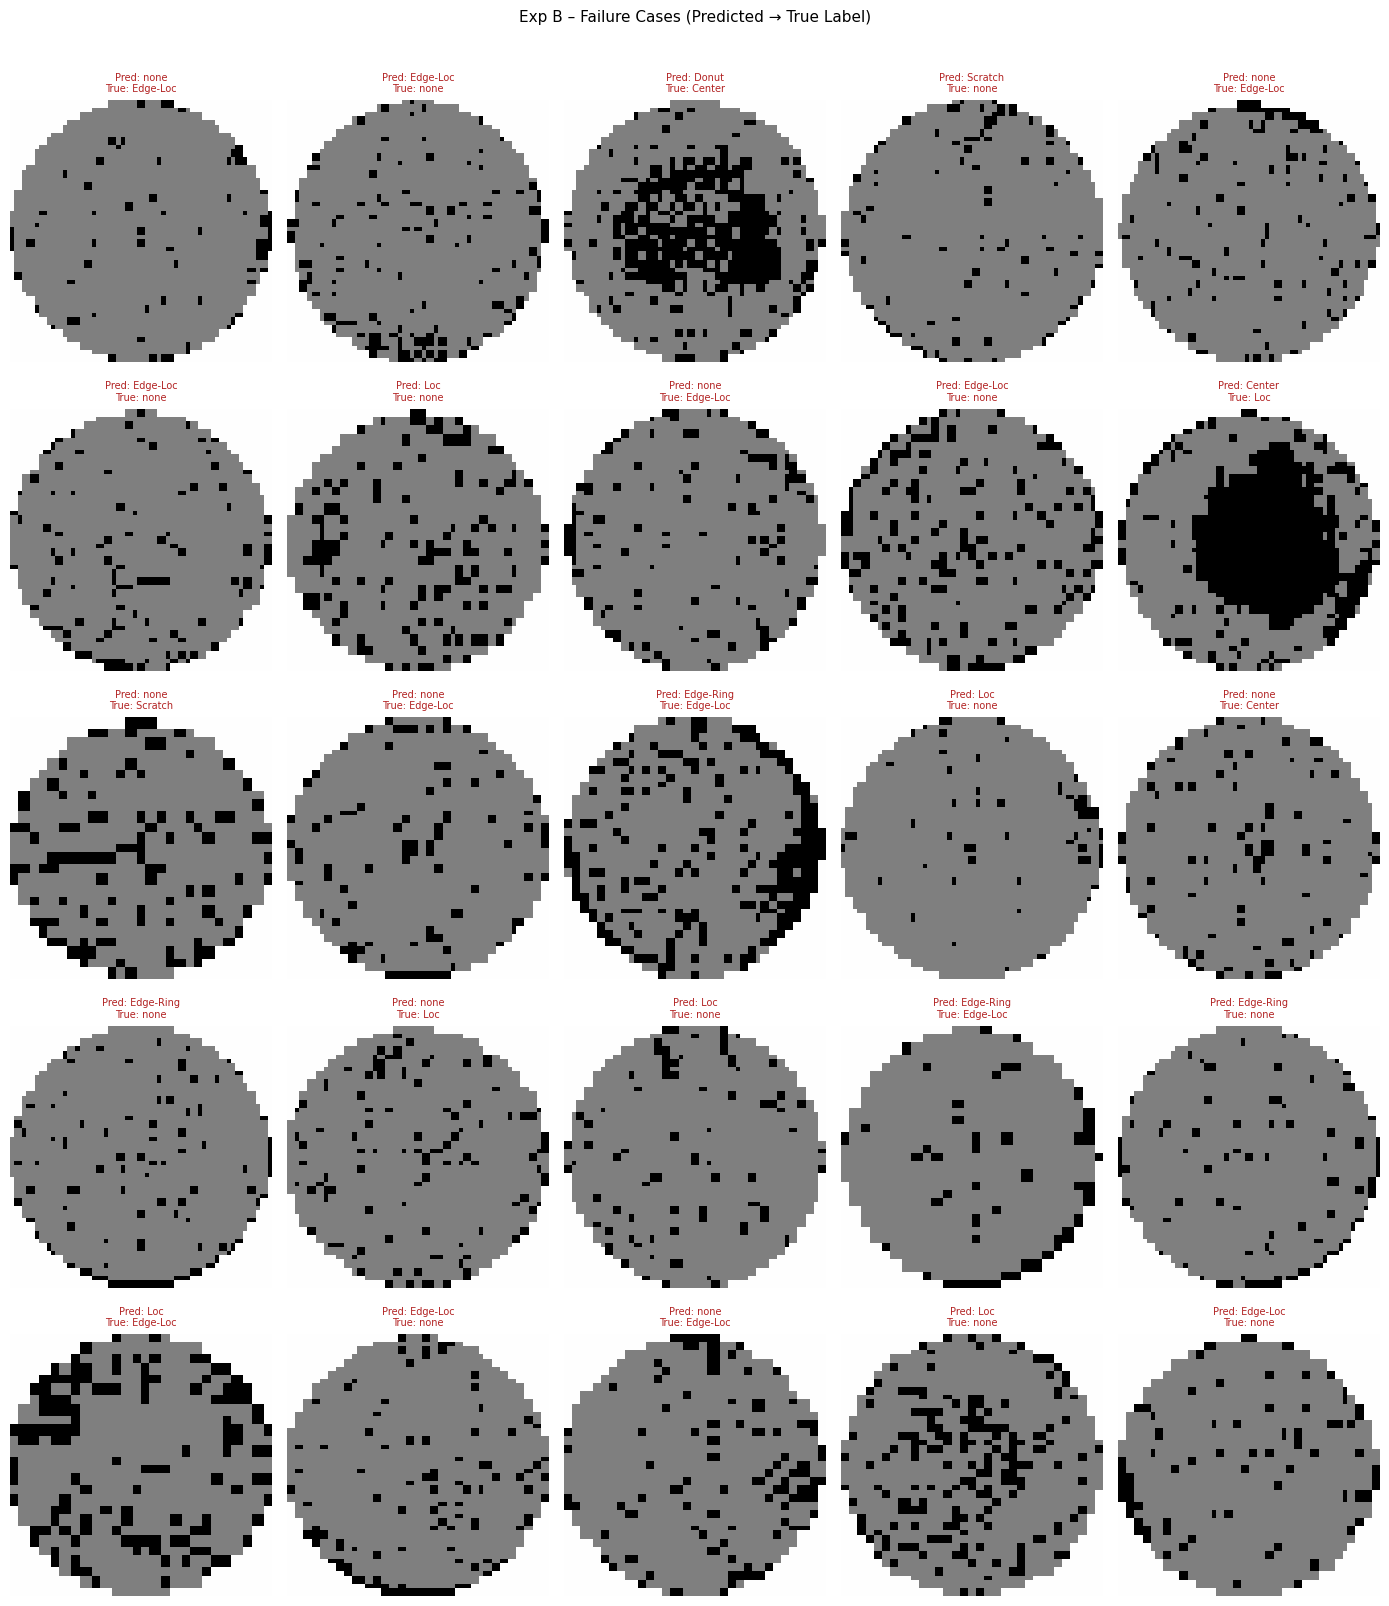

Saved → /content/drive/MyDrive/03_Wafer_Project/results2/ExpB_failure_cases.png  (25 failure cases shown)

All results saved to: /content/drive/MyDrive/03_Wafer_Project/results2
Saved Exp A/B metrics → /content/drive/MyDrive/03_Wafer_Project/results2/sec11_AB_metrics.npz


In [ ]:
### 11-5. Comparison: Exp A vs Exp B  +  Failure-Case Analysis

# ── Metric comparison table ───────────────────────────────────────────────────
metric_names = ['Accuracy', 'Macro F1\n(all 9)', 'Recall', 'Precision']
a_vals = [result_A['test_acc'], result_A['test_f1'],
          result_A['test_rec'], result_A['test_prec']]
b_vals = [result_B['test_acc'], result_B['test_f1'],
          result_B['test_rec'], result_B['test_prec']]

print("\n" + "=" * 62)
print("  TEST SET COMPARISON: Exp A vs Exp B")
print("=" * 62)
print(f"{'Metric':<24}  {'Exp A (real)':>12}  {'Exp B (+synth)':>14}  {'Δ (B−A)':>10}")
print("-" * 62)
for m, a, b in zip(metric_names, a_vals, b_vals):
    delta = b - a
    sign  = '+' if delta >= 0 else ''
    tag   = ' ← key' if 'all 9' in m else ''
    print(f"{m.replace(chr(10),' '):<24}  {a:>12.4f}  {b:>14.4f}  {sign}{delta:>9.4f}{tag}")


# ── Bar chart (5 metrics) ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(metric_names))
width = 0.35

bars_a = ax.bar(x - width / 2, a_vals, width,
                label='Exp A (Original only)', color='steelblue',  alpha=0.85)
bars_b = ax.bar(x + width / 2, b_vals, width,
                label='Exp B (+ Synthetic)',   color='darkorange', alpha=0.85)

for bars in (bars_a, bars_b):
    for bar in bars:
        ax.annotate(
            f'{bar.get_height():.4f}',
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3), textcoords='offset points',
            ha='center', va='bottom', fontsize=8,
        )

ax.set_ylabel('Score')
ax.set_title('ResNet-18 Test Metrics — Experiment A vs B\n'
             '(★ Macro F1 (all 9) = primary metric)',
             fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
# Highlight the Macro F1 (all 9) column
ax.axvspan(0.5, 1.5, alpha=0.08, color='gold', label='Key metric region')
plt.tight_layout()
cmp_path = os.path.join(RESULT_DIR, "comparison_metrics.png")
plt.savefig(cmp_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {cmp_path}")


# ── Per-class F1 comparison (heatmap) ────────────────────────────────────────
a_pcf1 = result_A['test_per_cls_f1']   # shape (9,)
b_pcf1 = result_B['test_per_cls_f1']   # shape (9,)
delta   = b_pcf1 - a_pcf1

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, vals, title, cmap in zip(
    axes,
    [a_pcf1, b_pcf1, delta],
    ['Exp A — Per-class F1', 'Exp B — Per-class F1', 'Δ F1  (B − A)'],
    ['Blues', 'Blues', 'RdYlGn'],
):
    vmin, vmax = ((-0.3, 0.3) if 'Δ' in title else (0, 1))
    im = ax.imshow(vals.reshape(-1, 1), cmap=cmap, vmin=vmin, vmax=vmax,
                   aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_yticks(range(N_CLF_CLASSES))
    ax.set_yticklabels(ALL_CLF_CLASSES, fontsize=9)
    ax.set_xticks([])
    ax.set_title(title, fontsize=10)
    for i, v in enumerate(vals):
        color = 'white' if abs(v) > (0.6 if 'Δ' not in title else 0.2) else 'black'
        ax.text(0, i, f'{v:+.3f}' if 'Δ' in title else f'{v:.3f}',
                ha='center', va='center', fontsize=8, color=color)

plt.suptitle(
    "Per-class F1 — Exp A vs B",
    fontsize=11,
)
plt.tight_layout()
pcf1_path = os.path.join(RESULT_DIR, "comparison_per_class_f1.png")
plt.savefig(pcf1_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {pcf1_path}")


# ── Confusion-matrix helper: row % = Recall, col % = Precision ─────────────────────
def save_confusion_matrix(labels, preds, class_names, title, save_path):
    cm = confusion_matrix(labels, preds, labels=list(range(len(class_names))))
    out_dir = os.path.dirname(save_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    base_path = save_path.rsplit('.', 1)[0] if '.' in save_path else save_path

    # (1) Row-normalized % = Recall 
    row_sums = np.maximum(cm.sum(axis=1, keepdims=True), 1)
    cm_pct = (cm.astype(float) / row_sums) * 100
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm_pct, interpolation='nearest', cmap='Blues', vmin=0, vmax=100)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('% of true class (Recall)', fontsize=10)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    thresh = 50.0
    for i in range(cm_pct.shape[0]):
        for j in range(cm_pct.shape[1]):
            txt = f"{cm_pct[i, j]:.1f}%"
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='white' if cm_pct[i, j] > thresh else 'black')
    ax.set_ylabel('True label', fontsize=11)
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_title(title + "  (row % = Recall)", fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved (row % = Recall) → {save_path}")

    # (2) Column-normalized % = Precision 
    col_sums = np.maximum(cm.sum(axis=0, keepdims=True), 1)
    cm_pct_col = (cm.astype(float) / col_sums) * 100
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm_pct_col, interpolation='nearest', cmap='Greens', vmin=0, vmax=100)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('% of predicted class (Precision)', fontsize=10)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    for i in range(cm_pct_col.shape[0]):
        for j in range(cm_pct_col.shape[1]):
            txt = f"{cm_pct_col[i, j]:.1f}%"
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='white' if cm_pct_col[i, j] > thresh else 'black')
    ax.set_ylabel('True label', fontsize=11)
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_title(title + "  (col % = Precision)", fontsize=12)
    plt.tight_layout()
    col_path = base_path + "_col.png"
    plt.savefig(col_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved (col % = Precision) → {col_path}")

save_confusion_matrix(
    result_A['test_labels'], result_A['test_preds'], ALL_CLF_CLASSES,
    title='Exp A – Confusion Matrix (Test)',
    save_path=os.path.join(RESULT_DIR, 'ExpA_confusion_matrix.png'),
)
save_confusion_matrix(
    result_B['test_labels'], result_B['test_preds'], ALL_CLF_CLASSES,
    title='Exp B – Confusion Matrix (Test)',
    save_path=os.path.join(RESULT_DIR, 'ExpB_confusion_matrix.png'),
)


# ── Failure-case visualisation ────────────────────────────────────────────────
@torch.no_grad()
def plot_failure_cases(model, loader, title, save_path, max_cases=25):
    """Display samples where the model predicted incorrectly.

    Re-runs the test loader to collect failure images without storing the
    entire test set in memory.  Shows 'Pred: X / True: Y' on each tile.
    """
    model.eval()
    failures = []         # list of (img_np H×W, pred_idx, true_idx)

    for imgs, lbls in loader:
        imgs_d = imgs.to(device)
        preds  = model(imgs_d).argmax(1).cpu()
        mask   = (preds != lbls)
        for j in range(len(lbls)):
            if mask[j]:
                failures.append((
                    imgs[j, 0].numpy(),   # (H, W) float32 in [0, 1]
                    preds[j].item(),
                    lbls[j].item(),
                ))
            if len(failures) >= max_cases:
                break
        if len(failures) >= max_cases:
            break

    n = len(failures)
    if n == 0:
        print(f"[{title}] No failure cases — perfect test accuracy!")
        return

    cols      = min(5, n)
    rows      = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                              figsize=(cols * 2.8, rows * 3.2))
    axes_flat = np.array(axes).flatten() if n > 1 else [axes]

    for i, (img, pred_idx, true_idx) in enumerate(failures):
        ax = axes_flat[i]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(
            f'Pred: {CLS_IDX2LABEL[pred_idx]}\nTrue: {CLS_IDX2LABEL[true_idx]}',
            fontsize=7, color='firebrick',
        )
        ax.axis('off')

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved → {save_path}  ({n} failure cases shown)")


plot_failure_cases(
    result_A['model'], test_loader_clf,
    title='Exp A – Failure Cases (Predicted → True Label)',
    save_path=os.path.join(RESULT_DIR, 'ExpA_failure_cases.png'),
)

plot_failure_cases(
    result_B['model'], test_loader_clf,
    title='Exp B – Failure Cases (Predicted → True Label)',
    save_path=os.path.join(RESULT_DIR, 'ExpB_failure_cases.png'),
)

print("\nAll results saved to:", RESULT_DIR)


# ── Save Exp A / B metrics for cross-session 4-way comparison (Section 12-5) ─
# Cell 41 (12-5) loads this file when result_A / result_B are not in session memory.
_AB_METRICS_PATH = os.path.join(RESULT_DIR, "sec11_AB_metrics.npz")
np.savez(
    _AB_METRICS_PATH,
    a_test_acc=result_A['test_acc'],   a_test_f1=result_A['test_f1'],
    a_test_rec=result_A['test_rec'],   a_test_prec=result_A['test_prec'],
    a_per_cls_f1=result_A['test_per_cls_f1'],
    a_labels=result_A['test_labels'],  a_preds=result_A['test_preds'],
    b_test_acc=result_B['test_acc'],   b_test_f1=result_B['test_f1'],
    b_test_rec=result_B['test_rec'],   b_test_prec=result_B['test_prec'],
    b_per_cls_f1=result_B['test_per_cls_f1'],
    b_labels=result_B['test_labels'],  b_preds=result_B['test_preds'],
)
print(f"Saved Exp A/B metrics → {_AB_METRICS_PATH}")

## 12. Downstream Classification: Pretrained ViT-Small/16-224 Fine-tuning

Fine-tunes **timm pretrained ViT-Small/16-224** following the same protocol as Section 11 for direct comparison.

### Model Design

| Item | Value |
|---|---|
| Input | 1ch grayscale → replicated to 3ch, 224×224 bilinear resize + ImageNet normalisation |
| Patch size | 16×16 → **196 patch tokens** + 1 CLS = 197 |
| Embed dim | 384 |
| Depth | 12 blocks |
| Heads | 6 |
| MLP ratio | 4.0 |
| **Parameters** | **~22 M** (~2× larger than WaferResNet18 ~11 M) |
| Pre-training | ImageNet-21k → ImageNet-1k (timm `vit_small_patch16_224`) |

### Experiment Design

| | Training Data | Notes |
|---|---|---|
| **Experiment C** | Real training data only | Same data as Exp A (Section 11), model changed to ViT |
| **Experiment D** | Real + Synthetic (failure classes up to 8,000 images; **synthetic cap: real count × 3**) | Same data as Exp B (Section 11), model changed to ViT |

Results include a **C vs D** comparison and a **4-way summary (A / B / C / D)**.

In [ ]:
### 12-0. Section 12 Prerequisites

from sklearn.metrics import (
    f1_score, recall_score, precision_score, accuracy_score, confusion_matrix,
)
import torchvision.models as tv_models

# ── Path configuration ────────────────────────────────────────────────────────
RESULT_DIR      = "/content/drive/MyDrive/03_Wafer_Project/results"
SYN_DATA_PATH   = "/content/drive/MyDrive/03_Wafer_Project/data/synthetic_data.npy"
SYN_LABELS_PATH = "/content/drive/MyDrive/03_Wafer_Project/data/synthetic_labels.npy"
os.makedirs(RESULT_DIR, exist_ok=True)

# ── Classification hyperparameters ────────────────────────────────────────────
CLF_BATCH_SIZE   = 128
CLF_WEIGHT_DECAY = 1e-4

# ── Label mapping (reuse same indices as the diffusion model definition) ──────
ALL_CLF_CLASSES = FAILURE_CLASSES       # ['Center',...,'Scratch','none'], len=9
N_CLF_CLASSES   = N_CLASSES             # 9
CLS_LABEL2IDX   = FAIL_LABEL2IDX        # {'Center':0, ..., 'none':8}
CLS_IDX2LABEL   = FAIL_IDX2LABEL        # {0:'Center', ..., 8:'none'}
CLF_AUG_CLASSES = [c for c in FAILURE_CLASSES if c != 'none']  # 8 failure types

# ── ResNet-18 backbone (for parameter count comparison) ───────────────────────
class WaferResNet18(nn.Module):
    def __init__(self, num_classes=N_CLF_CLASSES):
        super().__init__()
        bb = tv_models.resnet18(weights=None)
        bb.conv1   = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        bb.maxpool = nn.Identity()
        bb.fc      = nn.Linear(512, num_classes)
        self.backbone = bb
    def forward(self, x):
        return self.backbone(x)

# ── Preprocessing helpers ─────────────────────────────────────────────────────
def _real_to_tensor(arr):
    """(1,H,W) float32 {0,1,2} → (1,H,W) float32 ≈{0, 0.498, 0.996}"""
    img_u8 = (arr.squeeze() * 127).clip(0, 255).astype(np.uint8)
    return torch.from_numpy(img_u8.astype(np.float32) / 255.0).unsqueeze(0)

def _maybe_augment(img_np, do_aug):
    if not do_aug:
        return img_np
    img_np = img_np.copy()
    if np.random.random() < 0.5:
        img_np = np.flip(img_np, axis=2).copy()
    if np.random.random() < 0.5:
        img_np = np.flip(img_np, axis=1).copy()
    k = np.random.randint(0, 4)
    if k:
        img_np = np.rot90(img_np, k=k, axes=(1, 2)).copy()
    return img_np

# ── Dataset classes ───────────────────────────────────────────────────────────
class WaferClfDataset(Dataset):
    def __init__(self, data, labels, label2idx, aug_classes=None):
        self.data       = data
        self.int_labels = np.array([label2idx[l] for l in labels], dtype=np.int64)
        aug_set         = set(aug_classes) if aug_classes else set()
        self.do_aug     = np.array([l in aug_set for l in labels], dtype=bool)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img = _maybe_augment(self.data[idx], bool(self.do_aug[idx]))
        return _real_to_tensor(img), int(self.int_labels[idx])

class WaferClfDatasetMixed(Dataset):
    def __init__(self, data, labels, label2idx, is_syn_mask, aug_classes=None):
        self.data       = data
        self.int_labels = np.array([label2idx[l] for l in labels], dtype=np.int64)
        self.is_syn     = is_syn_mask
        aug_set         = set(aug_classes) if aug_classes else set()
        self.do_aug     = np.array([l in aug_set for l in labels], dtype=bool)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img   = _maybe_augment(self.data[idx], bool(self.do_aug[idx]))
        img_t = torch.from_numpy(img.copy().astype(np.float32)) if self.is_syn[idx] \
                else _real_to_tensor(img)
        return img_t, int(self.int_labels[idx])

# ── Training utilities ────────────────────────────────────────────────────────
def make_class_weights(labels, label2idx, n_classes, device):
    idxs   = np.array([label2idx[l] for l in labels])
    counts = np.bincount(idxs, minlength=n_classes).astype(float)
    w      = 1.0 / np.maximum(counts, 1.0)
    w      = w / w.sum() * n_classes
    return torch.tensor(w, dtype=torch.float32, device=device)

def train_epoch_clf(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += out.argmax(1).eq(lbls).sum().item()
        total      += lbls.size(0)
    return total_loss / len(loader), correct / total

@torch.no_grad()
def eval_epoch_clf(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for imgs, lbls in loader:
        imgs, lbls  = imgs.to(device), lbls.to(device)
        out          = model(imgs)
        total_loss  += criterion(out, lbls).item()
        all_preds.extend(out.argmax(1).cpu().tolist())
        all_labels.extend(lbls.cpu().tolist())
    p, l = np.array(all_preds), np.array(all_labels)
    return (
        total_loss / len(loader),
        accuracy_score(l, p),
        f1_score(l, p, average='macro', zero_division=0),
        recall_score(l, p, average='macro', zero_division=0),
        precision_score(l, p, average='macro', zero_division=0),
        l, p,
    )

def save_training_plot(train_losses, val_losses, val_f1s, val_accs,
                       title, save_path, best_epoch=None):
    ep = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(ep, train_losses, label='Train Loss')
    axes[0].plot(ep, val_losses,   label='Val Loss')
    if best_epoch:
        axes[0].axvline(best_epoch, color='red', ls='--',
                        label=f'Best epoch {best_epoch}')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(ep, val_f1s, color='green', label='Val Macro-F1')
    if best_epoch:
        axes[1].axvline(best_epoch, color='red', ls='--')
        axes[1].axhline(val_f1s[best_epoch - 1], color='red', ls=':',
                        label=f'F1 = {val_f1s[best_epoch - 1]:.4f}')
    axes[1].set_title('Val Macro F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    axes[2].plot(ep, val_accs, color='purple', label='Val Accuracy')
    if best_epoch:
        axes[2].axvline(best_epoch, color='red', ls='--')
    axes[2].set_title('Val Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend()
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    out_dir = os.path.dirname(save_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"  Saved → {save_path}")

# ── Val / Test DataLoader (no augmentation) ──────────────────────────────────
val_ds_clf  = WaferClfDataset(val_data,  val_labels,  CLS_LABEL2IDX)
test_ds_clf = WaferClfDataset(test_data, test_labels, CLS_LABEL2IDX)
val_loader_clf  = DataLoader(val_ds_clf,  batch_size=CLF_BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
test_loader_clf = DataLoader(test_ds_clf, batch_size=CLF_BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

# ── Load Synthetic data ─────────────────────────────────────────────────────
syn_data_B   = np.load(SYN_DATA_PATH)
syn_labels_B = np.load(SYN_LABELS_PATH)

# ── Status check ─────────────────────────────────────────────────────────────────
print(f"Val  set : {len(val_ds_clf):,} samples")
print(f"Test set : {len(test_ds_clf):,} samples")
print(f"Synthetic: {len(syn_data_B):,} images  shape={syn_data_B.shape}")
print(f"Aug classes ({len(CLF_AUG_CLASSES)}): {CLF_AUG_CLASSES}")
print("\n✓ 12-0 완료 — 12-1 부터 순서대로 실행하세요.")

Val  set : 34,590 samples
Test set : 34,590 samples
Synthetic: 48,689 images  shape=(48689, 1, 64, 64)
Aug classes (8): ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']

✓ 12-0 완료 — 12-1 부터 순서대로 실행하세요.


In [ ]:
### 12-1. Pretrained ViT-Small/16-224  (timm fine-tuning)

!pip install -q timm
import timm

VIT_IMG_SIZE = 224    # expected input size for vit_small_patch16_224

_VIT_MEAN = [0.485, 0.456, 0.406]
_VIT_STD  = [0.229, 0.224, 0.225]


def _to_vit_tensor_real(arr):
    """Real wafer map: (1,H,W) {0,1,2} → 3ch 224×224 ImageNet-normalised tensor.

    {0,1,2} → ×127 → {0, 127, 254}  (kept as 3-level uint8 to preserve discreteness)
    PIL BILINEAR resize → smoothly preserves die boundaries (circular edge, Scratch lines).
    """
    img_u8  = (arr.squeeze() * 127).clip(0, 255).astype(np.uint8)
    pil_img = Image.fromarray(img_u8).resize(
                  (VIT_IMG_SIZE, VIT_IMG_SIZE), Image.BILINEAR)
    t = TF.to_tensor(pil_img)           # (1, 224, 224) float32 in [0, 1]
    t = t.repeat(3, 1, 1)              # (3, 224, 224)
    return TF.normalize(t, _VIT_MEAN, _VIT_STD)


def _to_vit_tensor_syn(arr):
    """Synthetic wafer map: (1,H,W) [0,1] → 3ch 224×224 ImageNet-normalised tensor."""
    img_u8  = (arr.squeeze().clip(0, 1) * 255).astype(np.uint8)
    pil_img = Image.fromarray(img_u8).resize(
                  (VIT_IMG_SIZE, VIT_IMG_SIZE), Image.BILINEAR)
    t = TF.to_tensor(pil_img)           # (1, 224, 224)
    t = t.repeat(3, 1, 1)
    return TF.normalize(t, _VIT_MEAN, _VIT_STD)


# ── ViT-specific Dataset classes ─────────────────────────────────────────────
class WaferClfDatasetViT(Dataset):
    """ViT variant of WaferClfDataset — outputs 224×224 3ch ImageNet-normalized tensors."""

    def __init__(self, data, labels, label2idx, aug_classes=None):
        self.data       = data
        self.int_labels = np.array([label2idx[l] for l in labels], dtype=np.int64)
        aug_set         = set(aug_classes) if aug_classes else set()
        self.do_aug     = np.array([l in aug_set for l in labels], dtype=bool)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = _maybe_augment(self.data[idx], bool(self.do_aug[idx]))
        return _to_vit_tensor_real(img), int(self.int_labels[idx])


class WaferClfDatasetMixedViT(Dataset):
    """ViT variant of WaferClfDatasetMixed — applies separate preprocessing for real/synthetic, outputs 224×224 3ch."""

    def __init__(self, data, labels, label2idx, is_syn_mask, aug_classes=None):
        self.data       = data
        self.int_labels = np.array([label2idx[l] for l in labels], dtype=np.int64)
        self.is_syn     = is_syn_mask
        aug_set         = set(aug_classes) if aug_classes else set()
        self.do_aug     = np.array([l in aug_set for l in labels], dtype=bool)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img   = _maybe_augment(self.data[idx], bool(self.do_aug[idx]))
        img_t = _to_vit_tensor_syn(img) if self.is_syn[idx] \
                else _to_vit_tensor_real(img)
        return img_t, int(self.int_labels[idx])


# ── Pretrained ViT-Small/16-224 model factory ────────────────────────────────
def build_wafer_vit(num_classes=N_CLF_CLASSES, pretrained=True):
    """Load pretrained ViT-Small/16-224 via timm and replace the classification head.

    · patch_size=16, img_size=224 → 196 patch tokens + 1 CLS = 197 total
    · in_chans=3 (matched by grayscale → 3ch replication in preprocessing)
    · head: nn.Linear(384, num_classes)  ← ViT-Small embed_dim=384, randomly initialised
    """
    model = timm.create_model(
        'vit_small_patch16_224',
        pretrained=pretrained,
        num_classes=num_classes,
    )
    return model


# ── Parameter count check ────────────────────────────────────────────────────
_dummy = build_wafer_vit(pretrained=False)
vit_params    = sum(p.numel() for p in _dummy.parameters())
resnet_params = sum(p.numel() for p in WaferResNet18().parameters())
print(f"ViT-Small/16-224 (pretrained fine-tune): {vit_params:>10,} params")
print(f"WaferResNet18                           : {resnet_params:>10,} params  (reference)")
del _dummy

ViT-Small/16-224 (pretrained fine-tune): 21,669,129 params
WaferResNet18                           : 11,172,297 params  (reference)


In [ ]:
### 12-2. ViT Training Setup & run_experiment_vit

# ── ViT fine-tuning hyperparameters ──────────────────────────────────────────
# ViT-Small ~22M params → 224×224 input → embed_dim 384
#   · lr=1e-4  weight_decay=0.05  warmup 5 epochs
VIT_EPOCHS       = 30
VIT_LR           = 1e-4
VIT_BATCH_SIZE   = 128  # based on ViT-Small 224×224
VIT_WEIGHT_DECAY = 0.05
VIT_WARMUP       = 5


def get_vit_scheduler(optimizer, warmup_epochs, total_epochs):
    """Linear warmup → Cosine annealing (standard timm fine-tuning schedule).

    Adding +1 to both numerator and denominator of progress ensures cosine decay
    starts immediately after warmup (at last_epoch=warmup_epochs). The original
    formula had an off-by-one issue where progress=0 produced an extra flat LR=1.0 epoch.
    """
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs + 1) / max(1, total_epochs - warmup_epochs + 1)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# ── Val / Test ViT DataLoader ─────────────────────────────────────────────────
# Created separately from the ResNet loaders (val_loader_clf, test_loader_clf):
# ViT requires 224×224 3ch input, so a dedicated Dataset is used.
val_ds_vit  = WaferClfDatasetViT(val_data,  val_labels,  CLS_LABEL2IDX)
test_ds_vit = WaferClfDatasetViT(test_data, test_labels, CLS_LABEL2IDX)
val_loader_vit  = DataLoader(val_ds_vit,  batch_size=VIT_BATCH_SIZE,
                              shuffle=False, num_workers=4, pin_memory=True,
                              persistent_workers=True)
test_loader_vit = DataLoader(test_ds_vit, batch_size=VIT_BATCH_SIZE,
                              shuffle=False, num_workers=4, pin_memory=True,
                              persistent_workers=True)


def run_experiment_vit(exp_name, train_ds, val_loader, test_loader,
                       train_labels_all, epochs=VIT_EPOCHS, lr=VIT_LR):
    """Fine-tune pretrained ViT-Small/16-224.

    · build_wafer_vit()  → pretrained weights, classification head replaced
    · AdamW + warmup+cosine LR schedule
    · class-weighted CrossEntropy (same evaluation protocol as ResNet experiments)
    · best epoch = epoch with highest val Macro F1 (all 9 classes)
    """
    # Ensure identical starting point across experiments (head weight init, DataLoader shuffle reproducibility)
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    train_loader = DataLoader(train_ds, batch_size=VIT_BATCH_SIZE,
                              shuffle=True, num_workers=4, pin_memory=True,
                              persistent_workers=True, drop_last=False)

    class_w   = make_class_weights(train_labels_all, CLS_LABEL2IDX,
                                   N_CLF_CLASSES, device)
    model     = build_wafer_vit(num_classes=N_CLF_CLASSES, pretrained=True).to(device)
    crit_w    = nn.CrossEntropyLoss(weight=class_w)
    crit_uw   = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr,
                            weight_decay=VIT_WEIGHT_DECAY)
    scheduler = get_vit_scheduler(optimizer, VIT_WARMUP, epochs)

    train_losses, val_losses, val_f1s, val_accs = [], [], [], []
    best_f1, best_epoch, best_state = -1.0, 1, None

    print(f"\n{'='*64}")
    print(f"  {exp_name}  |  {len(train_ds):,} train  |  {epochs} epochs")
    print(f"  model=ViT-Small/16-224(pretrained)  LR={lr}  WD={VIT_WEIGHT_DECAY}"
          f"  warmup={VIT_WARMUP}ep")
    print(f"{'='*64}")

    epoch_bar = tqdm(range(1, epochs + 1), total=epochs,
                     desc=f"  {exp_name}", unit="ep",
                     bar_format="{l_bar}{bar:28}{r_bar}")

    for epoch in epoch_bar:
        tr_loss, tr_acc = train_epoch_clf(model, train_loader,
                                          optimizer, crit_w, device)
        vl_loss, vl_acc, vl_f1, vl_rec, vl_prec, _, _ = eval_epoch_clf(
            model, val_loader, crit_uw, device)
        scheduler.step()

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        val_f1s.append(vl_f1)
        val_accs.append(vl_acc)

        if vl_f1 > best_f1:
            best_f1    = vl_f1
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        epoch_bar.set_postfix(ordered_dict={
            "tr_loss": f"{tr_loss:.3f}",
            "vF1":     f"{vl_f1:.4f}",
            "best":    f"E{best_epoch:02d}({'★' if epoch == best_epoch else ' '})",
        })

    print(f"\n  ✓ Best epoch: E{best_epoch:02d}  "
          f"(val Macro-F1 all-9 = {best_f1:.4f})")

    save_training_plot(
        train_losses, val_losses, val_f1s, val_accs,
        title=f"{exp_name} – Training Curves  [ViT-Small/16-224 fine-tune]",
        save_path=os.path.join(RESULT_DIR,
                               f"{exp_name.replace(' ', '_')}_training.png"),
        best_epoch=best_epoch,
    )

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    _, ts_acc, ts_f1, ts_rec, ts_prec, ts_labels, ts_preds = eval_epoch_clf(
        model, test_loader, crit_uw, device)

    ts_per_cls_f1 = f1_score(ts_labels, ts_preds,
                              labels=list(range(N_CLF_CLASSES)),
                              average=None, zero_division=0)

    print(f"\n  ── TEST RESULTS ─────────────────────────────────────")
    print(f"  Accuracy         : {ts_acc:.4f}")
    print(f"  Macro F1 (all 9) : {ts_f1:.4f}  ← key metric")
    print(f"  Recall           : {ts_rec:.4f}")
    print(f"  Precision        : {ts_prec:.4f}")
    print(f"\n  Per-class F1:")
    for i, cls in enumerate(ALL_CLF_CLASSES):
        marker = "  " if cls == 'none' else "▶ "
        print(f"    {marker}{cls:12s}: {ts_per_cls_f1[i]:.4f}")

    return dict(
        name=exp_name, model=model, best_epoch=best_epoch,
        train_losses=train_losses, val_losses=val_losses,
        val_f1s=val_f1s, val_accs=val_accs,
        test_acc=ts_acc, test_f1=ts_f1,
        test_rec=ts_rec, test_prec=ts_prec,
        test_per_cls_f1=ts_per_cls_f1,
        test_labels=ts_labels, test_preds=ts_preds,
    )


print(f"val_loader_vit  : {len(val_ds_vit):,} samples  (224×224, 3ch)")
print(f"test_loader_vit : {len(test_ds_vit):,} samples  (224×224, 3ch)")
print("ViT experiment utilities defined.")

val_loader_vit  : 34,590 samples  (224×224, 3ch)
test_loader_vit : 34,590 samples  (224×224, 3ch)
ViT experiment utilities defined.


In [ ]:
### 12-3. Experiment C — ViT-Small fine-tune, Original Training Data Only

import gc
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

try:
    train_data_capped
    train_labels_capped
except NameError:
    train_data_capped   = train_data
    train_labels_capped = train_labels

# val_loader_vit, test_loader_vit : 224×224 3ch 
print("\nTrain class distribution (Exp C — same data as Exp A, none capped at 15,000):")
for cls in ALL_CLF_CLASSES:
    cnt = (train_labels_capped == cls).sum()
    tag = "  ← aug (flip+rot90)" if cls != 'none' else ""
    print(f"  {cls:12s}: {cnt:6d}{tag}")

train_ds_C = WaferClfDatasetViT(train_data_capped, train_labels_capped, CLS_LABEL2IDX,
                                 aug_classes=CLF_AUG_CLASSES)


Train class distribution (Exp C — same data as Exp A, none capped at 15,000):
  Center      :   2576  ← aug (flip+rot90)
  Donut       :    333  ← aug (flip+rot90)
  Edge-Loc    :   3113  ← aug (flip+rot90)
  Edge-Ring   :   5808  ← aug (flip+rot90)
  Loc         :   2156  ← aug (flip+rot90)
  Near-full   :     89  ← aug (flip+rot90)
  Random      :    520  ← aug (flip+rot90)
  Scratch     :    716  ← aug (flip+rot90)
  none        :  88459



  Exp_C  |  103,770 train  |  30 epochs
  model=ViT-Small/16-224(pretrained)  LR=0.0001  WD=0.05  warmup=5ep


  Exp_C: 100%|████████████████████████████| 30/30 [1:50:18<00:00, 220.61s/ep, tr_loss=0.024, vF1=0.8849, best=E25( )]



  ✓ Best epoch: E25  (val Macro-F1 all-9 = 0.8856)


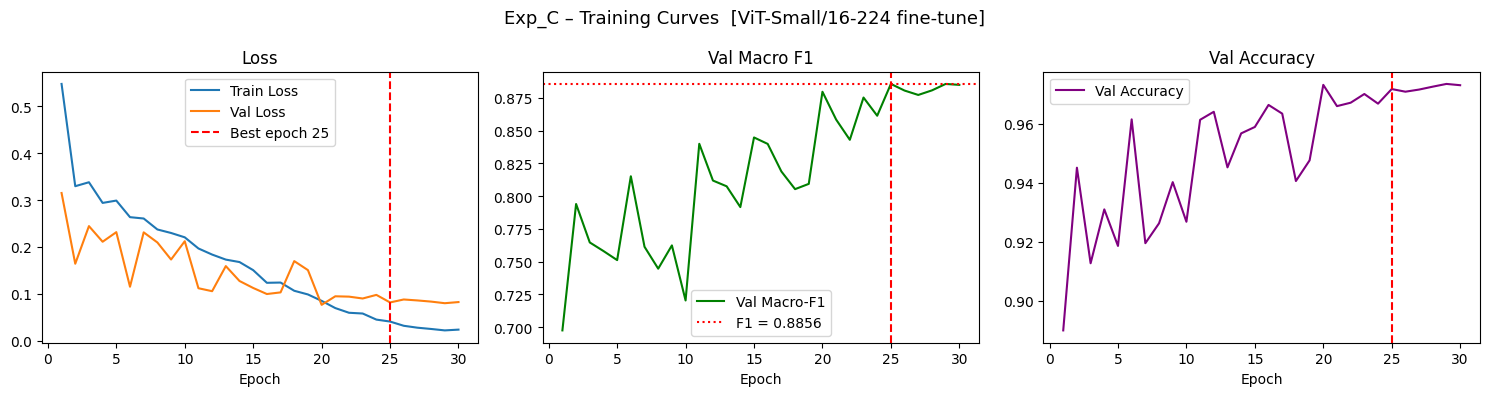

  Saved → /content/drive/MyDrive/03_Wafer_Project/results/Exp_C_training.png

  ── TEST RESULTS ─────────────────────────────────────
  Accuracy         : 0.9706
  Macro F1 (all 9) : 0.8717  ← key metric
  Recall           : 0.9170
  Precision        : 0.8342

  Per-class F1:
    ▶ Center      : 0.9195
    ▶ Donut       : 0.8288
    ▶ Edge-Loc    : 0.8339
    ▶ Edge-Ring   : 0.9844
    ▶ Loc         : 0.7376
    ▶ Near-full   : 0.9524
    ▶ Random      : 0.8698
    ▶ Scratch     : 0.7329
      none        : 0.9865


In [ ]:
result_C = run_experiment_vit(
    exp_name         = "Exp_C",
    train_ds         = train_ds_C,
    val_loader       = val_loader_vit,
    test_loader      = test_loader_vit,
    train_labels_all = train_labels_capped,
)

Synthetic 상한: real × 3 (Exp B와 동일 규칙)

Combined training size: 127,091

Combined class distribution (real + synthetic):
  Center      :   8000  (5,424 syn, aug)
  Donut       :   1332  (999 syn, aug)
  Edge-Loc    :   8000  (4,887 syn, aug)
  Edge-Ring   :   8000  (2,192 syn, aug)
  Loc         :   8000  (5,844 syn, aug)
  Near-full   :    356  (267 syn, aug)
  Random      :   2080  (1,560 syn, aug)
  Scratch     :   2864  (2,148 syn, aug)
  none        :  88459


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]


  Exp_D  |  127,091 train  |  30 epochs
  model=ViT-Small/16-224(pretrained)  LR=0.0001  WD=0.05  warmup=5ep


  Exp_D: 100%|████████████████████████████| 30/30 [2:12:40<00:00, 265.34s/ep, tr_loss=0.007, vF1=0.8976, best=E30(★)]



  ✓ Best epoch: E30  (val Macro-F1 all-9 = 0.8976)


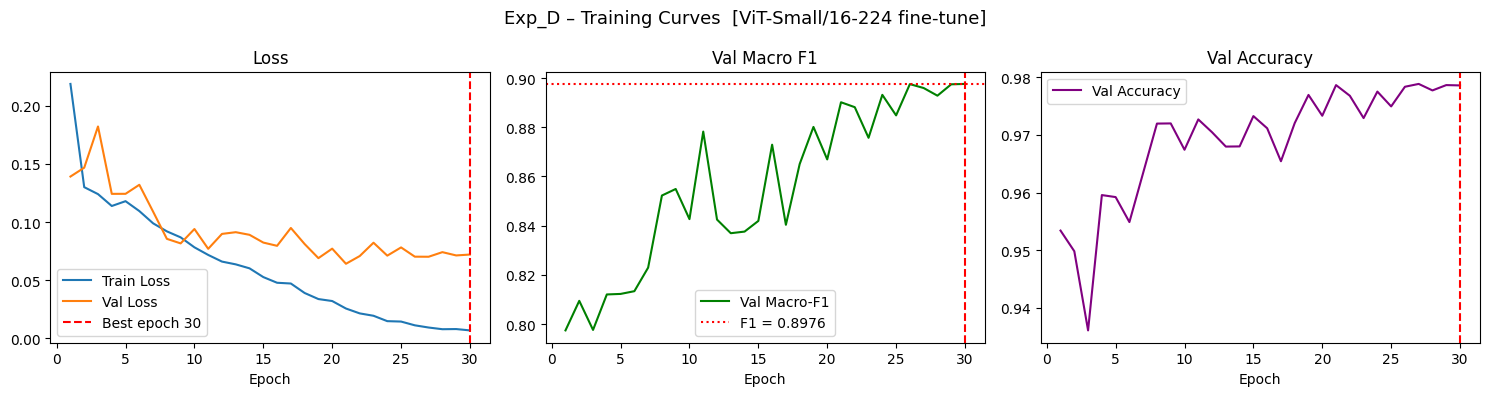

  Saved → /content/drive/MyDrive/03_Wafer_Project/results/Exp_D_training.png

  ── TEST RESULTS ─────────────────────────────────────
  Accuracy         : 0.9798
  Macro F1 (all 9) : 0.9022  ← key metric
  Recall           : 0.9174
  Precision        : 0.8883

  Per-class F1:
    ▶ Center      : 0.9401
    ▶ Donut       : 0.8945
    ▶ Edge-Loc    : 0.8734
    ▶ Edge-Ring   : 0.9851
    ▶ Loc         : 0.7973
    ▶ Near-full   : 0.9524
    ▶ Random      : 0.8895
    ▶ Scratch     : 0.7958
      none        : 0.9914


In [ ]:
### 12-4. Experiment D — ViT-Small fine-tune, Original + Synthetic Training Data

gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

try:
    _ = syn_data_B
except NameError:
    try:
        _ = SYN_DATA_PATH
    except NameError:
        SYN_DATA_PATH   = "/content/drive/MyDrive/03_Wafer_Project/data/synthetic_data.npy"
        SYN_LABELS_PATH = "/content/drive/MyDrive/03_Wafer_Project/data/synthetic_labels.npy"
    syn_data_B   = np.load(SYN_DATA_PATH)
    syn_labels_B = np.load(SYN_LABELS_PATH)
    print(f"Re-loaded {len(syn_data_B):,} synthetic images.")

# ── Combine real + synthetic data (same cap rule as Exp B: synthetic cap = real × 3) ─
try:
    train_data_capped
    train_labels_capped
except NameError:
    train_data_capped   = train_data
    train_labels_capped = train_labels

# Apply the same cap rule as Exp B (SYN_CAP_MULTIPLIER=3, fixed SEED)
try:
    _multiplier = SYN_CAP_MULTIPLIER
except NameError:
    _multiplier = 3

rng_syn_D = np.random.default_rng(SEED)
selected_syn_idx_D = []
for cls in FAILURE_CLASSES:
    if cls == 'none':
        continue
    real_count = int((train_labels_capped == cls).sum())
    syn_cap    = real_count * _multiplier
    cls_idx    = np.where(syn_labels_B == cls)[0]
    n_use      = min(len(cls_idx), syn_cap)
    if n_use > 0:
        chosen = rng_syn_D.choice(cls_idx, size=n_use, replace=False)
        selected_syn_idx_D.append(chosen)

selected_syn_idx_D = np.concatenate(selected_syn_idx_D) if selected_syn_idx_D else np.array([], dtype=int)
combined_data_D   = np.concatenate([train_data_capped,   syn_data_B[selected_syn_idx_D]],   axis=0)
combined_labels_D = np.concatenate([train_labels_capped, syn_labels_B[selected_syn_idx_D]], axis=0)

is_syn_mask_D = np.zeros(len(combined_labels_D), dtype=bool)
is_syn_mask_D[len(train_data_capped):] = True

print(f"Synthetic 상한: real × {_multiplier} (Exp B와 동일 규칙)")

# WaferClfDatasetMixedViT: 실제 → _to_vit_tensor_real, 합성 → _to_vit_tensor_syn
train_ds_D     = WaferClfDatasetMixedViT(combined_data_D, combined_labels_D,
                                          CLS_LABEL2IDX, is_syn_mask_D,
                                          aug_classes=CLF_AUG_CLASSES)
train_labels_D = combined_labels_D

print(f"\nCombined training size: {len(train_ds_D):,}")
print("\nCombined class distribution (real + synthetic):")
for cls in ALL_CLF_CLASSES:
    cnt   = (combined_labels_D == cls).sum()
    s_cnt = (combined_labels_D[is_syn_mask_D] == cls).sum()
    tag   = f"  ({s_cnt:,} syn, aug)" if s_cnt > 0 else \
            ("  ← aug" if cls != 'none' else "")
    print(f"  {cls:12s}: {cnt:6d}{tag}")

result_D = run_experiment_vit(
    exp_name         = "Exp_D",
    train_ds         = train_ds_D,
    val_loader       = val_loader_vit,
    test_loader      = test_loader_vit,
    train_labels_all = train_labels_D,
)

✓ result_A / result_B: 현 세션 메모리에서 로드


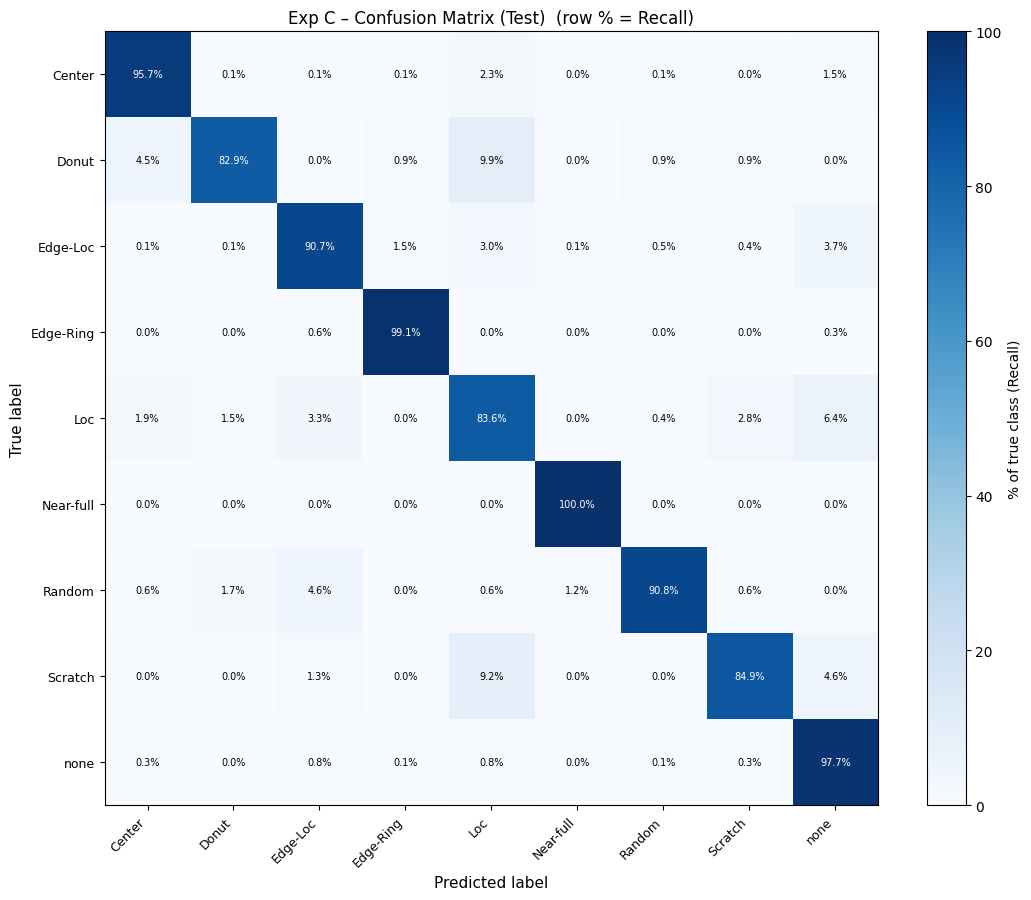

Saved (row % = Recall) → /content/drive/MyDrive/03_Wafer_Project/results/ExpC_confusion_matrix.png


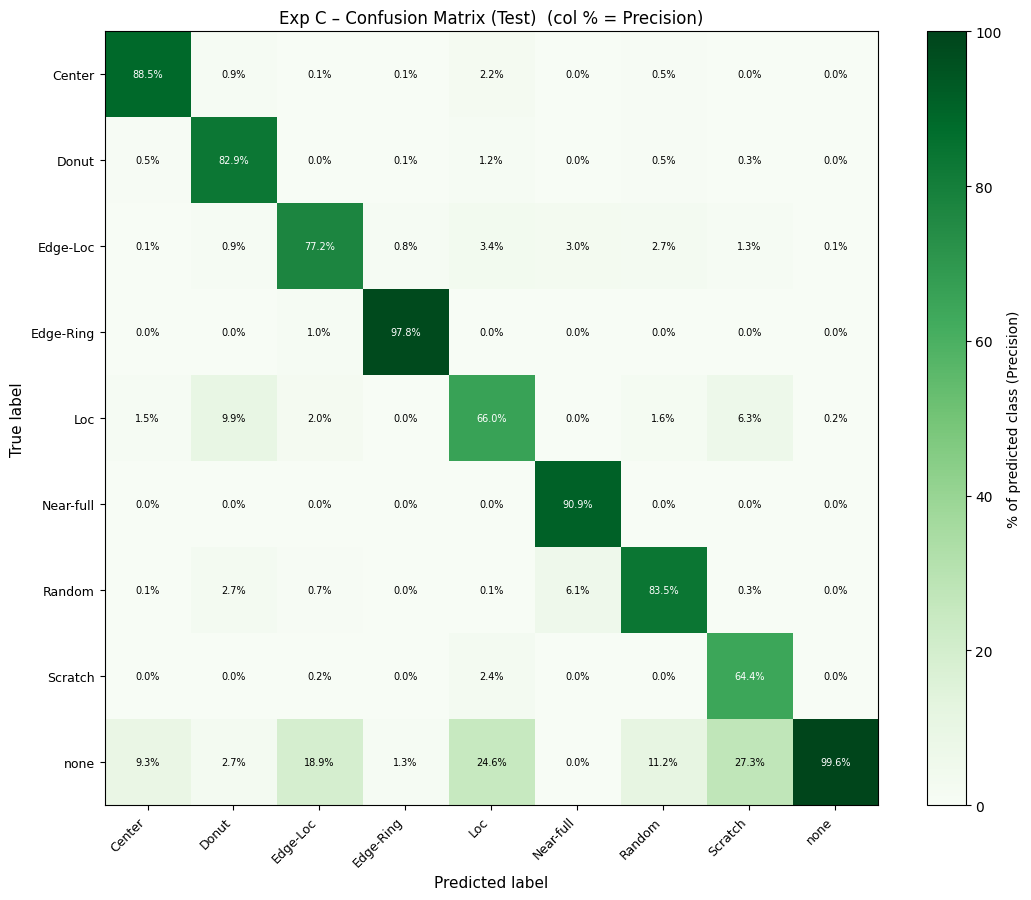

Saved (col % = Precision) → /content/drive/MyDrive/03_Wafer_Project/results/ExpC_confusion_matrix_col.png


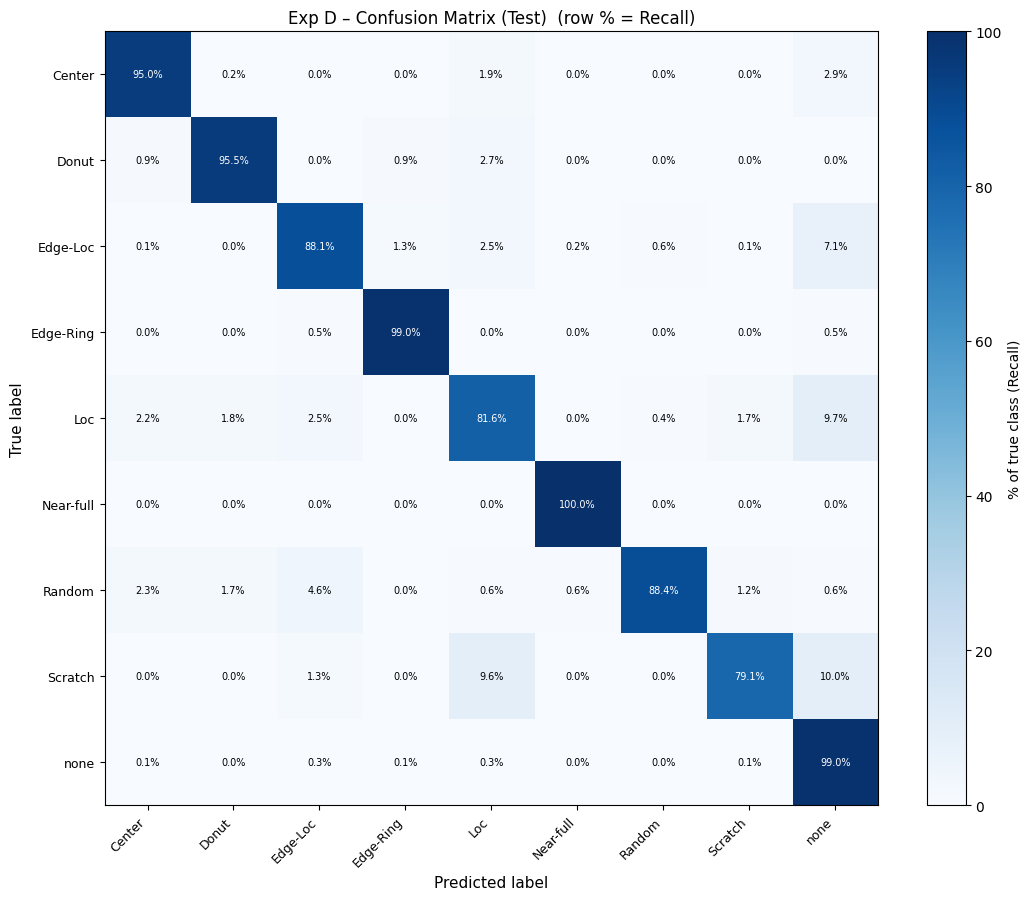

Saved (row % = Recall) → /content/drive/MyDrive/03_Wafer_Project/results/ExpD_confusion_matrix.png


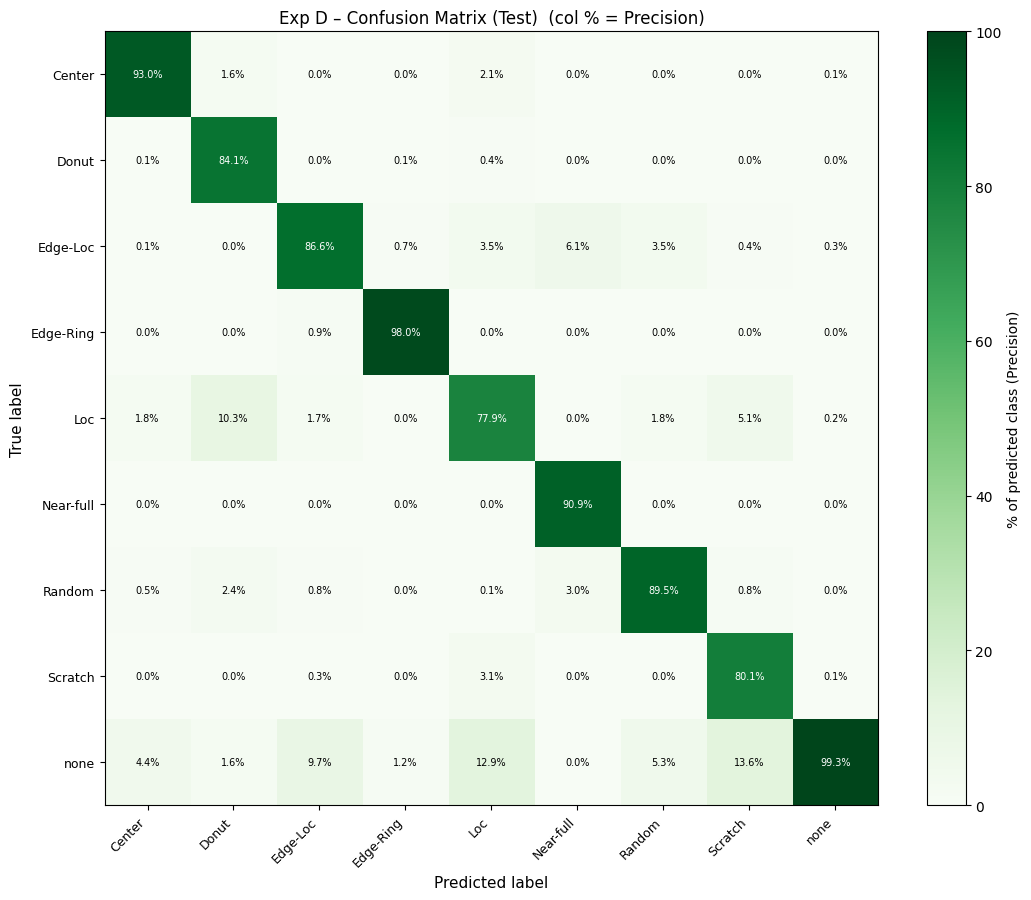

Saved (col % = Precision) → /content/drive/MyDrive/03_Wafer_Project/results/ExpD_confusion_matrix_col.png

  TEST SET COMPARISON: Exp C vs Exp D  [ViT-Small]
Metric                    Exp C (real)  Exp D (+synth)     Δ (D−C)
--------------------------------------------------------------
Accuracy                        0.9706          0.9798  +   0.0092
Macro F1 (all 9)                0.8717          0.9022  +   0.0304 ← key
Recall                          0.9170          0.9174  +   0.0004
Precision                       0.8342          0.8883  +   0.0541


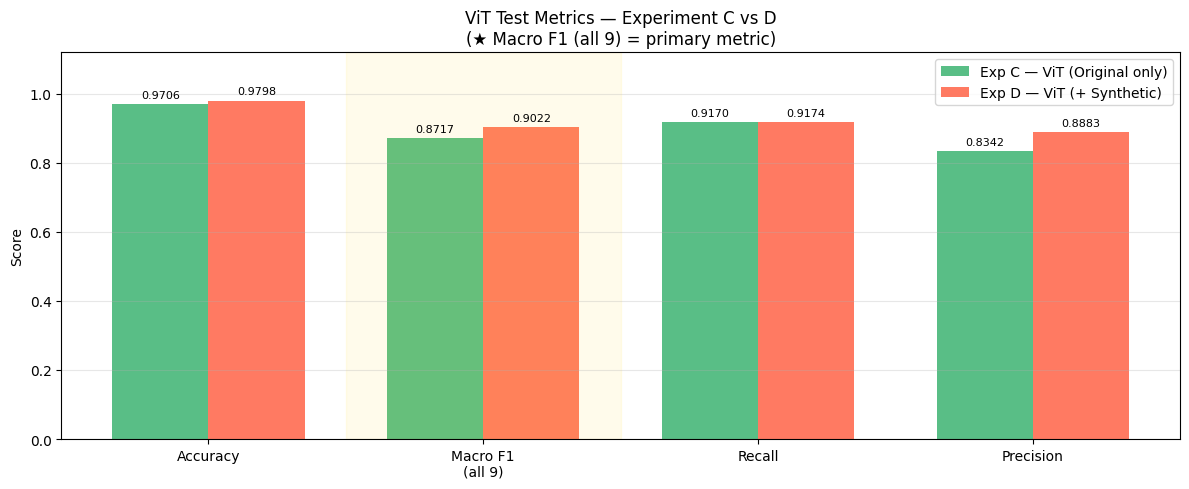

Saved → /content/drive/MyDrive/03_Wafer_Project/results/comparison_CD_metrics.png

  4-WAY COMPARISON: ResNet-18 (A / B)  vs  ViT (C / D)
Metric                    A ResNet real   B ResNet+syn   C ViT real   D ViT+syn
----------------------------------------------------------------------------------
Accuracy                         0.9742         0.9782       0.9706      0.9798
Macro F1 (all 9)                 0.8788         0.8940       0.8717      0.9022  ★
Recall                           0.9039         0.8980       0.9170      0.9174
Precision                        0.8562         0.8910       0.8342      0.8883


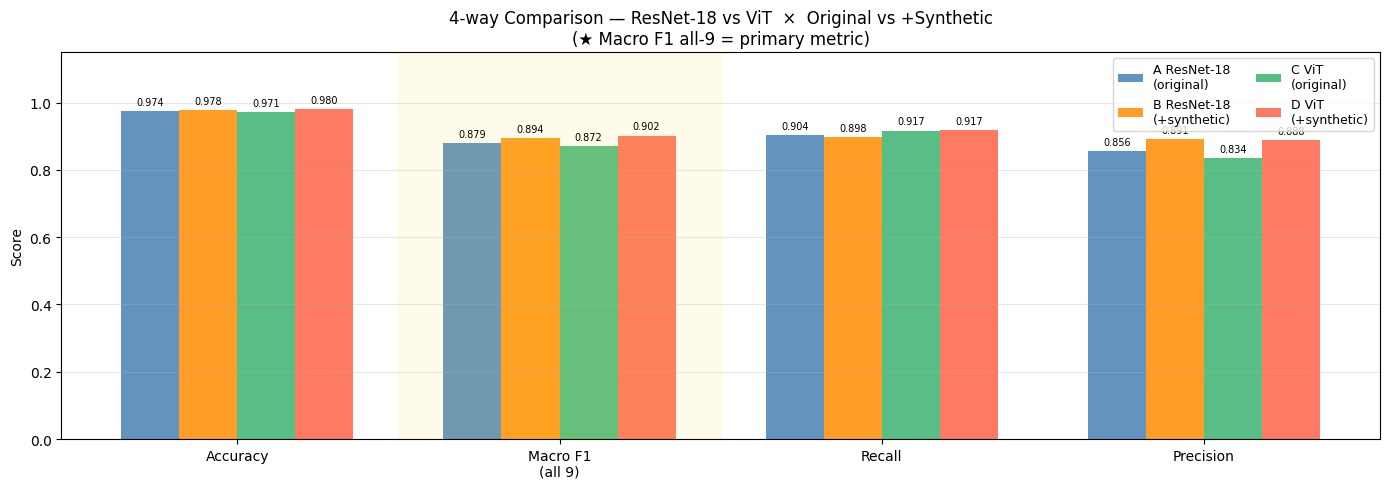

Saved → /content/drive/MyDrive/03_Wafer_Project/results/comparison_4way_ABCD.png


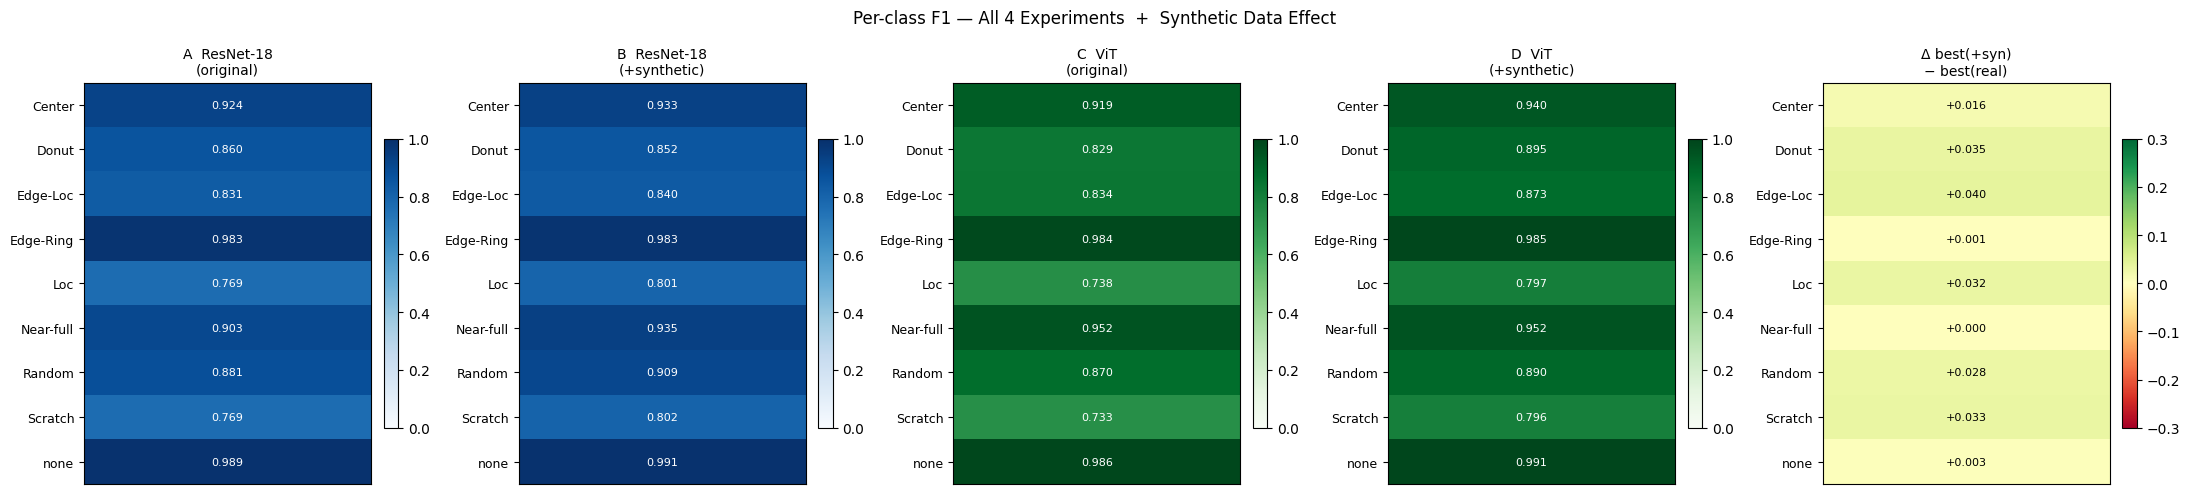

Saved → /content/drive/MyDrive/03_Wafer_Project/results/comparison_4way_per_cls_f1.png

All Section 12 results saved to: /content/drive/MyDrive/03_Wafer_Project/results


In [ ]:
### 12-5. Comparison: Exp C vs D  +  4-way Summary (A / B / C / D)

# ── Helper ────────────────────────────────────────────────────────────────────
metric_names_12 = ['Accuracy', 'Macro F1\n(all 9)', 'Recall', 'Precision']

def _get_vals(r):
    return [r['test_acc'], r['test_f1'], r['test_rec'], r['test_prec']]

# ── Attempt to load result_A / result_B ──────────────────────────────────────
_AB_METRICS_PATH = os.path.join(RESULT_DIR, "sec11_AB_metrics.npz")
have_AB = False

try:
    # Priority 1: Section 11 has already been run in the current session
    _ = result_A
    _ = result_B
    have_AB = True
    print("✓ result_A / result_B: loaded from current session memory")
except NameError:
    # Priority 2: .npz file saved after running Section 11
    if os.path.exists(_AB_METRICS_PATH):
        _d = np.load(_AB_METRICS_PATH, allow_pickle=True)
        result_A = {
            'test_acc'        : float(_d['a_test_acc']),
            'test_f1'         : float(_d['a_test_f1']),
            'test_rec'        : float(_d['a_test_rec']),
            'test_prec'       : float(_d['a_test_prec']),
            'test_per_cls_f1' : _d['a_per_cls_f1'],
            'test_labels'     : _d['a_labels'],
            'test_preds'      : _d['a_preds'],
        }
        result_B = {
            'test_acc'        : float(_d['b_test_acc']),
            'test_f1'         : float(_d['b_test_f1']),
            'test_rec'        : float(_d['b_test_rec']),
            'test_prec'       : float(_d['b_test_prec']),
            'test_per_cls_f1' : _d['b_per_cls_f1'],
            'test_labels'     : _d['b_labels'],
            'test_preds'      : _d['b_preds'],
        }
        have_AB = True
        print(f"✓ result_A / result_B: loaded from {_AB_METRICS_PATH}")
    else:
        print("⚠ result_A / result_B not found → printing C vs D comparison only.")

c_vals = _get_vals(result_C)
d_vals = _get_vals(result_D)

# ── Confusion matrix for Exp C, D: row % = Recall, col % = Precision ──────────────
def save_confusion_matrix(labels, preds, class_names, title, save_path):
    cm = confusion_matrix(labels, preds, labels=list(range(len(class_names))))
    out_dir = os.path.dirname(save_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    base_path = save_path.rsplit('.', 1)[0] if '.' in save_path else save_path

    # (1) Row-normalised % = Recall (predicted distribution within each true class)
    row_sums = np.maximum(cm.sum(axis=1, keepdims=True), 1)
    cm_pct = (cm.astype(float) / row_sums) * 100
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm_pct, interpolation='nearest', cmap='Blues', vmin=0, vmax=100)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('% of true class (Recall)', fontsize=10)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    thresh = 50.0
    for i in range(cm_pct.shape[0]):
        for j in range(cm_pct.shape[1]):
            txt = f"{cm_pct[i, j]:.1f}%"
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='white' if cm_pct[i, j] > thresh else 'black')
    ax.set_ylabel('True label', fontsize=11)
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_title(title + "  (row % = Recall)", fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved (row % = Recall) → {save_path}")

    # (2) Column-normalised % = Precision (true class distribution within each predicted class)
    col_sums = np.maximum(cm.sum(axis=0, keepdims=True), 1)
    cm_pct_col = (cm.astype(float) / col_sums) * 100
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm_pct_col, interpolation='nearest', cmap='Greens', vmin=0, vmax=100)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('% of predicted class (Precision)', fontsize=10)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    for i in range(cm_pct_col.shape[0]):
        for j in range(cm_pct_col.shape[1]):
            txt = f"{cm_pct_col[i, j]:.1f}%"
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='white' if cm_pct_col[i, j] > thresh else 'black')
    ax.set_ylabel('True label', fontsize=11)
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_title(title + "  (col % = Precision)", fontsize=12)
    plt.tight_layout()
    col_path = base_path + "_col.png"
    plt.savefig(col_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved (col % = Precision) → {col_path}")

save_confusion_matrix(
    result_C['test_labels'], result_C['test_preds'], ALL_CLF_CLASSES,
    title='Exp C – Confusion Matrix (Test)',
    save_path=os.path.join(RESULT_DIR, 'ExpC_confusion_matrix.png'),
)
save_confusion_matrix(
    result_D['test_labels'], result_D['test_preds'], ALL_CLF_CLASSES,
    title='Exp D – Confusion Matrix (Test)',
    save_path=os.path.join(RESULT_DIR, 'ExpD_confusion_matrix.png'),
)

# ── Exp C vs D text table ─────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("  TEST SET COMPARISON: Exp C vs Exp D  [ViT-Small]")
print("=" * 62)
print(f"{'Metric':<24}  {'Exp C (real)':>12}  {'Exp D (+synth)':>14}  {'Δ (D−C)':>10}")
print("-" * 62)
for m, c, d in zip(metric_names_12, c_vals, d_vals):
    delta = d - c
    sign  = '+' if delta >= 0 else ''
    tag   = ' ← key' if 'all 9' in m else ''
    print(f"{m.replace(chr(10),' '):<24}  {c:>12.4f}  {d:>14.4f}  {sign}{delta:>9.4f}{tag}")

# ── C vs D bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x, width = np.arange(len(metric_names_12)), 0.35

bars_c = ax.bar(x - width / 2, c_vals, width,
                label='Exp C — ViT (Original only)', color='mediumseagreen', alpha=0.85)
bars_d = ax.bar(x + width / 2, d_vals, width,
                label='Exp D — ViT (+ Synthetic)',   color='tomato',         alpha=0.85)

for bars in (bars_c, bars_d):
    for bar in bars:
        ax.annotate(f'{bar.get_height():.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score')
ax.set_title('ViT Test Metrics — Experiment C vs D\n'
             '(★ Macro F1 (all 9) = primary metric)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metric_names_12, fontsize=10)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axvspan(0.5, 1.5, alpha=0.08, color='gold', label='Key metric region')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "comparison_CD_metrics.png"),
            bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {os.path.join(RESULT_DIR, 'comparison_CD_metrics.png')}")


if have_AB:
    a_vals = _get_vals(result_A)
    b_vals = _get_vals(result_B)

    # ── 4-way text table ──────────────────────────────────────────────────────
    print("\n" + "=" * 82)
    print("  4-WAY COMPARISON: ResNet-18 (A / B)  vs  ViT (C / D)")
    print("=" * 82)
    print(f"{'Metric':<24}  {'A ResNet real':>13}  {'B ResNet+syn':>13}"
          f"  {'C ViT real':>11}  {'D ViT+syn':>10}")
    print("-" * 82)
    for m, a, b, c, d in zip(metric_names_12, a_vals, b_vals, c_vals, d_vals):
        tag = '  ★' if 'all 9' in m else ''
        print(f"{m.replace(chr(10),' '):<24}  {a:>13.4f}  {b:>13.4f}"
              f"  {c:>11.4f}  {d:>10.4f}{tag}")

    # ── 4-way grouped bar chart ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 5))
    x      = np.arange(len(metric_names_12))
    width  = 0.18
    offsets = [-1.5, -0.5, 0.5, 1.5]

    all_results = [a_vals, b_vals, c_vals, d_vals]
    exp_labels  = ['A ResNet-18\n(original)',  'B ResNet-18\n(+synthetic)',
                   'C ViT\n(original)',         'D ViT\n(+synthetic)']
    colors      = ['steelblue', 'darkorange', 'mediumseagreen', 'tomato']

    for vals, lbl, col, off in zip(all_results, exp_labels, colors, offsets):
        bars = ax.bar(x + off * width, vals, width, label=lbl, color=col, alpha=0.85)
        for bar in bars:
            ax.annotate(f'{bar.get_height():.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', va='bottom', fontsize=7)

    ax.set_ylabel('Score')
    ax.set_title('4-way Comparison — ResNet-18 vs ViT  ×  Original vs +Synthetic\n'
                 '(★ Macro F1 all-9 = primary metric)', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names_12, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9, ncol=2, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.axvspan(0.5, 1.5, alpha=0.08, color='gold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "comparison_4way_ABCD.png"),
                bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved → {os.path.join(RESULT_DIR, 'comparison_4way_ABCD.png')}")

    # ── Per-class F1 heatmap — all 4 experiments ─────────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    for ax, res, title, cmap in zip(
        axes[:4],
        [result_A, result_B, result_C, result_D],
        ['A  ResNet-18\n(original)', 'B  ResNet-18\n(+synthetic)',
         'C  ViT\n(original)',       'D  ViT\n(+synthetic)'],
        ['Blues', 'Blues', 'Greens', 'Greens'],
    ):
        vals = res['test_per_cls_f1']
        im   = ax.imshow(vals.reshape(-1, 1), cmap=cmap, vmin=0, vmax=1, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_yticks(range(N_CLF_CLASSES))
        ax.set_yticklabels(ALL_CLF_CLASSES, fontsize=9)
        ax.set_xticks([])
        ax.set_title(title, fontsize=10)
        for i, v in enumerate(vals):
            color = 'white' if v > 0.6 else 'black'
            ax.text(0, i, f'{v:.3f}', ha='center', va='center', fontsize=8, color=color)

    best_no_syn   = np.maximum(result_A['test_per_cls_f1'], result_C['test_per_cls_f1'])
    best_with_syn = np.maximum(result_B['test_per_cls_f1'], result_D['test_per_cls_f1'])
    delta_syn     = best_with_syn - best_no_syn

    ax5 = axes[4]
    im5 = ax5.imshow(delta_syn.reshape(-1, 1), cmap='RdYlGn',
                     vmin=-0.3, vmax=0.3, aspect='auto')
    plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
    ax5.set_yticks(range(N_CLF_CLASSES))
    ax5.set_yticklabels(ALL_CLF_CLASSES, fontsize=9)
    ax5.set_xticks([])
    ax5.set_title('Δ best(+syn)\n− best(real)', fontsize=10)
    for i, v in enumerate(delta_syn):
        color = 'white' if abs(v) > 0.2 else 'black'
        ax5.text(0, i, f'{v:+.3f}', ha='center', va='center', fontsize=8, color=color)

    plt.suptitle("Per-class F1 — All 4 Experiments  +  Synthetic Data Effect",
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "comparison_4way_per_cls_f1.png"),
                bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved → {os.path.join(RESULT_DIR, 'comparison_4way_per_cls_f1.png')}")


print("\nAll Section 12 results saved to:", RESULT_DIR)